# Exercise 9a — matched JANA versus the multiclass hybrid

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rafaellopesdesa/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_9a_JANA.ipynb)

This exercise now makes the missing control explicit.  Every campaign fits a direct posterior flow $q_\phi(\theta\mid x)$ and a direct likelihood flow $q_\eta(x\mid\theta)$ with posterior and likelihood NLLs, and then compares two estimators built from **the same simulations, flow architecture, ensemble members, and frozen checkpoints**:

1. **Matched JANA direct:** use $q_\phi$ and $q_\eta$ as the posterior and likelihood, with no classifier correction.
2. **Hybrid CE:** use the same $q_\phi$ and $q_\eta$, corrected by the structured multiclass $a$ and $c$ heads trained with classification losses only.  Conditional normalization is applied after training; normalization and bridge identities remain held-out checks.

The matched backend is intentional: the two JANA networks have disjoint parameters, so minimizing their summed negative log likelihood is exactly the pair of direct NPE/NLE fits used in the Figure 3 benchmarks.  It isolates the value added by CE instead of confounding it with a different capacity or simulation bank.  It is a method-level JANA baseline, not a claim that the historical TensorFlow/BayesFlow checkpoint has been reconstructed byte-for-byte.  In the DDM campaign, the same direct NPE/NLE comparison is retained but the DeepSet summary is regression-pretrained and frozen, so that part is explicitly reported as a matched direct control rather than an exact reproduction of JANA's end-to-end summary training.

The Figure 3 campaign uses the pinned Gaussian Mixture and SIR simulators.  The Figure 6 campaign uses the official DDM assets and, when enabled, the approximately 6 GB OSF bank.  Google Drive is mounted by default in Colab: simulation caches, checkpoints, numerical results, paper figures, the pinned JANA checkout, and the OSF clone survive runtime resets.  The large OSF download is still an explicit one-time opt-in.  Every plot is exported as PDF, PNG, numerical data, and a standalone plotting script.

In [11]:
# Colab bootstrap: a Drive-backed checkout and persistent artifacts.
import importlib.util
import os
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version as package_version
from pathlib import Path

REPO_URL = "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git"
BRANCH = "ml4hep_school_tutorial"
USE_GOOGLE_DRIVE = os.environ.get("EX9A_USE_DRIVE", "1") == "1"
IN_COLAB = "google.colab" in sys.modules
COLAB_DRIVE_ROOT = None


def run_command(*args, env=None, cwd=None):
    subprocess.run([str(arg) for arg in args], check=True, env=env, cwd=cwd)


def installed_version(distribution):
    try:
        return package_version(distribution)
    except PackageNotFoundError:
        return None


if IN_COLAB:
    if USE_GOOGLE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        COLAB_DRIVE_ROOT = Path(
            os.environ.get(
                "EX9A_DRIVE_ROOT",
                "/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab",
            )
        )
        COLAB_DRIVE_ROOT.mkdir(parents=True, exist_ok=True)
        repository = COLAB_DRIVE_ROOT / "nsbi-lhc-toolkit"
    else:
        repository = Path("/content/nsbi-lhc-toolkit")

    if not (repository / ".git").exists():
        clone_env = os.environ.copy()
        clone_env["GIT_LFS_SKIP_SMUDGE"] = "1"
        run_command(
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "--branch", BRANCH, REPO_URL, repository, env=clone_env,
        )
    else:
        run_command("git", "-C", repository, "remote", "set-url", "origin", REPO_URL)
        run_command("git", "-C", repository, "fetch", "origin", BRANCH)
        run_command("git", "-C", repository, "checkout", BRANCH)
        run_command("git", "-C", repository, "pull", "--ff-only", "origin", BRANCH)
    run_command(
        "git", "-C", repository, "sparse-checkout", "set",
        "src", "workshops/ml4hep_tifr_colab",
    )

    requirements = []
    if installed_version("nflows") != "0.14":
        requirements.append("nflows==0.14")
    if installed_version("osfclient") != "0.0.5":
        requirements.append("osfclient==0.0.5")
    if importlib.util.find_spec("pyarrow") is None:
        requirements.append("pyarrow")
    if requirements:
        run_command(sys.executable, "-m", "pip", "install", "-q", *requirements)

    importlib.invalidate_caches()
    assert installed_version("nflows") == "0.14"
    assert installed_version("osfclient") == "0.0.5"
    print("Pinned runtime: nflows=0.14, osfclient=0.0.5; pyarrow available for optional DDM preparation")
    os.chdir(repository / "workshops" / "ml4hep_tifr_colab")
    print("Colab workshop:", Path.cwd())
else:
    print("Local runtime: Colab bootstrap skipped.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pinned runtime: nflows=0.14, osfclient=0.0.5; pyarrow available for optional DDM preparation
Colab workshop: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/workshops/ml4hep_tifr_colab


## Pinned references and the head-to-head contract

- JANA paper: Radev, Schmitt, Pratz, Picchini, Köthe & Bürkner, *JANA: Jointly Amortized Neural Approximation of Complex Bayesian Models*, arXiv:2302.09125, version 3.
- Reference implementation: `bayesflow-org/JANA-Paper`, commit `6cbbc94faf0aa85147986f7f9516d13a52551bd4` (MIT license).
- The paper repository pins BayesFlow commit `153dfefadd347717b7aeb9c4872a4b51ac04e83c`.  Its Figure 3 priors, simulators, scaling, and stabilization are translated directly below.
- Official large DDM data: OSF project `2nbk6`.  A Drive-backed clone is validated before it can be used.

The standard JANA loss is

$$
\mathcal L_{\rm JANA}=
-\mathbb E_{p(\theta,x)}\log q_\phi(\theta\mid x)
-\mathbb E_{p(\theta,x)}\log q_\eta(x\mid\theta).
$$

Because the posterior and likelihood networks have disjoint parameters, the loss separates exactly.  Training the two terms with separate optimizers is therefore objective-equivalent to optimizing their sum.  We call their direct composition **matched JANA** in Figure 3.  The hybrid uses those same frozen flows and adds only the CE-trained multiclass correction.  This is the fairest test of the proposed ML ingredient; a separate historical-checkpoint reproduction would answer a different, architecture-dependent question.  The DDM keeps this matched direct-flow control but, as documented below, freezes a regression-pretrained DeepSet summary before the posterior NLL fit.

“Posterior SBC” conditions on fresh simulator observations.  “Joint SBC” draws an observation from the learned likelihood and then applies the learned posterior.  For every rank comparison, JANA direct and Hybrid CE use the same held-out truths, rank count, and randomized-rank jitter.  Ground-truth densities, official posteriors, normalization estimates, bridge statistics, Bridge sampling, and PSIS are evaluation-only and cannot influence a checkpoint.

In [12]:
import copy
import csv
import hashlib
import json
import math
import os
import subprocess
import sys
from dataclasses import asdict, dataclass
from importlib.metadata import version as package_version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from scipy.integrate import odeint
from scipy.special import log_ndtr, logsumexp, ndtr
from torch.utils.data import DataLoader, TensorDataset


def _find_workshop_dir():
    candidates = [
        Path.cwd(),
        Path.cwd() / "workshops" / "ml4hep_tifr_colab",
        Path("/content/nsbi-lhc-toolkit/workshops/ml4hep_tifr_colab"),
    ]
    for candidate in candidates:
        if (candidate / "utils_hnpe.py").exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find utils_hnpe.py. Run from the workshop directory or "
        "clone nsbi-lhc-toolkit under /content."
    )


WORKSHOP_DIR = _find_workshop_dir()
if IN_COLAB and USE_GOOGLE_DRIVE:
    DEFAULT_PERSIST_ROOT = Path("/content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA")
else:
    DEFAULT_PERSIST_ROOT = WORKSHOP_DIR / "persistent_exercise_artifacts"
PERSIST_ROOT = Path(os.environ.get("EX9A_PERSIST_ROOT", DEFAULT_PERSIST_ROOT)).resolve()
PERSIST_ROOT.mkdir(parents=True, exist_ok=True)
if str(WORKSHOP_DIR) not in sys.path:
    sys.path.insert(0, str(WORKSHOP_DIR))

from utils_benchmark import infer_parameter_transform
from utils_hnpe import (
    install_nflows_rqs_float64_retry,
    sample_spline_flow_ensemble,
    spline_flow_ensemble_log_prob,
    train_spline_flow_ensemble,
)

# Install the audited inverse-RQS precision retry before any flow is sampled.
NFLOWS_VERSION = package_version("nflows")
RQS_NUMERIC_GUARD = install_nflows_rqs_float64_retry(required_version="0.14")
RQS_NUMERIC_GUARD_ACTIVE = any(
    bool(getattr(RQS_NUMERIC_GUARD, flag, False))
    for flag in ("_hybrid_float64_retry", "_exercise9_float64_retry", "_ex9b_float64_retry")
)
if not RQS_NUMERIC_GUARD_ACTIVE:
    raise RuntimeError("The audited nflows inverse-RQS guard was not installed.")

SEED = 230209125
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")
print("Workshop:", WORKSHOP_DIR)
print("Device:", DEVICE)
print("Persistent artifact root:", PERSIST_ROOT)

Workshop: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/workshops/ml4hep_tifr_colab
Device: cuda
Persistent artifact root: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA


## Workload profiles

`tutorial` and `paper` both preserve the 10,000-call Figure 3 training budget.  They use respectively two and four independently initialized structured-classifier members (smoke uses one), and differ in flow-ensemble size, optimizer iterations, correction candidates, and diagnostics.  `smoke` is only a path test.  For the DDM, `tutorial` may train on a documented subset of the official bank; only `paper` uses the full cached campaign.

In [13]:
PROFILES = {
    "smoke": dict(
        n_train=512, n_calibration=48, flow_ensemble=1, classifier_ensemble=1,
        flow_epochs=2, class_lr_stage_epochs=(1, 1, 1, 1, 1),
        class_width=96, class_blocks=2, batch_size=96,
        diagnostic_contexts=16, diagnostic_inner=4,
        rank_draws=32, posterior_candidates=96, likelihood_candidates=64,
        ddm_datasets=128, ddm_trials_min=24, ddm_trials_max=32,
        ddm_event_cap=4_096, ddm_eval_datasets=3,
    ),
    "tutorial": dict(
        n_train=10_000, n_calibration=1_000, flow_ensemble=2, classifier_ensemble=2,
        flow_epochs=80, class_lr_stage_epochs=(24, 18, 14, 10, 8),
        class_width=512, class_blocks=6, batch_size=256,
        diagnostic_contexts=256, diagnostic_inner=24,
        rank_draws=250, posterior_candidates=1_024,
        likelihood_candidates=256,
        ddm_datasets=12_000, ddm_trials_min=80, ddm_trials_max=120,
        ddm_event_cap=1_500_000, ddm_eval_datasets=20,
    ),
    "paper": dict(
        n_train=10_000, n_calibration=1_000, flow_ensemble=4, classifier_ensemble=4,
        flow_epochs=240, class_lr_stage_epochs=(120, 70, 55, 40, 30, 20),
        class_width=1024, class_blocks=6, batch_size=512,
        diagnostic_contexts=512, diagnostic_inner=64,
        rank_draws=250, posterior_candidates=4_096,
        likelihood_candidates=1_024,
        ddm_datasets=None, ddm_trials_min=80, ddm_trials_max=120,
        ddm_event_cap=None, ddm_eval_datasets=100,
    ),
}

PROFILE = "tutorial"             # smoke | tutorial | paper
RUN_FIG3 = True
RUN_DDM = True                   # requires the pinned JANA checkout + OSF bank
ALLOW_PINNED_GIT_CLONE = True     # source/assets only; safe on persistent Drive
DOWNLOAD_JANA_OSF = True         # explicit one-time ~6 GB download into persistent Drive
FORCE_RETRAIN = True

CFG = PROFILES[PROFILE]
RUN_TAG = f"{PROFILE}_v9_matched_jana_vs_hybrid_ce"
MODEL_DIR = PERSIST_ROOT / "models_exercise9a_JANA" / RUN_TAG
OUTPUT_DIR = PERSIST_ROOT / "exercise9a_JANA_figures_scripts" / RUN_TAG
CACHE_DIR = PERSIST_ROOT / "cache_exercise9a_JANA" / RUN_TAG
for directory in (MODEL_DIR, OUTPUT_DIR, CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

DIRECT_A_WEIGHT = 1.0
CLASSIFIER_PREFLIGHT_STAGES = 2
TRAINING_OBJECTIVE_VERSION = "multiclass_ce_plus_balanced_direct_a_bce_v1"
PREPROCESSING_VERSION = "coordinatewise_median_mad_asinh_v1"
CLASSIFIER_ARCHITECTURE_VERSION = "exercise9_prenorm_layernorm_zero_output_tanh_v6"
CLASSIFIER_LOG_RATIO_BOUND = 20.0
NORMALIZATION_ESTIMATOR = "heldout_independent_A_B_cross_mass_v3"
BRIDGE_ESTIMATOR = "heldout_iid_unbiased_sample_variance_v2"
SIMULTANEOUS_ECDF_MC = 5_000 if PROFILE == "smoke" else 20_000
LEARNING_RATES = (1.0e-3, 3.0e-4, 1.0e-4, 3.0e-5, 1.0e-5)

if len(CFG["class_lr_stage_epochs"]) != len(LEARNING_RATES):
    raise ValueError("Every classifier LR stage needs one epoch count.")
if not 1 <= CLASSIFIER_PREFLIGHT_STAGES <= len(LEARNING_RATES):
    raise ValueError("CLASSIFIER_PREFLIGHT_STAGES must fit inside the LR schedule.")

print(json.dumps({"profile": PROFILE, **CFG}, indent=2))

print("Models:", MODEL_DIR)
print("Caches:", CACHE_DIR)
print("Results/figures:", OUTPUT_DIR)

{
  "profile": "tutorial",
  "n_train": 10000,
  "n_calibration": 1000,
  "flow_ensemble": 2,
  "classifier_ensemble": 2,
  "flow_epochs": 80,
  "class_lr_stage_epochs": [
    24,
    18,
    14,
    10,
    8
  ],
  "class_width": 512,
  "class_blocks": 6,
  "batch_size": 256,
  "diagnostic_contexts": 256,
  "diagnostic_inner": 24,
  "rank_draws": 250,
  "posterior_candidates": 1024,
  "likelihood_candidates": 256,
  "ddm_datasets": 12000,
  "ddm_trials_min": 80,
  "ddm_trials_max": 120,
  "ddm_event_cap": 1500000,
  "ddm_eval_datasets": 20
}
Models: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/models_exercise9a_JANA/tutorial_v9_matched_jana_vs_hybrid_ce
Caches: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/cache_exercise9a_JANA/tutorial_v9_matched_jana_vs_hybrid_ce
Results/figures: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/exercise9a_JANA_figures_scripts/tutorial_v9_matched_jana_vs_hybrid_ce


## Matched JANA first; CE correction and consistency checks second

The two direct flows are first trained with $\mathcal L_{\rm JANA}$ above.  Their uncorrected posterior and likelihood are the matched-capacity pure-JANA baseline.  They are then frozen.  Let $S(\theta,x)=\rho(\theta)p(x\mid\theta)$, $P(\theta,x)=m_\rho(x)q_\phi(\theta\mid x)$, and $L(\theta,x)=\rho(\theta)q_\eta(x\mid\theta)$.  One network returns

\[
  a(\theta,x)=\log\frac{S}{P},\qquad
  c(\theta,x)=\log\frac{S}{L},\qquad
  (s_S,s_P,s_L)=(a,0,a-c).
\]

The trainable objective is classification-only:

\[
 \mathcal L_{\rm train}=\mathcal L_{\rm CE}^{S/P/L}
 +\lambda_a\!\left(\mathcal L_{\rm BCE}^{S/P}(a)-\log 2\right),
 \qquad \lambda_a=1.
\]

The second term is the balanced direct-$a$ proper score introduced as a classifier preflight; it uses only the same simulated $S$ and proposal $P$ classes.  The subtraction of $\log 2$ is a constant baseline and changes no gradient.  No density-normalization estimate or bridge statistic is present in this objective.  Five progressively smaller learning-rate stages are retained.  The first two are a fixed classification-only preflight: checkpoint selection begins at the last epoch of stage two and subsequently minimizes only held-out $\mathcal L_{\rm train}$.

Every structured head uses the exact Exercise 9 topology outside smoke mode: width 512, six PreNorm residual blocks with LayerNorm before each two-layer update, a final LayerNorm, and a zero-initialized output layer; the bounded log-ratio map is retained.  Each input coordinate is transformed by

\[
 u_j=\operatorname{asinh}\!\left(\frac{v_j-\operatorname{median}(v_j)}
 {1.4826\,\operatorname{MAD}(v_j)}\right),
\]

with an IQR/standard-deviation fallback when a MAD vanishes.  The fitted medians and scales are model buffers and therefore part of every checkpoint.  Smoke/tutorial/paper use 1/2/4 independently seeded classifier members.  At inference, each member's three logits is centered by its class mean and the centered logits are averaged; equivalently, the structured $a$- and $c$-heads are averaged before any density correction, evidence, or calibration calculation.  Outside smoke mode, vector proposals copy Exercise 9's two full-support affine layers plus ten LU-mixed 512x4 RQS layers (80 bins, tail 25); scalar proposals use four 256x4 monotone RQS layers (48 bins, tail 18) without affine/LU mixing.

Conditional normalization is a **post-training density correction**, not a learned penalty:

\[
 \widehat p(\theta\mid x)=\frac{q_\phi(\theta\mid x)e^{a(\theta,x)}}{Z_P(x)},
 \quad Z_P(x)=\mathbb E_{q_\phi(\theta\mid x)}e^{a(\theta,x)},
\]

and analogously $\widehat p(x\mid\theta)=q_\eta(x\mid\theta)e^{c(\theta,x)}/Z_L(\theta)$.  Importance-resampling code performs this normalization automatically through normalized weights; reported densities and evidence estimates explicitly estimate the required $Z$ factors from fresh proposal draws.

After the selected checkpoint is frozen, two independent held-out mixture banks A and B report

\[
 \left\langle(Z_P^A-1)(Z_P^B-1)\right\rangle,
 \qquad
 \left\langle(Z_L^A-1)(Z_L^B-1)\right\rangle.
\]

These are consistency statistics only.  A separate held-out IID bank reports the raw bridge variance

\[
 \left\langle\operatorname{Var}_{K-1}\!\left[
 \log\rho+\log q_\eta-\log q_\phi+c-a\right]\right\rangle_x.
\]

Neither check is backpropagated, included in the training history objective, or consulted for checkpoint eligibility.  The diagnostic banks are constructed only after the selected classifier is frozen, and their contexts come only from the classifier validation partition.  `nflows==0.14` is pinned and its audited finite-tensor inverse-RQS float64 retry is installed before any flow draw.

The plots always show both estimators.  “JANA direct” means the normalized conditional flows themselves; it never evaluates an $a$ or $c$ head.  “Hybrid CE” means independent draws from those same frozen flow distributions are reweighted or resampled with the frozen heads.  Consequently any difference is due to the CE correction (plus its finite-proposal Monte Carlo), not additional simulations or a more expressive proposal.  For the Figure 3 benchmarks, this matched PyTorch/nflows backend follows the JANA objective exactly but is not the historical TensorFlow architecture.  The DDM campaign is labelled more narrowly as a matched direct-NPE/NLE control because its set summary is regression-pretrained and frozen before the posterior NLL fit; it is not an exact reproduction of JANA's end-to-end summary training.

In [14]:
def seed_everything(seed):
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


def as_2d(values, name):
    values = np.asarray(values, dtype=np.float32)
    if values.ndim == 1:
        values = values[:, None]
    if values.ndim != 2 or not np.isfinite(values).all():
        raise ValueError(f"{name} must be a finite two-dimensional array.")
    return values


def array_digest(*arrays):
    digest = hashlib.sha256()
    for array in arrays:
        value = np.ascontiguousarray(np.asarray(array))
        digest.update(str(value.shape).encode())
        digest.update(str(value.dtype).encode())
        digest.update(value.view(np.uint8))
    return digest.hexdigest()



def robust_location_scale(values):
    values = as_2d(values, "robust-transform values").astype(np.float64)
    median = np.median(values, axis=0)
    mad_scale = 1.4826 * np.median(np.abs(values - median), axis=0)
    q25, q75 = np.quantile(values, [0.25, 0.75], axis=0)
    iqr_scale = (q75 - q25) / 1.3489795003921634
    std_scale = values.std(axis=0)
    scale = np.where(mad_scale > 1.0e-6, mad_scale, iqr_scale)
    scale = np.where(scale > 1.0e-6, scale, std_scale)
    scale = np.where(scale > 1.0e-6, scale, 1.0)
    return median.astype(np.float32), scale.astype(np.float32)


def classifier_members(model_or_ensemble):
    if isinstance(model_or_ensemble, (list, tuple)):
        members = list(model_or_ensemble)
    else:
        members = [model_or_ensemble]
    if not members:
        raise ValueError("A classifier ensemble must contain at least one member.")
    return members


def set_classifier_mode(model_or_ensemble, training):
    for member in classifier_members(model_or_ensemble):
        member.train(bool(training))
    return model_or_ensemble


def validate_group_partition(n_groups, training_index, validation_index, label):
    training_index = np.asarray(training_index, dtype=np.int64)
    validation_index = np.asarray(validation_index, dtype=np.int64)
    if training_index.ndim != 1 or validation_index.ndim != 1:
        raise ValueError(f"{label}: group indices must be one-dimensional.")
    combined = np.concatenate([training_index, validation_index])
    if len(training_index) == 0 or len(validation_index) == 0:
        raise ValueError(f"{label}: both training and validation groups are required.")
    if np.any(combined < 0) or np.any(combined >= int(n_groups)):
        raise IndexError(f"{label}: group index outside [0, {n_groups}).")
    if len(combined) != int(n_groups) or len(np.unique(combined)) != int(n_groups):
        raise RuntimeError(f"{label}: group split must be disjoint and exhaustive.")
    return training_index, validation_index


def split_group_indices(n_groups, validation_fraction, seed, label):
    order = np.random.default_rng(int(seed)).permutation(int(n_groups))
    n_validation = max(1, int(round(float(validation_fraction) * len(order))))
    if n_validation >= len(order):
        raise ValueError(f"{label}: not enough groups for a train/validation split.")
    return validate_group_partition(
        len(order), order[n_validation:], order[:n_validation], label
    )


def torch_logmeanexp(values, dim):
    return torch.logsumexp(values, dim=dim) - math.log(values.shape[dim])


def importance_resample(values, log_weights, n_draws, rng):
    values = np.asarray(values)
    log_weights = np.asarray(log_weights, dtype=np.float64)
    log_weights = log_weights - logsumexp(log_weights)
    probabilities = np.exp(log_weights)
    ess = 1.0 / np.sum(probabilities**2)
    indices = rng.choice(len(values), size=int(n_draws), replace=True, p=probabilities)
    return values[indices], float(ess)


def simultaneous_uniform_ecdf_critical(n_ranks, confidence=0.95, seed=0, n_mc=None):
    """Monte-Carlo critical value for sup_u |F_n(u)-u| under iid U(0,1)."""
    n_ranks = int(n_ranks)
    n_mc = SIMULTANEOUS_ECDF_MC if n_mc is None else int(n_mc)
    if n_ranks < 2 or n_mc < 100:
        raise ValueError("The simultaneous ECDF calibration needs n_ranks >= 2 and n_mc >= 100.")
    rng = np.random.default_rng(int(seed))
    order = np.arange(1, n_ranks + 1, dtype=np.float64)
    statistics = []
    for start in range(0, n_mc, 256):
        batch = min(256, n_mc - start)
        uniforms = np.sort(rng.random((batch, n_ranks)), axis=1)
        upper = np.max(order[None, :] / n_ranks - uniforms, axis=1)
        lower = np.max(uniforms - (order[None, :] - 1.0) / n_ranks, axis=1)
        statistics.append(np.maximum(upper, lower))
    statistics = np.concatenate(statistics)
    return float(np.quantile(statistics, confidence, method="higher"))


def simultaneous_difference_envelope(grid, critical):
    grid = np.asarray(grid, dtype=np.float64)
    return np.maximum(-grid, -critical), np.minimum(1.0 - grid, critical)


def calibration_metrics(ranks, label, parameter_names):
    ranks = np.asarray(ranks, dtype=np.float64)
    rows = []
    grid = np.linspace(0.0, 1.0, 201)
    for index, name in enumerate(parameter_names):
        empirical = (ranks[:, index, None] <= grid[None, :]).mean(axis=0)
        residual = empirical - grid
        slope, intercept = np.polyfit(grid, empirical, 1)
        prediction = slope * grid + intercept
        denominator = np.sum((empirical - empirical.mean()) ** 2)
        r2 = 1.0 - np.sum((empirical - prediction) ** 2) / max(denominator, 1e-15)
        rows.append({
            "method": label, "parameter": name,
            "MAE_ECDF": float(np.mean(np.abs(residual))),
            "RMSE_ECDF": float(np.sqrt(np.mean(residual**2))),
            "rank_bias": float(ranks[:, index].mean() - 0.5),
            "ECDF_slope": float(slope), "ECDF_intercept": float(intercept),
            "R2": float(r2), "KS": float(np.max(np.abs(residual))),
            "n_calibration": int(len(ranks)),
        })
    return pd.DataFrame(rows)


def regression_metrics(reference, estimate, label):
    reference = np.asarray(reference, dtype=np.float64).reshape(-1)
    estimate = np.asarray(estimate, dtype=np.float64).reshape(-1)
    keep = np.isfinite(reference) & np.isfinite(estimate)
    reference, estimate = reference[keep], estimate[keep]
    slope, intercept = np.polyfit(reference, estimate, 1)
    prediction = slope * reference + intercept
    denominator = np.sum((estimate - estimate.mean()) ** 2)
    return {
        "comparison": label, "n": int(len(reference)),
        "MAE": float(np.mean(np.abs(estimate - reference))),
        "RMSE": float(np.sqrt(np.mean((estimate - reference) ** 2))),
        "bias": float(np.mean(estimate - reference)),
        "slope": float(slope), "intercept": float(intercept),
        "R2": float(1.0 - np.sum((estimate - prediction) ** 2) / max(denominator, 1e-15)),
    }


def export_figure(fig, stem):
    png = OUTPUT_DIR / f"{stem}.png"
    pdf = OUTPUT_DIR / f"{stem}.pdf"
    fig.savefig(png, dpi=220, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print("Exported", png, "and", pdf)

## Figure 3 campaign: simulator banks and coordinate conventions

The two local simulators below are literal NumPy/SciPy translations of the [`gaussian_mixture.py`](https://github.com/stefanradev93/bayesflow/blob/153dfefadd347717b7aeb9c4872a4b51ac04e83c/bayesflow/benchmarks/gaussian_mixture.py) and [`sir.py`](https://github.com/stefanradev93/bayesflow/blob/153dfefadd347717b7aeb9c4872a4b51ac04e83c/bayesflow/benchmarks/sir.py) Figure-3 benchmark sources in BayesFlow commit `153dfefadd347717b7aeb9c4872a4b51ac04e83c`, the commit pinned by JANA.  Those source files are MIT-licensed.  This matters: the JANA Gaussian Mixture uses a narrow-component **standard deviation of 0.01** (not the 0.1 used by `sbibm==1.1.0`), and its SIR implementation is the SciPy model below rather than the `diffeqtorch`/Julia implementation shipped by `sbibm`.  Thus Exercise 9a has no `sbibm` or Julia dependency.

For Gaussian Mixture, \(\theta\sim\mathcal U([-10,10]^2)\), the two equally weighted likelihood components are \(\mathcal N(\theta,I)\) and \(\mathcal N(\theta,0.01^2I)\), and observations are divided by 12 as in the pinned BayesFlow configurator.  For SIR, \(\beta\sim\operatorname{LogNormal}(\log0.4,0.5)\) and \(\gamma\sim\operatorname{LogNormal}(\log(1/8),0.2)\).  The ODE is evaluated with `scipy.integrate.odeint` on `np.linspace(0,160,160)`, every 16th infected-population value is retained, and each is observed as \(Y_j/1000\) with \(Y_j\sim\operatorname{Binomial}(1000,I(t_j)/10^6)\).  JANA's [Gaussian-mixture experiment](https://github.com/bayesflow-org/JANA-Paper/blob/6cbbc94faf0aa85147986f7f9516d13a52551bd4/experiments/benchmarks/benchmark_7_gaussian_mixture.ipynb) additionally divides \(\theta\) by 10 at the neural-network interface.  Here we retain the hybrid method's bounded-logit flow coordinate and its Jacobian instead; that is a declared model-coordinate choice, while the physical prior, simulator, observation scaling, and SBC truth remain the pinned JANA benchmark.

JANA's [SIR experiment configurator](https://github.com/bayesflow-org/JANA-Paper/blob/6cbbc94faf0aa85147986f7f9516d13a52551bd4/experiments/benchmarks/benchmark_9_sir.ipynb) adds Gaussian noise with standard deviation \(10^{-3}\) independently to each route-specific tensor for numerical stability.  A structured S/P/L row must instead live on one common observation space, so we convolve the scaled-count observation **once** with the same \(\mathcal N(0,10^{-6})\) kernel and share that draw across S, P, and L.  This has JANA's marginal smoothing while preserving the bridge identity; it is still a continuous relaxation of a count PMF and is recorded explicitly.

The immutable cache stores the raw simulator outputs, source commit, schema, every seed namespace, bank sizes, and a payload digest.  Training and calibration are generated by **separate simulator calls with disjoint deterministic seeds**; the calibration bank is never obtained by slicing a combined generation call.  The continuous observation adapter is deterministic from another pair of disjoint recorded seeds and is applied only after cache validation.  Each classifier group contains its matched S/P/L rows: S and P share the same observation, while S and L share the same parameter.  Train/validation splitting is performed on whole groups, never flat rows.  The 10,000-pair training bank fits the two proposal flows and supplies multiclass rows, matching a jointly amortized call budget; this is not presented as cross-fitting.  The separate 1,000-pair calibration bank is never touched until SBC.  Parameters are mapped to an unconstrained coordinate using the task prior support.

In [15]:
JANA_BAYESFLOW_COMMIT = "153dfefadd347717b7aeb9c4872a4b51ac04e83c"
JANA_FIG3_SIMULATOR_SCHEMA = "jana_bayesflow_153dfef_fig3_v2_separate_banks"
JANA_GAUSSIAN_MIXTURE_OBSERVATION_SCALE = 12.0
JANA_SIR_STABILIZATION_SIGMA = 1.0e-3
JANA_FIG3_CALIBRATION_SEED_OFFSET = 10_000_000
JANA_FIG3_TRAIN_ADAPTER_SEED_OFFSET = 20_000_000
JANA_FIG3_CALIBRATION_ADAPTER_SEED_OFFSET = 30_000_000


class JanaFigure3Task:
    """Minimal prior contract needed by the hybrid Figure-3 construction."""

    def __init__(self, name):
        self.name = str(name)
        if self.name == "gaussian_mixture":
            low = -10.0 * torch.ones(2, dtype=torch.float32)
            high = 10.0 * torch.ones(2, dtype=torch.float32)
            self.prior_params = {"low": low, "high": high}
            self.prior_dist = torch.distributions.Independent(
                torch.distributions.Uniform(low, high), 1
            )
            self.dim_parameters, self.dim_data = 2, 2
        elif self.name == "sir":
            loc = torch.tensor([math.log(0.4), math.log(1.0 / 8.0)], dtype=torch.float32)
            scale = torch.tensor([0.5, 0.2], dtype=torch.float32)
            self.prior_params = {"loc": loc, "scale": scale}
            self.prior_dist = torch.distributions.Independent(
                torch.distributions.LogNormal(loc, scale), 1
            )
            self.dim_parameters, self.dim_data = 2, 10
        else:
            raise ValueError(f"Unknown JANA Figure-3 task {self.name!r}.")

    def get_prior_params(self):
        return self.prior_params

    def get_prior_dist(self):
        return self.prior_dist


@dataclass
class SBIData:
    task_name: str
    theta_train: np.ndarray
    z_train: np.ndarray
    x_train: np.ndarray
    theta_calibration: np.ndarray
    z_calibration: np.ndarray
    x_calibration: np.ndarray
    transform: object
    task: object


def _prior_log_prob_latent(task, transform, latent):
    latent = as_2d(latent, "latent")
    theta = transform.inverse(latent)
    distribution = task.get_prior_dist()
    with torch.no_grad():
        value = distribution.log_prob(torch.as_tensor(theta)).detach().cpu().numpy()
    return np.asarray(value, dtype=np.float64).reshape(-1) + transform.log_abs_det_inverse(latent)


# Adapted from the pinned BayesFlow benchmark sources linked above.
# Copyright (c) 2022 The BayesFlow Developers; MIT license.
def _jana_gaussian_mixture_prior(rng):
    return rng.uniform(low=-10.0, high=10.0, size=2)


def _jana_gaussian_mixture_simulator(theta, rng):
    component = rng.binomial(n=1, p=0.5)
    scale = 1.0 if component == 0 else 0.01
    return rng.normal(loc=np.asarray(theta), scale=scale)


def _jana_sir_prior(rng):
    return rng.lognormal(
        mean=[math.log(0.4), math.log(1.0 / 8.0)], sigma=[0.5, 0.2]
    )


def _jana_sir_derivative(state, time, population, beta, gamma):
    susceptible, infected, recovered = state
    d_susceptible = -beta * susceptible * infected / population
    d_infected = beta * susceptible * infected / population - gamma * infected
    d_recovered = gamma * infected
    return d_susceptible, d_infected, d_recovered


def _jana_sir_simulator(theta, rng):
    population, duration, infected_zero, recovered_zero = 1.0e6, 160, 1.0, 0.0
    beta, gamma = np.asarray(theta, dtype=np.float64)
    initial_state = (population - infected_zero - recovered_zero, infected_zero, recovered_zero)
    time_grid = np.linspace(0.0, float(duration), duration)
    infected = odeint(
        _jana_sir_derivative, initial_state, time_grid,
        args=(population, beta, gamma),
    )[:, 1]
    infected = np.maximum(infected[:: (duration // 10)], 0.0)
    return rng.binomial(n=1000, p=infected / population) / 1000.0


def _simulate_jana_figure3_bank(task_name, n_rows, seed):
    n_rows = int(n_rows)
    bank_rng = np.random.default_rng(int(seed))
    if task_name == "gaussian_mixture":
        prior, simulator = _jana_gaussian_mixture_prior, _jana_gaussian_mixture_simulator
    elif task_name == "sir":
        prior, simulator = _jana_sir_prior, _jana_sir_simulator
    else:
        raise ValueError(f"Unknown JANA Figure-3 task {task_name!r}.")
    # The pinned Benchmark owns one Generator shared by its Prior and
    # Simulator.  GenerativeModel draws the full prior batch before the
    # non-batched simulator loop; preserve that ordering within each bank.
    theta = np.asarray([prior(bank_rng) for _ in range(n_rows)], dtype=np.float32)
    x_raw = np.asarray([simulator(row, bank_rng) for row in theta], dtype=np.float32)
    return as_2d(theta, "JANA theta"), as_2d(x_raw, "JANA raw x")


def _prepare_jana_figure3_observations(task_name, x_raw, seed):
    x_raw = as_2d(x_raw, "raw Figure-3 observations")
    if task_name == "gaussian_mixture":
        return (x_raw / JANA_GAUSSIAN_MIXTURE_OBSERVATION_SCALE).astype(np.float32)
    if task_name == "sir":
        noise = np.random.default_rng(int(seed)).normal(
            loc=0.0, scale=JANA_SIR_STABILIZATION_SIGMA, size=x_raw.shape
        )
        return (x_raw + noise).astype(np.float32)
    raise ValueError(f"Unknown JANA Figure-3 task {task_name!r}.")


def _npz_scalar(saved, key):
    value = np.asarray(saved[key])
    if value.size != 1:
        raise RuntimeError(f"Cache field {key!r} must be scalar, got {value.shape}.")
    return value.reshape(()).item()


def load_or_simulate_jana_figure3(task_name, n_train, n_calibration, seed):
    task = JanaFigure3Task(task_name)
    transform = infer_parameter_transform(task)
    n_train, n_calibration, seed = int(n_train), int(n_calibration), int(seed)
    train_generation_seed = seed
    calibration_generation_seed = seed + JANA_FIG3_CALIBRATION_SEED_OFFSET
    train_adapter_seed = seed + JANA_FIG3_TRAIN_ADAPTER_SEED_OFFSET
    calibration_adapter_seed = seed + JANA_FIG3_CALIBRATION_ADAPTER_SEED_OFFSET
    cache = CACHE_DIR / (
        f"fig3_{JANA_FIG3_SIMULATOR_SCHEMA}_{task_name}_"
        f"train{n_train}_cal{n_calibration}_seed{seed}.npz"
    )
    expected_keys = {
        "theta_train", "x_train_raw", "theta_calibration",
        "x_calibration_raw", "task_name", "simulator_schema",
        "bayesflow_commit", "seed", "train_generation_seed",
        "calibration_generation_seed", "train_adapter_seed",
        "calibration_adapter_seed", "n_train", "n_calibration",
        "payload_sha256",
    }
    if cache.exists():
        with np.load(cache, allow_pickle=False) as saved:
            if set(saved.files) != expected_keys:
                raise RuntimeError(
                    f"Refusing incompatible Figure-3 cache {cache}: "
                    f"fields={sorted(saved.files)}, expected={sorted(expected_keys)}"
                )
            metadata = {
                "task_name": str(_npz_scalar(saved, "task_name")),
                "simulator_schema": str(_npz_scalar(saved, "simulator_schema")),
                "bayesflow_commit": str(_npz_scalar(saved, "bayesflow_commit")),
                "seed": int(_npz_scalar(saved, "seed")),
                "train_generation_seed": int(_npz_scalar(saved, "train_generation_seed")),
                "calibration_generation_seed": int(_npz_scalar(saved, "calibration_generation_seed")),
                "train_adapter_seed": int(_npz_scalar(saved, "train_adapter_seed")),
                "calibration_adapter_seed": int(_npz_scalar(saved, "calibration_adapter_seed")),
                "n_train": int(_npz_scalar(saved, "n_train")),
                "n_calibration": int(_npz_scalar(saved, "n_calibration")),
            }
            expected_metadata = {
                "task_name": task_name,
                "simulator_schema": JANA_FIG3_SIMULATOR_SCHEMA,
                "bayesflow_commit": JANA_BAYESFLOW_COMMIT,
                "seed": seed,
                "train_generation_seed": train_generation_seed,
                "calibration_generation_seed": calibration_generation_seed,
                "train_adapter_seed": train_adapter_seed,
                "calibration_adapter_seed": calibration_adapter_seed,
                "n_train": n_train,
                "n_calibration": n_calibration,
            }
            if metadata != expected_metadata:
                raise RuntimeError(
                    f"Refusing Figure-3 cache with wrong provenance: "
                    f"observed={metadata}, expected={expected_metadata}"
                )
            theta_train = as_2d(saved["theta_train"], "theta_train")
            x_train_raw = as_2d(saved["x_train_raw"], "x_train_raw")
            theta_calibration = as_2d(saved["theta_calibration"], "theta_calibration")
            x_calibration_raw = as_2d(saved["x_calibration_raw"], "x_calibration_raw")
            observed_digest = str(_npz_scalar(saved, "payload_sha256"))
        expected_digest = array_digest(
            theta_train, x_train_raw, theta_calibration, x_calibration_raw
        )
        if observed_digest != expected_digest:
            raise RuntimeError(
                f"Figure-3 cache payload digest mismatch for {cache}: "
                f"{observed_digest} != {expected_digest}"
            )
        print("Loaded provenance-validated JANA Figure-3 cache:", cache)
    else:
        theta_train, x_train_raw = _simulate_jana_figure3_bank(
            task_name, n_train, train_generation_seed
        )
        theta_calibration, x_calibration_raw = _simulate_jana_figure3_bank(
            task_name, n_calibration, calibration_generation_seed
        )
        payload_sha256 = array_digest(
            theta_train, x_train_raw, theta_calibration, x_calibration_raw
        )
        np.savez_compressed(
            cache, theta_train=theta_train, x_train_raw=x_train_raw,
            theta_calibration=theta_calibration, x_calibration_raw=x_calibration_raw,
            task_name=np.asarray(task_name),
            simulator_schema=np.asarray(JANA_FIG3_SIMULATOR_SCHEMA),
            bayesflow_commit=np.asarray(JANA_BAYESFLOW_COMMIT),
            seed=np.asarray(seed),
            train_generation_seed=np.asarray(train_generation_seed),
            calibration_generation_seed=np.asarray(calibration_generation_seed),
            train_adapter_seed=np.asarray(train_adapter_seed),
            calibration_adapter_seed=np.asarray(calibration_adapter_seed),
            n_train=np.asarray(n_train),
            n_calibration=np.asarray(n_calibration),
            payload_sha256=np.asarray(payload_sha256),
        )
        print(
            f"Cached {n_train:,} training + {n_calibration:,} held-out "
            f"JANA calls at {cache}"
        )

    expected_train_shapes = ((n_train, task.dim_parameters), (n_train, task.dim_data))
    expected_calibration_shapes = (
        (n_calibration, task.dim_parameters), (n_calibration, task.dim_data)
    )
    if (theta_train.shape, x_train_raw.shape) != expected_train_shapes:
        raise RuntimeError(
            f"Wrong Figure-3 training-cache shapes for {task_name}: "
            f"{(theta_train.shape, x_train_raw.shape)} != {expected_train_shapes}"
        )
    if (theta_calibration.shape, x_calibration_raw.shape) != expected_calibration_shapes:
        raise RuntimeError(
            f"Wrong Figure-3 calibration-cache shapes for {task_name}: "
            f"{(theta_calibration.shape, x_calibration_raw.shape)} != "
            f"{expected_calibration_shapes}"
        )
    if task_name == "sir":
        raw_sir = np.concatenate([x_train_raw, x_calibration_raw])
        if np.any(raw_sir < 0.0) or np.any(raw_sir > 1.0):
            raise RuntimeError("Raw JANA SIR proportions escaped [0, 1].")
        if not np.allclose(1000.0 * raw_sir, np.rint(1000.0 * raw_sir), atol=1.0e-4):
            raise RuntimeError("Raw JANA SIR cache is not on the 1/1000 count lattice.")

    x_train = _prepare_jana_figure3_observations(
        task_name, x_train_raw, train_adapter_seed
    )
    x_calibration = _prepare_jana_figure3_observations(
        task_name, x_calibration_raw, calibration_adapter_seed
    )
    return SBIData(
        task_name=task_name,
        theta_train=as_2d(theta_train, "theta_train"),
        z_train=transform.forward(theta_train),
        x_train=as_2d(x_train, "x_train"),
        theta_calibration=as_2d(theta_calibration, "theta_calibration"),
        z_calibration=transform.forward(theta_calibration),
        x_calibration=as_2d(x_calibration, "x_calibration"),
        transform=transform, task=task,
    )

In [16]:
class PreNormResidualBlock(nn.Module):
    def __init__(self, width, dropout_probability=0.0):
        super().__init__()
        self.norm = nn.LayerNorm(int(width))
        self.linear_one = nn.Linear(int(width), int(width))
        self.linear_two = nn.Linear(int(width), int(width))
        self.dropout = nn.Dropout(float(dropout_probability))

    def forward(self, values):
        update = self.linear_one(self.norm(values))
        update = F.silu(update)
        update = self.dropout(update)
        update = self.linear_two(update)
        return values + update / math.sqrt(2.0)


class ResidualRatioHead(nn.Module):
    def __init__(
        self, n_input, width, n_blocks, ratio_bound=20.0,
        dropout_probability=0.0,
    ):
        super().__init__()
        self.input_layer = nn.Linear(int(n_input), int(width))
        self.blocks = nn.ModuleList([
            PreNormResidualBlock(width, dropout_probability)
            for _ in range(int(n_blocks))
        ])
        self.final_norm = nn.LayerNorm(int(width))
        self.output_layer = nn.Linear(int(width), 1)
        nn.init.zeros_(self.output_layer.weight)
        nn.init.zeros_(self.output_layer.bias)
        self.ratio_bound = float(ratio_bound)

    def forward(self, values):
        hidden = F.silu(self.input_layer(values))
        for block in self.blocks:
            hidden = block(hidden)
        raw = self.output_layer(F.silu(self.final_norm(hidden)))[:, 0]
        if self.ratio_bound <= 0.0:
            return raw
        return self.ratio_bound * torch.tanh(raw / self.ratio_bound)


class StructuredThreeClass(nn.Module):
    def __init__(self, input_median, input_scale, width, n_blocks):
        super().__init__()
        self.register_buffer("input_median", torch.as_tensor(input_median, dtype=torch.float32))
        self.register_buffer("input_scale", torch.as_tensor(input_scale, dtype=torch.float32))
        n_input = int(np.asarray(input_median).size)
        self.a_head = ResidualRatioHead(
            n_input, width, n_blocks, ratio_bound=CLASSIFIER_LOG_RATIO_BOUND
        )
        self.c_head = ResidualRatioHead(
            n_input, width, n_blocks, ratio_bound=CLASSIFIER_LOG_RATIO_BOUND
        )

    def ratios(self, values):
        transformed = torch.asinh((values - self.input_median) / self.input_scale)
        return self.a_head(transformed), self.c_head(transformed)

    def forward(self, values):
        a, c = self.ratios(values)
        return torch.stack([a, torch.zeros_like(a), a - c], dim=-1)


def structured_ratios_torch(model_or_ensemble, values):
    head_pairs = [member.ratios(values) for member in classifier_members(model_or_ensemble)]
    a = torch.stack([pair[0] for pair in head_pairs], dim=0).mean(dim=0)
    c = torch.stack([pair[1] for pair in head_pairs], dim=0).mean(dim=0)
    return a, c


def structured_logits_torch(model_or_ensemble, values):
    centered = []
    for member in classifier_members(model_or_ensemble):
        logits = member(values)
        centered.append(logits - logits.mean(dim=-1, keepdim=True))
    return torch.stack(centered, dim=0).mean(dim=0)


def parameter_count(module):
    return sum(value.numel() for value in module.parameters() if value.requires_grad)

In [17]:
def benchmark_flow_configs(n_features):
    scalar = int(n_features) == 1
    smoke = PROFILE == "smoke"
    if scalar:
        model = {
            "architecture_version": "stacked_scalar_rqs_mixture_v4",
            "n_unbounded_affine_layers": 0,
            "use_layer_permutations": False,
            "linear_mixing": "none",
            "n_coupling_layers": 2 if smoke else 4,
            "hidden_features": 96 if smoke else 256,
            "hidden_layers": 2 if smoke else 4,
            "spline_num_bins": 12 if smoke else 48,
            "spline_tail_bound": 18.0,
            "activation": "silu",
            "dropout_probability": 0.0,
            "identity_initialization": True,
        }
    else:
        model = {
            "architecture_version": "full_support_affine_lu_rqs_v3",
            "n_unbounded_affine_layers": 1 if smoke else 2,
            "affine_hidden_features": 96 if smoke else 256,
            "affine_hidden_layers": 2,
            "use_layer_permutations": False,
            "linear_mixing": "lu",
            "n_coupling_layers": 3 if smoke else 10,
            "hidden_features": 96 if smoke else 512,
            "hidden_layers": 2 if smoke else 4,
            "spline_num_bins": 12 if smoke else 80,
            "spline_tail_bound": 25.0,
            "activation": "silu",
            "dropout_probability": 0.0,
            "identity_initialization": True,
        }
    training = {
        "batch_size": min(1024, max(64, CFG["n_train"] // 8)),
        "n_epochs": CFG["flow_epochs"],
        "learning_rate": 3.0e-4,
        "min_learning_rate": 1.0e-9 if scalar else 1.0e-8,
        "lr_scheduler_factor": 0.1,
        "lr_scheduler_patience": 2 if scalar else 3,
        "validation_fraction": 0.2,
        "patience": (2 if smoke else (15 if scalar else 20)),
        "gradient_clip": 1.0,
        "weight_decay": 0.0 if scalar else 0.0,
        "retain_initial_model": True,
    }
    return model, training


def train_benchmark_flows(data):
    qp_model, qp_training = benchmark_flow_configs(data.z_train.shape[1])
    ql_model, ql_training = benchmark_flow_configs(data.x_train.shape[1])
    q_phi = train_spline_flow_ensemble(
        data.z_train, context=data.x_train,
        checkpoint=MODEL_DIR / f"{data.task_name}_q_phi.pt",
        ensemble_size=CFG["flow_ensemble"], model_config=qp_model,
        training_config=qp_training, device=DEVICE, seed=SEED + 101,
        load_if_available=not FORCE_RETRAIN, verify_checkpoint_data=True,
    )
    q_eta = train_spline_flow_ensemble(
        data.x_train, context=data.z_train,
        checkpoint=MODEL_DIR / f"{data.task_name}_q_eta.pt",
        ensemble_size=CFG["flow_ensemble"], model_config=ql_model,
        training_config=ql_training, device=DEVICE, seed=SEED + 211,
        load_if_available=not FORCE_RETRAIN, verify_checkpoint_data=True,
    )
    return q_phi, q_eta



@dataclass
class ConsistencyBank:
    posterior_source_indices: np.ndarray
    likelihood_source_indices: np.ndarray
    posterior_pairs_a: np.ndarray
    posterior_pairs_b: np.ndarray
    likelihood_pairs_a: np.ndarray
    likelihood_pairs_b: np.ndarray
    bridge_pairs: np.ndarray
    bridge_log_base: np.ndarray
    n_contexts: int
    n_inner: int


def _build_consistency_bank(data, q_phi, q_eta, x_indices, z_indices, seed):
    selected_x = data.x_train[np.asarray(x_indices)]
    selected_z = data.z_train[np.asarray(z_indices)]
    c, k = len(selected_x), int(CFG["diagnostic_inner"])
    x_repeat = np.repeat(selected_x[:, None, :], k, axis=1)
    z_repeat = np.repeat(selected_z[:, None, :], k, axis=1)

    z_a = sample_spline_flow_ensemble(
        q_phi, k, context=selected_x, seed=seed + 1, allocation="balanced"
    )
    z_b = sample_spline_flow_ensemble(
        q_phi, k, context=selected_x, seed=seed + 2, allocation="balanced"
    )
    z_bridge = sample_spline_flow_ensemble(
        q_phi, k, context=selected_x, seed=seed + 3, allocation="iid"
    )
    if z_a.ndim == 2:
        z_a, z_b, z_bridge = z_a[None], z_b[None], z_bridge[None]

    x_a = sample_spline_flow_ensemble(
        q_eta, k, context=selected_z, seed=seed + 4, allocation="balanced"
    )
    x_b = sample_spline_flow_ensemble(
        q_eta, k, context=selected_z, seed=seed + 5, allocation="balanced"
    )
    if x_a.ndim == 2:
        x_a, x_b = x_a[None], x_b[None]

    bridge_pairs = np.concatenate([z_bridge, x_repeat], axis=-1).astype(np.float32)
    flat_z = z_bridge.reshape(c * k, -1)
    flat_x = x_repeat.reshape(c * k, -1)
    bridge_base = (
        _prior_log_prob_latent(data.task, data.transform, flat_z)
        + spline_flow_ensemble_log_prob(q_eta, flat_x, context=flat_z)
        - spline_flow_ensemble_log_prob(q_phi, flat_z, context=flat_x)
    ).reshape(c, k).astype(np.float32)
    return ConsistencyBank(
        posterior_source_indices=np.asarray(x_indices, dtype=np.int64),
        likelihood_source_indices=np.asarray(z_indices, dtype=np.int64),
        posterior_pairs_a=np.concatenate([z_a, x_repeat], axis=-1).astype(np.float32),
        posterior_pairs_b=np.concatenate([z_b, x_repeat], axis=-1).astype(np.float32),
        likelihood_pairs_a=np.concatenate([z_repeat, x_a], axis=-1).astype(np.float32),
        likelihood_pairs_b=np.concatenate([z_repeat, x_b], axis=-1).astype(np.float32),
        bridge_pairs=bridge_pairs, bridge_log_base=bridge_base,
        n_contexts=c, n_inner=k,
    )


def build_three_class_problem(
    data, q_phi, q_eta, seed, training_index, validation_index
):
    n = len(data.z_train)
    validate_group_partition(
        n, training_index, validation_index, f"{data.task_name} classifier"
    )
    s = np.column_stack([data.z_train, data.x_train]).astype(np.float32)
    z_p = sample_spline_flow_ensemble(q_phi, 1, context=data.x_train, seed=seed + 11)
    p = np.column_stack([np.asarray(z_p).reshape(n, -1), data.x_train]).astype(np.float32)
    x_l = sample_spline_flow_ensemble(q_eta, 1, context=data.z_train, seed=seed + 12)
    l = np.column_stack([data.z_train, np.asarray(x_l).reshape(n, -1)]).astype(np.float32)
    return np.stack([s, p, l], axis=1)


def build_figure3_consistency_bank(data, q_phi, q_eta, validation_index, seed):
    """Construct the validation-only bank after classifier selection."""
    validation_index = np.asarray(validation_index, dtype=np.int64)
    if (
        validation_index.ndim != 1 or len(validation_index) == 0
        or np.any(validation_index < 0) or np.any(validation_index >= len(data.z_train))
    ):
        raise ValueError("Figure 3 consistency diagnostics need valid held-out indices.")
    rng = np.random.default_rng(seed)
    n_contexts = min(int(CFG["diagnostic_contexts"]), len(validation_index))
    validation_x = rng.choice(validation_index, size=n_contexts, replace=False)
    validation_z = rng.choice(validation_index, size=n_contexts, replace=False)
    return _build_consistency_bank(
        data, q_phi, q_eta, validation_x, validation_z, seed + 100_000
    )


In [18]:
def evaluate_consistency_bank(model, bank):
    """Held-out normalization and raw-bridge checks; never a training loss."""
    index = np.arange(bank.n_contexts, dtype=np.int64)
    set_classifier_mode(model, False)
    with torch.no_grad():
        posterior_a, posterior_b, likelihood_a, likelihood_b = [
            torch.as_tensor(getattr(bank, name)[index], device=DEVICE)
            for name in (
                "posterior_pairs_a", "posterior_pairs_b",
                "likelihood_pairs_a", "likelihood_pairs_b",
            )
        ]
        b, k, d = posterior_a.shape
        a_a, _ = structured_ratios_torch(model, posterior_a.reshape(b * k, d))
        a_b, _ = structured_ratios_torch(model, posterior_b.reshape(b * k, d))
        _, c_a = structured_ratios_torch(model, likelihood_a.reshape(b * k, d))
        _, c_b = structured_ratios_torch(model, likelihood_b.reshape(b * k, d))
        zpa = torch.exp(a_a.reshape(b, k)).mean(dim=1)
        zpb = torch.exp(a_b.reshape(b, k)).mean(dim=1)
        zla = torch.exp(c_a.reshape(b, k)).mean(dim=1)
        zlb = torch.exp(c_b.reshape(b, k)).mean(dim=1)

        bridge = torch.as_tensor(bank.bridge_pairs[index], device=DEVICE)
        bridge_base = torch.as_tensor(bank.bridge_log_base[index], device=DEVICE)
        a_bridge, c_bridge = structured_ratios_torch(model, bridge.reshape(b * k, d))
        raw_log_bridge = bridge_base + c_bridge.reshape(b, k) - a_bridge.reshape(b, k)

    return {
        "posterior_mass_A_mean": float(zpa.mean()),
        "posterior_mass_B_mean": float(zpb.mean()),
        "posterior_cross_mass": float(((zpa - 1.0) * (zpb - 1.0)).mean()),
        "likelihood_mass_A_mean": float(zla.mean()),
        "likelihood_mass_B_mean": float(zlb.mean()),
        "likelihood_cross_mass": float(((zla - 1.0) * (zlb - 1.0)).mean()),
        "raw_bridge_variance": float(raw_log_bridge.var(dim=1, unbiased=True).mean()),
        "n_contexts": int(bank.n_contexts),
        "n_inner": int(bank.n_inner),
    }


def checkpoint_is_eligible(lr_stage, local_epoch, stage_epochs):
    """Keep the first two progressive-LR stages as classification preflight."""
    if int(lr_stage) + 1 < CLASSIFIER_PREFLIGHT_STAGES:
        return False
    if int(lr_stage) + 1 == CLASSIFIER_PREFLIGHT_STAGES:
        return int(local_epoch) + 1 == int(stage_epochs)
    return True


def direct_a_loss(model, batch_values, batch_labels):
    keep = batch_labels < 2
    if keep.sum() < 2:
        return batch_values.sum() * 0.0
    a, _ = structured_ratios_torch(model, batch_values[keep])
    target = (batch_labels[keep] == 0).to(torch.float32)
    return F.binary_cross_entropy_with_logits(a, target) - math.log(2.0)


def evaluate_classifier(model, values, labels):
    set_classifier_mode(model, False)
    with torch.no_grad():
        total_ce, total_direct, count = 0.0, 0.0, 0
        for start in range(0, len(values), 2048):
            batch_values = torch.as_tensor(values[start:start + 2048], device=DEVICE)
            batch_labels = torch.as_tensor(labels[start:start + 2048], device=DEVICE)
            logits = structured_logits_torch(model, batch_values)
            total_ce += float(F.cross_entropy(logits, batch_labels, reduction="sum"))
            total_direct += float(direct_a_loss(model, batch_values, batch_labels)) * len(batch_values)
            count += len(batch_values)
    ce, direct = total_ce / count, total_direct / count
    return dict(ce=ce, direct_a=direct, objective=ce + DIRECT_A_WEIGHT * direct)


def train_structured_classifier(
    data, class_groups, training_index, validation_index, seed,
):
    if class_groups.ndim != 3 or class_groups.shape[1] != 3:
        raise ValueError("class_groups must have shape (groups, 3, features).")
    training_index, validation_index = validate_group_partition(
        len(class_groups), training_index, validation_index,
        f"{data.task_name} classifier",
    )
    train_groups = class_groups[training_index]
    validation_groups = class_groups[validation_index]
    train_values = train_groups.reshape(-1, train_groups.shape[-1])
    validation_values = validation_groups.reshape(-1, validation_groups.shape[-1])
    class_labels = np.arange(3, dtype=np.int64)
    validation_labels = np.tile(class_labels, len(validation_groups))

    input_median, input_scale = robust_location_scale(train_values)
    dataset = TensorDataset(torch.as_tensor(train_groups))
    fingerprint = array_digest(class_groups, training_index, validation_index)
    configuration = {
        "width": CFG["class_width"], "blocks": CFG["class_blocks"],
        "architecture": CLASSIFIER_ARCHITECTURE_VERSION,
        "log_ratio_bound": CLASSIFIER_LOG_RATIO_BOUND,
        "classifier_ensemble": CFG["classifier_ensemble"],
        "class_grouping": "matched_S_P_L_group_split_v3",
        "training_objective": TRAINING_OBJECTIVE_VERSION,
        "direct_a_weight": DIRECT_A_WEIGHT,
        "learning_rates": LEARNING_RATES,
        "lr_stage_epochs": CFG["class_lr_stage_epochs"],
        "classification_preflight_stages": CLASSIFIER_PREFLIGHT_STAGES,
        "selection_metric": "heldout_ce_family_objective_only",
        "preprocessing": PREPROCESSING_VERSION,
        "ensemble_semantics": "centered_logit_and_equivalent_head_mean_v1",
        "normalization_or_bridge_in_training": False,
    }

    ensemble, combined_history = [], []
    stage_epochs = CFG["class_lr_stage_epochs"]
    for member_index in range(int(CFG["classifier_ensemble"])):
        member_seed = int(seed + 1_000_000 * (member_index + 1))
        seed_everything(member_seed)
        model = StructuredThreeClass(
            input_median, input_scale, CFG["class_width"], CFG["class_blocks"]
        ).to(DEVICE)
        if member_index == 0:
            print(
                f"{data.task_name}: classifier ensemble={CFG['classifier_ensemble']}; "
                f"per-member a-head={parameter_count(model.a_head):,}, "
                f"c-head={parameter_count(model.c_head):,}"
            )
        checkpoint = MODEL_DIR / f"{data.task_name}_structured_member_{member_index}.pt"
        if checkpoint.exists() and not FORCE_RETRAIN:
            saved = torch.load(checkpoint, map_location=DEVICE, weights_only=False)
            if (
                saved.get("fingerprint") != fingerprint
                or saved.get("configuration") != configuration
                or int(saved.get("member_index", -1)) != member_index
                or int(saved.get("member_seed", -1)) != member_seed
            ):
                raise RuntimeError(f"Stale classifier checkpoint {checkpoint}; bump RUN_TAG or retrain.")
            model.load_state_dict(saved["state_dict"])
            model.eval()
            member_history = [dict(row) for row in saved.get("history", [])]
            for row in member_history:
                row.setdefault("member", member_index)
                row.setdefault("member_seed", member_seed)
            ensemble.append(model)
            combined_history.extend(member_history)
            print("Loaded", checkpoint)
            continue

        loader = DataLoader(
            dataset, batch_size=max(1, CFG["batch_size"] // 3), shuffle=True,
            generator=torch.Generator().manual_seed(member_seed + 100_000),
            drop_last=False,
        )
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATES[0], weight_decay=0.0)
        history, best_state, best_value, best_epoch = [], None, np.inf, None
        for lr_stage, (learning_rate, n_epochs) in enumerate(zip(LEARNING_RATES, stage_epochs)):
            for group in optimizer.param_groups:
                group["lr"] = float(learning_rate)
            for local_epoch in range(int(n_epochs)):
                eligible = checkpoint_is_eligible(lr_stage, local_epoch, n_epochs)
                model.train()
                for (batch_groups,) in loader:
                    batch_groups = batch_groups.to(DEVICE)
                    batch_values = batch_groups.reshape(-1, batch_groups.shape[-1])
                    batch_labels = torch.arange(3, device=DEVICE).repeat(len(batch_groups))
                    ce = F.cross_entropy(structured_logits_torch(model, batch_values), batch_labels)
                    direct = direct_a_loss(model, batch_values, batch_labels)
                    loss = ce + DIRECT_A_WEIGHT * direct
                    optimizer.zero_grad(set_to_none=True); loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0); optimizer.step()
                metrics = evaluate_classifier(model, validation_values, validation_labels)
                metrics.update(
                    member=member_index, member_seed=member_seed,
                    lr_stage=lr_stage, stage_epoch=local_epoch,
                    epoch=len(history), learning_rate=learning_rate,
                    checkpoint_eligible=bool(eligible), checkpoint_selected=False,
                    selection_metric="ce_family_objective",
                )
                history.append(metrics)
                if eligible and metrics["objective"] < best_value - 1.0e-6:
                    best_value = metrics["objective"]
                    best_state = copy.deepcopy(model.state_dict())
                    best_epoch = len(history) - 1
                if local_epoch == 0 or local_epoch + 1 == n_epochs:
                    print(data.task_name, metrics)
        if best_state is None or best_epoch is None:
            raise RuntimeError("No CE-family checkpoint was eligible after classifier preflight.")
        history[best_epoch]["checkpoint_selected"] = True
        model.load_state_dict(best_state)
        model.eval()
        torch.save({
            "state_dict": best_state, "history": history, "fingerprint": fingerprint,
            "configuration": configuration, "member_index": member_index,
            "member_seed": member_seed,
        }, checkpoint)
        ensemble.append(model)
        combined_history.extend(history)
    return ensemble, combined_history

In [19]:
def model_ratios_numpy(model, z, x, batch_size=65_536):
    z, x = as_2d(z, "z"), as_2d(x, "x")
    values = np.column_stack([z, x]).astype(np.float32)
    a_chunks, c_chunks = [], []
    set_classifier_mode(model, False)
    with torch.no_grad():
        for start in range(0, len(values), batch_size):
            batch = torch.as_tensor(values[start:start + batch_size], device=DEVICE)
            a, c = structured_ratios_torch(model, batch)
            a_chunks.append(a.cpu().numpy())
            c_chunks.append(c.cpu().numpy())
    return np.concatenate(a_chunks), np.concatenate(c_chunks)


def corrected_posterior_draws(model, q_phi, contexts, n_draws, n_candidates, seed):
    contexts = as_2d(contexts, "contexts")
    rng = np.random.default_rng(seed + 900_000)
    all_draws, all_ess = [], []
    for start in range(0, len(contexts), 32):
        x = contexts[start:start + 32]
        candidates = sample_spline_flow_ensemble(
            q_phi, n_candidates, context=x, seed=seed + start, allocation="iid"
        )
        if candidates.ndim == 2:
            candidates = candidates[None, :, :]
        for row, candidate in zip(x, candidates):
            repeated_x = np.repeat(row[None, :], len(candidate), axis=0)
            a, _ = model_ratios_numpy(model, candidate, repeated_x)
            draws, ess = importance_resample(candidate, a, n_draws, rng)
            all_draws.append(draws)
            all_ess.append(ess)
    return np.stack(all_draws), np.asarray(all_ess)


def corrected_likelihood_draws(model, q_eta, z_contexts, n_draws, n_candidates, seed):
    z_contexts = as_2d(z_contexts, "z_contexts")
    rng = np.random.default_rng(seed + 900_000)
    all_draws, all_ess = [], []
    for start in range(0, len(z_contexts), 32):
        z_batch = z_contexts[start:start + 32]
        candidates = sample_spline_flow_ensemble(
            q_eta, n_candidates, context=z_batch, seed=seed + start, allocation="iid"
        )
        if candidates.ndim == 2:
            candidates = candidates[None, :, :]
        for z, candidate in zip(z_batch, candidates):
            repeated_z = np.repeat(z[None, :], len(candidate), axis=0)
            _, c = model_ratios_numpy(model, repeated_z, candidate)
            draws, ess = importance_resample(candidate, c, n_draws, rng)
            all_draws.append(draws)
            all_ess.append(ess)
    return np.stack(all_draws), np.asarray(all_ess)


def rank_fraction(samples, truth, seed):
    """Randomized SBC ranks; uniform under ideal exchangeable independent draws."""
    samples = np.asarray(samples)
    truth = as_2d(truth, "truth")
    integer_rank = (samples < truth[:, None, :]).sum(axis=1)
    jitter = np.random.default_rng(int(seed)).random(integer_rank.shape)
    return (integer_rank + jitter) / (samples.shape[1] + 1.0)



def jana_direct_posterior_draws(q_phi, contexts, n_draws, seed):
    contexts = as_2d(contexts, "contexts")
    draws = sample_spline_flow_ensemble(
        q_phi, int(n_draws), context=contexts, seed=int(seed), allocation="iid"
    )
    draws = np.asarray(draws, dtype=np.float32)
    if draws.ndim == 2:
        draws = draws[None, :, :]
    expected = (len(contexts), int(n_draws), draws.shape[-1])
    if draws.shape != expected or not np.isfinite(draws).all():
        raise RuntimeError(f"Unexpected direct-JANA posterior shape {draws.shape}; expected {expected}.")
    return draws


def jana_direct_likelihood_draws(q_eta, z_contexts, n_draws, seed):
    z_contexts = as_2d(z_contexts, "z_contexts")
    draws = sample_spline_flow_ensemble(
        q_eta, int(n_draws), context=z_contexts, seed=int(seed), allocation="iid"
    )
    draws = np.asarray(draws, dtype=np.float32)
    if draws.ndim == 2:
        draws = draws[None, :, :]
    expected = (len(z_contexts), int(n_draws), draws.shape[-1])
    if draws.shape != expected or not np.isfinite(draws).all():
        raise RuntimeError(f"Unexpected direct-JANA likelihood shape {draws.shape}; expected {expected}.")
    return draws


def labeled_calibration_metrics(ranks, estimator, diagnostic, parameter_names):
    frame = calibration_metrics(ranks, diagnostic, parameter_names).rename(
        columns={"method": "diagnostic"}
    )
    frame.insert(0, "estimator", estimator)
    return frame


def run_fig3_task(task_name, task_seed):
    data = load_or_simulate_jana_figure3(
        task_name, CFG["n_train"], CFG["n_calibration"], task_seed
    )
    q_phi, q_eta = train_benchmark_flows(data)
    training_index, validation_index = split_group_indices(
        len(data.z_train), 0.20, task_seed + 2000, f"{task_name} classifier"
    )
    class_groups = build_three_class_problem(
        data, q_phi, q_eta, task_seed + 1000, training_index, validation_index
    )
    model, history = train_structured_classifier(
        data, class_groups, training_index, validation_index, task_seed + 2000,
    )
    validation_bank = build_figure3_consistency_bank(
        data, q_phi, q_eta, validation_index, task_seed + 1100
    )
    consistency = pd.DataFrame([{
        "task": task_name,
        "split": "heldout_classifier_validation",
        "role": "post_training_consistency_check_only",
        **evaluate_consistency_bank(model, validation_bank),
    }])
    consistency.to_csv(
        OUTPUT_DIR / f"fig3_{task_name}_post_training_consistency.csv", index=False
    )

    # Matched JANA: direct draws from the same frozen NPE and NLE flows.
    jana_posterior = jana_direct_posterior_draws(
        q_phi, data.x_calibration, CFG["rank_draws"], task_seed + 3000
    )
    jana_posterior_ranks = rank_fraction(
        jana_posterior, data.z_calibration, task_seed + 3500
    )
    jana_surrogate_x = jana_direct_likelihood_draws(
        q_eta, data.z_calibration, 1, task_seed + 4000
    )[:, 0, :]
    jana_joint = jana_direct_posterior_draws(
        q_phi, jana_surrogate_x, CFG["rank_draws"], task_seed + 5000
    )
    jana_joint_ranks = rank_fraction(jana_joint, data.z_calibration, task_seed + 5500)

    # Hybrid CE: identical flows plus post-training ratio correction.
    hybrid_posterior, posterior_ess = corrected_posterior_draws(
        model, q_phi, data.x_calibration, CFG["rank_draws"],
        CFG["posterior_candidates"], task_seed + 3000,
    )
    hybrid_posterior_ranks = rank_fraction(
        hybrid_posterior, data.z_calibration, task_seed + 3500
    )
    hybrid_surrogate_x, likelihood_ess = corrected_likelihood_draws(
        model, q_eta, data.z_calibration, 1,
        CFG["likelihood_candidates"], task_seed + 4000,
    )
    hybrid_surrogate_x = hybrid_surrogate_x[:, 0, :]
    hybrid_joint, joint_posterior_ess = corrected_posterior_draws(
        model, q_phi, hybrid_surrogate_x, CFG["rank_draws"],
        CFG["posterior_candidates"], task_seed + 5000,
    )
    hybrid_joint_ranks = rank_fraction(
        hybrid_joint, data.z_calibration, task_seed + 5500
    )

    parameter_names = [rf"$\theta_{{{index + 1}}}$" for index in range(data.z_train.shape[1])]
    metrics = pd.concat([
        labeled_calibration_metrics(jana_posterior_ranks, "JANA direct", "posterior SBC", parameter_names),
        labeled_calibration_metrics(jana_joint_ranks, "JANA direct", "joint SBC", parameter_names),
        labeled_calibration_metrics(hybrid_posterior_ranks, "Hybrid CE", "posterior SBC", parameter_names),
        labeled_calibration_metrics(hybrid_joint_ranks, "Hybrid CE", "joint SBC", parameter_names),
    ], ignore_index=True)
    metrics.insert(0, "task", task_name)
    metrics["median_posterior_candidate_ESS"] = np.where(
        metrics["estimator"].eq("Hybrid CE"), float(np.median(posterior_ess)), np.nan
    )
    metrics["median_likelihood_candidate_ESS"] = np.where(
        metrics["estimator"].eq("Hybrid CE"), float(np.median(likelihood_ess)), np.nan
    )
    metrics["median_joint_posterior_candidate_ESS"] = np.where(
        metrics["estimator"].eq("Hybrid CE"), float(np.median(joint_posterior_ess)), np.nan
    )
    metrics["classifier_ensemble_members"] = np.where(
        metrics["estimator"].eq("Hybrid CE"), len(classifier_members(model)), 0
    )
    metrics.to_csv(OUTPUT_DIR / f"fig3_{task_name}_metrics.csv", index=False)

    paired = metrics.pivot_table(
        index=["task", "diagnostic", "parameter"], columns="estimator",
        values=["MAE_ECDF", "RMSE_ECDF", "KS"], aggfunc="first",
    )
    paired.columns = [f"{metric}__{estimator}" for metric, estimator in paired.columns]
    paired = paired.reset_index()
    for metric in ("MAE_ECDF", "RMSE_ECDF", "KS"):
        paired[f"delta_hybrid_minus_jana__{metric}"] = (
            paired[f"{metric}__Hybrid CE"] - paired[f"{metric}__JANA direct"]
        )
    paired.to_csv(OUTPUT_DIR / f"fig3_{task_name}_paired_deltas.csv", index=False)

    np.savez_compressed(
        OUTPUT_DIR / f"fig3_{task_name}_ranks.npz",
        jana_posterior_ranks=jana_posterior_ranks,
        jana_joint_ranks=jana_joint_ranks,
        hybrid_posterior_ranks=hybrid_posterior_ranks,
        hybrid_joint_ranks=hybrid_joint_ranks,
        hybrid_posterior_ess=posterior_ess,
        hybrid_likelihood_ess=likelihood_ess,
        hybrid_joint_posterior_ess=joint_posterior_ess,
        parameter_names=np.asarray(parameter_names),
    )
    pd.DataFrame(history).to_csv(
        OUTPUT_DIR / f"fig3_{task_name}_training_history.csv", index=False
    )
    return {
        "data": data, "q_phi": q_phi, "q_eta": q_eta, "model": model,
        "jana_posterior_ranks": jana_posterior_ranks,
        "jana_joint_ranks": jana_joint_ranks,
        "hybrid_posterior_ranks": hybrid_posterior_ranks,
        "hybrid_joint_ranks": hybrid_joint_ranks,
        "metrics": metrics, "paired": paired, "history": history,
        "consistency": consistency,
    }

In [20]:
FIG3_RESULTS = {}
if RUN_FIG3:
    for offset, task_name in enumerate(("gaussian_mixture", "sir")):
        FIG3_RESULTS[task_name] = run_fig3_task(task_name, SEED + 10_000 * offset)
    display(pd.concat([value["metrics"] for value in FIG3_RESULTS.values()], ignore_index=True))
    display(pd.concat([value["consistency"] for value in FIG3_RESULTS.values()], ignore_index=True))
else:
    print("RUN_FIG3=False: training and calibration were intentionally skipped.")

Loaded provenance-validated JANA Figure-3 cache: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/cache_exercise9a_JANA/tutorial_v9_matched_jana_vs_hybrid_ce/fig3_jana_bayesflow_153dfef_fig3_v2_separate_banks_gaussian_mixture_train10000_cal1000_seed230209125.npz
Flow-mixture member 1/2: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/models_exercise9a_JANA/tutorial_v9_matched_jana_vs_hybrid_ce/gaussian_mixture_q_phi.member_00.pt
  retained initial flow as validation baseline: 2.878574
Training conditional quadratic-spline flow on 8,000 rows
  epoch 01/80: train=1.9432, validation=1.3332
  epoch 02/80: train=0.9404, validation=0.3916
  epoch 03/80: train=0.3490, validation=0.1165
  epoch 04/80: train=0.0229, validation=-0.1982
  epoch 05/80: train=-0.1614, validation=-0.0322
  epoch 06/80: train=-0.3870, validation=-0.5800
  epoch 07/80: train=-0.5722, validation=-0.5751
  epoch 08/80: train=-0.6440, validation=-0.8338
  epoch 09/80: train=-0.9113, validation=-0.8126
  epoc

,task,estimator,diagnostic,parameter,MAE_ECDF,RMSE_ECDF,rank_bias,ECDF_slope,ECDF_intercept,R2,KS,n_calibration,median_posterior_candidate_ESS,median_likelihood_candidate_ESS,median_joint_posterior_candidate_ESS,classifier_ensemble_members
0,gaussian_mixture,JANA direct,posterior SBC,$\theta_{1}$,0.030706,0.037122,-0.000131,1.008648,-0.004185,0.984233,0.071,1000,NaN,NaN,NaN,0
1,gaussian_mixture,JANA direct,posterior SBC,$\theta_{2}$,0.028055,0.036189,0.002479,1.020383,-0.012674,0.985731,0.078,1000,NaN,NaN,NaN,0
2,gaussian_mixture,JANA direct,joint SBC,$\theta_{1}$,0.023915,0.027866,0.005872,0.938924,0.024662,0.994265,0.049,1000,NaN,NaN,NaN,0
3,gaussian_mixture,JANA direct,joint SBC,$\theta_{2}$,0.026358,0.031628,-0.007658,0.932787,0.041238,0.992386,0.066,1000,NaN,NaN,NaN,0
4,gaussian_mixture,Hybrid CE,posterior SBC,$\theta_{1}$,0.041731,0.052587,0.001626,1.040721,-0.021993,0.972030,0.096,1000,384.906369,235.755992,387.629819,2
5,gaussian_mixture,Hybrid CE,posterior SBC,$\theta_{2}$,0.047527,0.059542,0.016882,1.099696,-0.066639,0.976713,0.125,1000,384.906369,235.755992,387.629819,2
6,gaussian_mixture,Hybrid CE,joint SBC,$\theta_{1}$,0.005891,0.007188,-0.003506,0.994091,0.006507,0.999566,0.020,1000,384.906369,235.755992,387.629819,2
7,gaussian_mixture,Hybrid CE,joint SBC,$\theta_{2}$,0.026423,0.031391,0.014621,1.065455,-0.047260,0.995690,0.064,1000,384.906369,235.755992,387.629819,2
8,sir,JANA direct,posterior SBC,$\theta_{1}$,0.022672,0.026762,-0.022581,0.989515,0.027655,0.997523,0.051,1000,NaN,NaN,NaN,0
9,sir,JANA direct,posterior SBC,$\theta_{2}$,0.011144,0.015810,0.009324,0.995871,-0.007139,0.998042,0.037,1000,NaN,NaN,NaN,0


,task,split,role,posterior_mass_A_mean,posterior_mass_B_mean,posterior_cross_mass,likelihood_mass_A_mean,likelihood_mass_B_mean,likelihood_cross_mass,raw_bridge_variance,n_contexts,n_inner
0,gaussian_mixture,heldout_classifier_validation,post_training_consistency_check_only,1.105487,1.088084,0.030268,1.003663,1.007761,0.006832,1.266277,256,24
1,sir,heldout_classifier_validation,post_training_consistency_check_only,0.991734,0.996548,0.016479,1.415002,1.554134,0.606760,6.511242,256,24


Exported /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/exercise9a_JANA_figures_scripts/tutorial_v9_matched_jana_vs_hybrid_ce/fig3_matched_jana_vs_hybrid_ce_sbc.png and /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/exercise9a_JANA_figures_scripts/tutorial_v9_matched_jana_vs_hybrid_ce/fig3_matched_jana_vs_hybrid_ce_sbc.pdf


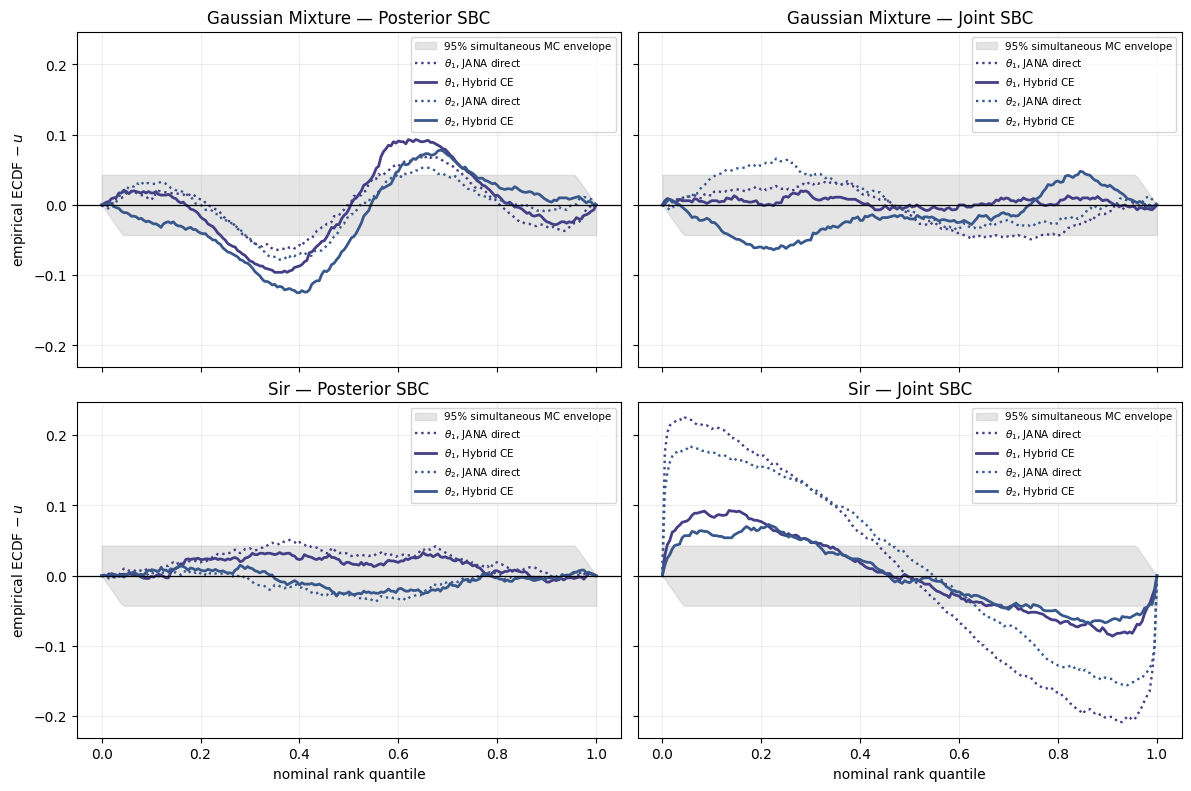

Standalone: /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/exercise9a_JANA_figures_scripts/tutorial_v9_matched_jana_vs_hybrid_ce/plot_fig3_matched_jana_vs_hybrid_ce_sbc.py
Exported /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/exercise9a_JANA_figures_scripts/tutorial_v9_matched_jana_vs_hybrid_ce/fig3_training_ce_family_and_progressive_lr.png and /content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/exercise9a_JANA_figures_scripts/tutorial_v9_matched_jana_vs_hybrid_ce/fig3_training_ce_family_and_progressive_lr.pdf


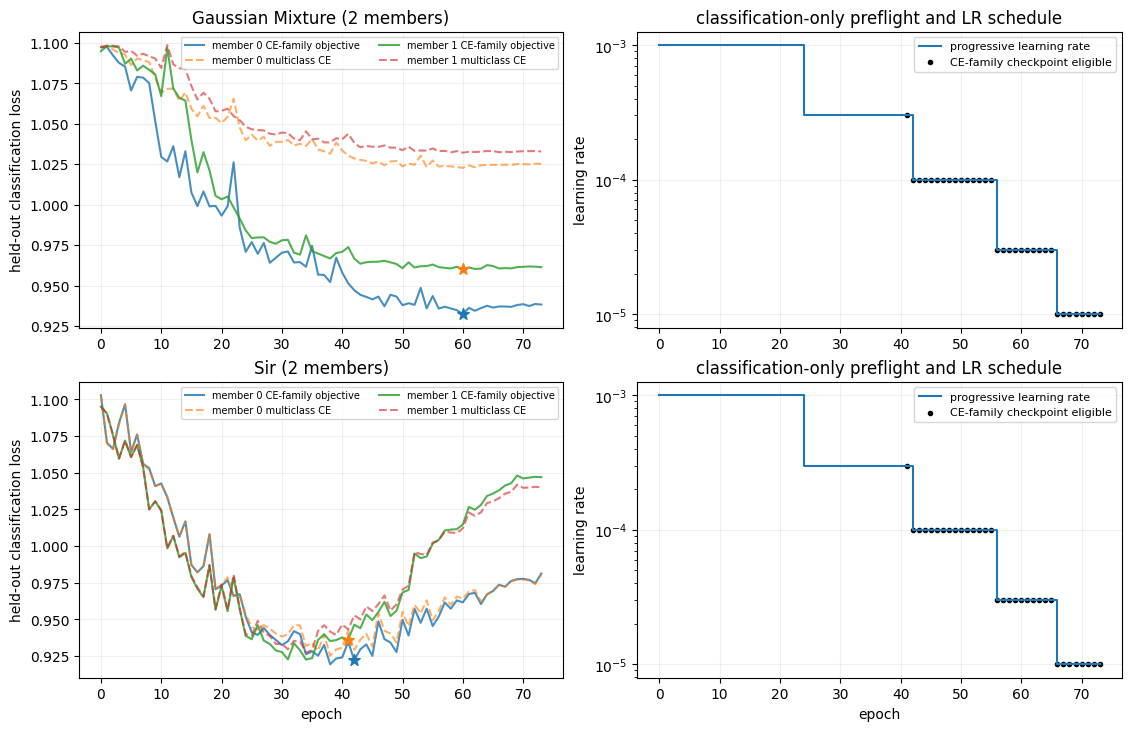

In [21]:
def plot_fig3_four_panel(results):
    fig, axes = plt.subplots(
        2, 2, figsize=(11.8, 7.8), sharex=True, sharey=True, constrained_layout=True
    )
    grid = np.linspace(0.0, 1.0, 201)
    colors = plt.cm.viridis(np.linspace(0.18, 0.82, 8))
    band_rows = []
    for row, task_name in enumerate(("gaussian_mixture", "sir")):
        result = results[task_name]
        names = (
            result["metrics"].query(
                "estimator == 'JANA direct' and diagnostic == 'posterior SBC'"
            )["parameter"].tolist()
        )
        n_ranks = len(result["jana_posterior_ranks"])
        critical = simultaneous_uniform_ecdf_critical(
            n_ranks, confidence=0.95, seed=SEED + 91_000 + row
        )
        lower_band, upper_band = simultaneous_difference_envelope(grid, critical)
        band_rows.append({
            "task": task_name, "n_ranks": n_ranks, "confidence": 0.95,
            "n_mc": SIMULTANEOUS_ECDF_MC, "seed": SEED + 91_000 + row,
            "ks_critical": critical,
        })
        for column, (diagnostic, title) in enumerate(
            (("posterior", "Posterior SBC"), ("joint", "Joint SBC"))
        ):
            ax = axes[row, column]
            ax.fill_between(
                grid, lower_band, upper_band, color="0.75", alpha=0.40,
                label="95% simultaneous MC envelope",
            )
            for index, name in enumerate(names):
                for estimator, prefix, linestyle, linewidth in [
                    ("JANA direct", "jana", ":", 1.7),
                    ("Hybrid CE", "hybrid", "-", 2.0),
                ]:
                    ranks = result[f"{prefix}_{diagnostic}_ranks"]
                    ecdf = (ranks[:, index, None] <= grid[None, :]).mean(axis=0)
                    label = f"{name}, {estimator}"
                    ax.plot(
                        grid, ecdf - grid, lw=linewidth, ls=linestyle,
                        color=colors[index], label=label,
                    )
            ax.axhline(0.0, color="black", lw=0.9)
            ax.set_title(f"{task_name.replace('_', ' ').title()} — {title}")
            ax.grid(alpha=0.2)
            if row == 1:
                ax.set_xlabel("nominal rank quantile")
            if column == 0:
                ax.set_ylabel(r"empirical ECDF $-\,u$")
            ax.legend(fontsize=7.5)
    return fig, pd.DataFrame(band_rows)


if RUN_FIG3:
    fig, fig3_band_table = plot_fig3_four_panel(FIG3_RESULTS)
    fig3_band_table.to_csv(OUTPUT_DIR / "fig3_simultaneous_ecdf_band.csv", index=False)
    export_figure(fig, "fig3_matched_jana_vs_hybrid_ce_sbc")
    plt.show()

    standalone = r'''#!/usr/bin/env python3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path(__file__).resolve().parent
tasks = ("gaussian_mixture", "sir")
fig, axes = plt.subplots(2, 2, figsize=(11.8, 7.8), sharex=True, sharey=True, constrained_layout=True)
grid = np.linspace(0.0, 1.0, 201)
colors = plt.cm.viridis(np.linspace(0.18, 0.82, 8))
bands = pd.read_csv(root / "fig3_simultaneous_ecdf_band.csv").set_index("task")
for row, task in enumerate(tasks):
    d = np.load(root / f"fig3_{task}_ranks.npz", allow_pickle=False)
    names = d["parameter_names"].astype(str)
    critical = float(bands.loc[task, "ks_critical"])
    lower, upper = np.maximum(-grid, -critical), np.minimum(1-grid, critical)
    for col, (diagnostic, title) in enumerate((("posterior", "Posterior SBC"), ("joint", "Joint SBC"))):
        ax = axes[row, col]
        ax.fill_between(grid, lower, upper, color="0.75", alpha=.40, label="95% simultaneous MC envelope")
        for j, name in enumerate(names):
            for estimator, prefix, linestyle, linewidth in [
                ("JANA direct", "jana", ":", 1.7), ("Hybrid CE", "hybrid", "-", 2.0)
            ]:
                ranks = d[f"{prefix}_{diagnostic}_ranks"]
                ecdf = (ranks[:, j, None] <= grid[None, :]).mean(0)
                ax.plot(grid, ecdf-grid, lw=linewidth, ls=linestyle, color=colors[j],
                        label=f"{name}, {estimator}")
        ax.axhline(0, color="black", lw=.9)
        ax.set_title(f"{task.replace('_',' ').title()} — {title}")
        ax.grid(alpha=.2)
        if row == 1: ax.set_xlabel("nominal rank quantile")
        if col == 0: ax.set_ylabel(r"empirical ECDF $-\,u$")
        ax.legend(fontsize=7.5)
fig.savefig(root / "fig3_matched_jana_vs_hybrid_ce_sbc.pdf", bbox_inches="tight")
fig.savefig(root / "fig3_matched_jana_vs_hybrid_ce_sbc.png", dpi=220, bbox_inches="tight")
'''
    (OUTPUT_DIR / "plot_fig3_matched_jana_vs_hybrid_ce_sbc.py").write_text(standalone)
    print("Standalone:", OUTPUT_DIR / "plot_fig3_matched_jana_vs_hybrid_ce_sbc.py")


def plot_fig3_training_schedules(results):
    fig, axes = plt.subplots(2, 2, figsize=(11.2, 7.2), constrained_layout=True)
    for row, task_name in enumerate(("gaussian_mixture", "sir")):
        history = pd.DataFrame(results[task_name]["history"])
        for member_index, member_history in history.groupby("member", sort=True):
            axes[row, 0].plot(
                member_history["epoch"], member_history["objective"], alpha=0.82,
                label=f"member {member_index} CE-family objective",
            )
            axes[row, 0].plot(
                member_history["epoch"], member_history["ce"], ls="--", alpha=0.62,
                label=f"member {member_index} multiclass CE",
            )
            selected = member_history["checkpoint_selected"].astype(bool)
            axes[row, 0].scatter(
                member_history.loc[selected, "epoch"], member_history.loc[selected, "objective"],
                marker="*", s=75, zorder=5,
            )
        axes[row, 0].set(
            title=f"{task_name.replace('_', ' ').title()} ({history['member'].nunique()} members)",
            ylabel="held-out classification loss",
        )
        axes[row, 0].grid(alpha=0.2); axes[row, 0].legend(fontsize=7, ncol=2)
        schedule = history.loc[history["member"] == history["member"].min()]
        axes[row, 1].step(
            schedule["epoch"], schedule["learning_rate"], where="post",
            label="progressive learning rate",
        )
        eligible = schedule["checkpoint_eligible"].astype(bool)
        axes[row, 1].scatter(
            schedule.loc[eligible, "epoch"], schedule.loc[eligible, "learning_rate"],
            s=9, color="black", label="CE-family checkpoint eligible",
        )
        axes[row, 1].set(
            title="classification-only preflight and LR schedule",
            ylabel="learning rate", yscale="log",
        )
        axes[row, 1].grid(alpha=0.2); axes[row, 1].legend(fontsize=8)
    for ax in axes[-1]:
        ax.set_xlabel("epoch")
    return fig


if RUN_FIG3:
    fig = plot_fig3_training_schedules(FIG3_RESULTS)
    export_figure(fig, "fig3_training_ce_family_and_progressive_lr")
    plt.show()
    schedule_script = r'''#!/usr/bin/env python3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
root=Path(__file__).resolve().parent
fig,axes=plt.subplots(2,2,figsize=(11.2,7.2),constrained_layout=True)
for row,task in enumerate(("gaussian_mixture","sir")):
    h=pd.read_csv(root/f"fig3_{task}_training_history.csv")
    for member,mh in h.groupby("member",sort=True):
        axes[row,0].plot(mh.epoch,mh.objective,alpha=.82,label=f"member {member} CE-family objective")
        axes[row,0].plot(mh.epoch,mh.ce,ls="--",alpha=.62,label=f"member {member} multiclass CE")
        selected=mh.checkpoint_selected.astype(bool)
        axes[row,0].scatter(mh.loc[selected,"epoch"],mh.loc[selected,"objective"],marker="*",s=75,zorder=5)
    axes[row,0].set(title=f"{task.replace('_',' ').title()} ({h.member.nunique()} members)",ylabel="held-out classification loss")
    axes[row,0].grid(alpha=.2); axes[row,0].legend(fontsize=7,ncol=2)
    schedule=h.loc[h.member==h.member.min()]
    axes[row,1].step(schedule.epoch,schedule.learning_rate,where="post",label="progressive learning rate")
    ok=schedule.checkpoint_eligible.astype(bool)
    axes[row,1].scatter(schedule.loc[ok,"epoch"],schedule.loc[ok,"learning_rate"],s=9,color="black",label="CE-family checkpoint eligible")
    axes[row,1].set(title="classification-only preflight and LR schedule",ylabel="learning rate",yscale="log")
    axes[row,1].grid(alpha=.2); axes[row,1].legend(fontsize=8)
for a in axes[-1]: a.set_xlabel("epoch")
fig.savefig(root/"fig3_training_ce_family_and_progressive_lr.pdf",bbox_inches="tight")
fig.savefig(root/"fig3_training_ce_family_and_progressive_lr.png",dpi=220,bbox_inches="tight")
'''
    (OUTPUT_DIR / "plot_fig3_training_ce_family.py").write_text(schedule_script)

### Reading the Figure 3 head-to-head

Each panel now overlays matched JANA direct (dotted) and Hybrid CE (solid).  Parameter color is held fixed, both estimators use the same simulator bank and calibration truths, and randomized rank jitter is paired.  The CSVs additionally report paired Hybrid-minus-JANA changes in ECDF MAE, RMSE, and KS; negative values favor the CE correction.

This comparison answers the ML question cleanly: does a structured CE correction improve the same direct NPE/NLE pair?  It does not reproduce the historical TensorFlow checkpoint or its exact optimizer trajectory.  A paper statement of “better than JANA” still requires the `paper` profile, multiple independent training seeds, uncertainty across seeds, and disclosure of any proposal-ESS failures.  A favorable posterior SBC curve with a worse joint SBC curve indicates that the learned likelihood/posterior composition was degraded, not improved.

## Figure 6 campaign: a physical, eventwise DDM likelihood

JANA encoded response by the sign of reaction time and appended a Gaussian dummy coordinate because its coupling flow required at least two continuous dimensions.  Here we keep the physical factorization

\[
 p(y,t\mid\theta)=p(y\mid\theta)\,
 p(\log t\mid y,\theta)\,t^{-1},\qquad y\in\{0,1\},\ t>0.
\]

The response term is a Bernoulli network; the conditional log-time term is a scalar spline-flow mixture; and the learned $c$-head corrects events.  In log-time coordinates the Jacobian is absent, while every reported physical log likelihood subtracts $\log t$.  If a legacy two-dimensional flow is checked, its dummy variable is defined on a unit-density auxiliary measure, so its log-density constant is exactly $\log 1=0$; it is never treated as a measured event.  This convention prevents arbitrary dummy constants from shifting the marginal likelihood.

The posterior context is a trainable permutation-invariant DeepSet plus $\log N$.  Its structured $a$- and eventwise $c$-heads use stored coordinatewise median/MAD-asinh transforms and the same 1/2/4-member centered-logit/head-averaged ensemble as Figure 3.  S/P/L data-set rows stay in one group for train/validation splitting.  The structured classifier uses only multiclass CE plus balanced direct-$a$ BCE through the progressive-LR preflight and checkpoint selection.  After the checkpoint is frozen, an independent validation-only A/B bank measures posterior and eventwise likelihood mass, and a separate IID bank measures raw-bridge variance.  These values are exported as consistency diagnostics and never enter gradients or selection.

The likelihood correction is summed eventwise, so the model handles the configured 80–120 trials without flattening or ordering a set; sampling is capped by the trials actually available in each cached row and fails if a row is shorter than the configured minimum.  The structured data-set scores remain $(a,0,a-c_{1:N})$, with $c_{1:N}=\sum_i c_i$.  Event normalization is estimated and applied only after training; under the conditional-i.i.d. model it implies data-set normalization.

In [27]:
JANA_REPOSITORY = "https://github.com/bayesflow-org/JANA-Paper.git"
JANA_COMMIT = "6cbbc94faf0aa85147986f7f9516d13a52551bd4"
JANA_OSF_PROJECT = "2nbk6"
JANA_SHARED_ROOT = Path(os.environ.get("EX9A_JANA_SHARED_ROOT", PERSIST_ROOT.parent / "shared_jana"))
JANA_REPO_ROOT = Path(os.environ.get(
    "JANA_REPO_ROOT", JANA_SHARED_ROOT / f"JANA-Paper-{JANA_COMMIT[:12]}"
))
JANA_OSF_CLONE_ROOT = Path(os.environ.get(
    "JANA_OSF_CLONE_ROOT", JANA_SHARED_ROOT / f"OSF-{JANA_OSF_PROJECT}"
))
JANA_DATA_ROOT = Path(os.environ.get(
    "JANA_DATA_ROOT", JANA_OSF_CLONE_ROOT / "osfstorage"
))
JANA_OSF_COMPLETION_MANIFEST = JANA_OSF_CLONE_ROOT / "validated_download.json"


def prepare_pinned_jana_checkout(repo_root=JANA_REPO_ROOT, allow_clone=False):
    repo_root = Path(repo_root)
    if not (repo_root / ".git").exists():
        if not allow_clone:
            raise FileNotFoundError(
                f"No JANA checkout at {repo_root}. Set JANA_REPO_ROOT or "
                "ALLOW_PINNED_GIT_CLONE=True. This never downloads OSF project 2nbk6."
            )
        repo_root.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(
            ["git", "clone", "--filter=blob:none", "--no-checkout", JANA_REPOSITORY, str(repo_root)],
            check=True,
        )
        subprocess.run(
            ["git", "-C", str(repo_root), "sparse-checkout", "set", "experiments/diffusion_model/assets"],
            check=True,
        )
        subprocess.run(
            ["git", "-C", str(repo_root), "checkout", "--detach", JANA_COMMIT],
            check=True,
        )
    actual = subprocess.check_output(
        ["git", "-C", str(repo_root), "rev-parse", "HEAD"], text=True
    ).strip()
    if actual != JANA_COMMIT:
        raise RuntimeError(
            f"Expected JANA commit {JANA_COMMIT}, found {actual}. The notebook will not "
            "change an existing checkout automatically."
        )
    return repo_root


def inspect_ddm_inputs(require_complete=True):
    repo = prepare_pinned_jana_checkout(JANA_REPO_ROOT, ALLOW_PINNED_GIT_CLONE)
    posterior_files = sorted(
        (JANA_DATA_ROOT / "posterior" / "training" / "sim_data").glob("*.feather")
    )
    likelihood_files = sorted(
        (JANA_DATA_ROOT / "likelihood" / "training" / "sim_data").glob("*.feather")
    )
    posterior_parameter_files = sorted(
        (JANA_DATA_ROOT / "posterior" / "training" / "parameters").glob("*.feather")
    )
    likelihood_parameter_files = sorted(
        (JANA_DATA_ROOT / "likelihood" / "training" / "parameters").glob("*.feather")
    )
    required_assets = [
        repo / "experiments" / "diffusion_model" / "assets" / "bmc_results_100.csv",
        repo / "experiments" / "diffusion_model" / "assets" / "evaluation" / "parameters" / "01.feather",
        repo / "experiments" / "diffusion_model" / "assets" / "evaluation" / "sim_data" / "01.feather",
        repo / "experiments" / "diffusion_model" / "assets" / "evaluation" / "analytic_likelihood" / "01.feather",
    ]
    missing = [str(path) for path in required_assets if not path.exists()]
    bank_files = (
        posterior_files + likelihood_files
        + posterior_parameter_files + likelihood_parameter_files
    )
    expected_posterior_names = {"01.feather"}
    expected_likelihood_names = {f"{index:02d}.feather" for index in range(1, 11)}
    observed_names = {
        "posterior_sim": {path.name for path in posterior_files},
        "posterior_parameters": {path.name for path in posterior_parameter_files},
        "likelihood_sim": {path.name for path in likelihood_files},
        "likelihood_parameters": {path.name for path in likelihood_parameter_files},
    }
    expected_names = {
        "posterior_sim": expected_posterior_names,
        "posterior_parameters": expected_posterior_names,
        "likelihood_sim": expected_likelihood_names,
        "likelihood_parameters": expected_likelihood_names,
    }
    shard_names_match = observed_names == expected_names
    nonempty = len(bank_files) == 22 and all(path.stat().st_size > 0 for path in bank_files)
    total_bytes = sum(path.stat().st_size for path in bank_files)
    complete = (
        not missing and shard_names_match and nonempty
        and total_bytes >= 5_900_000_000
    )
    report = {
        "complete": complete,
        "repo": repo,
        "posterior_files": posterior_files,
        "likelihood_files": likelihood_files,
        "posterior_parameter_files": posterior_parameter_files,
        "likelihood_parameter_files": likelihood_parameter_files,
        "total_bytes": total_bytes,
        "shard_names_match": shard_names_match,
        "observed_names": {key: sorted(value) for key, value in observed_names.items()},
        "required_assets": required_assets,
        "missing_assets": missing,
    }
    require_complete=False
    if require_complete and not complete:
        raise FileNotFoundError(
            "The official DDM bank is incomplete. "
            f"Assets missing={missing}; posterior shards={len(posterior_files)}; "
            f"likelihood shards={len(likelihood_files)}; parameter shards="
            f"{len(posterior_parameter_files)}/{len(likelihood_parameter_files)}; "
            f"bytes={total_bytes:,}; exact shard names={shard_names_match}. "
            "Set DOWNLOAD_JANA_OSF=True "
            "once in a Drive-backed runtime or point JANA_DATA_ROOT at a complete clone."
        )
    return report


def prepare_jana_osf(download=False):
    """Validate or explicitly download OSF 2nbk6 into persistent storage."""
    JANA_OSF_CLONE_ROOT.parent.mkdir(parents=True, exist_ok=True)
    report = inspect_ddm_inputs(require_complete=False)
    if not report["complete"] and download:
        if importlib.util.find_spec("osfclient") is None:
            raise ImportError("Install osfclient before the one-time OSF download.")
        JANA_OSF_CLONE_ROOT.mkdir(parents=True, exist_ok=True)
        print(
            f"Downloading OSF {JANA_OSF_PROJECT} (~6 GB) once into "
            f"{JANA_OSF_CLONE_ROOT}. Existing files are left for osfclient to verify/replace."
        )
        #import os
        #os.system("osfclient osf -p 2nbk6 clone "+str(JANA_OSF_CLONE_ROOT))
        #subprocess.run(
        #    [
        #        sys.executable, "-m", "osfclient", "-p", JANA_OSF_PROJECT,
        #        "clone", "-U", str(JANA_OSF_CLONE_ROOT),
        #    ],
        #    check=True,
        #)
        report = inspect_ddm_inputs(require_complete=True)
        payload = {
            "project": JANA_OSF_PROJECT,
            "jana_commit": JANA_COMMIT,
            "data_root": str(JANA_DATA_ROOT),
            "posterior_shards": len(report["posterior_files"]),
            "likelihood_shards": len(report["likelihood_files"]),
            "total_bytes": report["total_bytes"],
            "observed_names": report["observed_names"],
            "validated": True,
        }
        JANA_OSF_COMPLETION_MANIFEST.write_text(json.dumps(payload, indent=2))
    elif report["complete"]:
        payload = {
            "project": JANA_OSF_PROJECT,
            "jana_commit": JANA_COMMIT,
            "data_root": str(JANA_DATA_ROOT),
            "posterior_shards": len(report["posterior_files"]),
            "likelihood_shards": len(report["likelihood_files"]),
            "total_bytes": report["total_bytes"],
            "observed_names": report["observed_names"],
            "validated": True,
        }
        JANA_OSF_COMPLETION_MANIFEST.parent.mkdir(parents=True, exist_ok=True)
        JANA_OSF_COMPLETION_MANIFEST.write_text(json.dumps(payload, indent=2))
        print("Reusing validated JANA OSF bank:", JANA_DATA_ROOT)
    else:
        print("JANA OSF bank is not downloaded; RUN_DDM must remain False.")
    return report


def require_ddm_inputs():
    report = prepare_jana_osf(download=DOWNLOAD_JANA_OSF)
    if not report["complete"]:
        report = inspect_ddm_inputs(require_complete=True)
    if PROFILE == "paper" and (
        CFG["ddm_datasets"] is not None or CFG["ddm_event_cap"] is not None
    ):
        raise RuntimeError("The paper profile must not cap the official DDM banks.")
    return (
        report["repo"], report["posterior_files"],
        report["likelihood_files"], report["required_assets"],
    )


print("Persistent JANA checkout:", JANA_REPO_ROOT)
print("Persistent OSF clone:", JANA_OSF_CLONE_ROOT)
print("Expected OSF data root:", JANA_DATA_ROOT)
if DOWNLOAD_JANA_OSF:
    OSF_PREPARATION_REPORT = prepare_jana_osf(download=True)
    print("One-time OSF preparation complete:", OSF_PREPARATION_REPORT["complete"])

Persistent JANA checkout: /content/drive/MyDrive/hybrid_nsbi_ml/shared_jana/JANA-Paper-6cbbc94faf0a
Persistent OSF clone: /content/drive/MyDrive/hybrid_nsbi_ml/shared_jana/OSF-2nbk6
Expected OSF data root: /content/drive/MyDrive/hybrid_nsbi_ml/shared_jana/OSF-2nbk6/osfstorage
One-time OSF preparation complete: False


### Optional one-time Drive preparation

The Colab bootstrap mounts Google Drive by default.  Set

```python
DOWNLOAD_JANA_OSF = True
```

for one run and execute the preparation/campaign cells.  The notebook invokes the documented `osfclient` command

```bash
python -m osfclient -p 2nbk6 clone -U <persistent-drive-directory>
```

and writes a completion manifest **only after** the exact official shard-name sets, non-empty files, at least 5.9 GB of bank data, and all evaluation assets have been found.  Reset `DOWNLOAD_JANA_OSF=False` after the first successful download; subsequent sessions reuse the same Drive directory.  The `-U` mode updates/resumes an existing directory, while the local gate rejects wrong shard sets and grossly partial clones before writing the manifest.  `JANA_REPO_ROOT`, `JANA_OSF_CLONE_ROOT`, and `JANA_DATA_ROOT` remain environment-overridable.

The tutorial likelihood bank is streamed from Arrow record batches with a real event cap.  Only the uncapped `paper` profile is a full-bank comparison, and it requires a high-memory runtime even though the compressed files persist on Drive.

In [28]:
DDM_PARAMETER_NAMES = ("v", "a", "t0", "w")
DDM_PRIOR_LOC = np.asarray([0.0, 1.0, 0.4, 0.5], dtype=np.float64)
DDM_PRIOR_SCALE = np.asarray([10.0, 1.0, 0.2, 0.1], dtype=np.float64)
DDM_PRIOR_LOW = np.asarray([-5.0, 0.5, 0.2, 0.3], dtype=np.float64)
DDM_PRIOR_HIGH = np.asarray([5.0, 3.0, 1.0, 0.7], dtype=np.float64)


class BoundedLogitTransform:
    def __init__(self, low, high, clip=1.0e-6):
        self.low = np.asarray(low, dtype=np.float64)
        self.high = np.asarray(high, dtype=np.float64)
        self.clip = float(clip)

    def forward(self, theta):
        theta = as_2d(theta, "theta").astype(np.float64)
        unit = np.clip((theta - self.low) / (self.high - self.low), self.clip, 1.0 - self.clip)
        return (np.log(unit) - np.log1p(-unit)).astype(np.float32)

    def inverse(self, latent):
        latent = as_2d(latent, "latent").astype(np.float64)
        unit = 1.0 / (1.0 + np.exp(-np.clip(latent, -80.0, 80.0)))
        return (self.low + (self.high - self.low) * unit).astype(np.float32)

    def log_abs_det_inverse(self, latent):
        latent = as_2d(latent, "latent").astype(np.float64)
        return np.sum(
            np.log(self.high - self.low)
            - np.logaddexp(0.0, -latent) - np.logaddexp(0.0, latent), axis=1
        )


DDM_TRANSFORM = BoundedLogitTransform(DDM_PRIOR_LOW, DDM_PRIOR_HIGH)


def ddm_prior_log_prob_latent(latent):
    latent = as_2d(latent, "latent")
    theta = DDM_TRANSFORM.inverse(latent).astype(np.float64)
    alpha = (DDM_PRIOR_LOW - DDM_PRIOR_LOC) / DDM_PRIOR_SCALE
    beta = (DDM_PRIOR_HIGH - DDM_PRIOR_LOC) / DDM_PRIOR_SCALE
    log_normalizer = np.log(np.maximum(ndtr(beta) - ndtr(alpha), 1.0e-300))
    standardized = (theta - DDM_PRIOR_LOC) / DDM_PRIOR_SCALE
    log_density = np.sum(
        -0.5 * standardized**2 - np.log(DDM_PRIOR_SCALE)
        - 0.5 * np.log(2.0 * np.pi) - log_normalizer,
        axis=1,
    )
    inside = np.all((theta >= DDM_PRIOR_LOW) & (theta <= DDM_PRIOR_HIGH), axis=1)
    return np.where(inside, log_density + DDM_TRANSFORM.log_abs_det_inverse(latent), -np.inf)


def _paired_parameter_file(simulation_file):
    parts = list(Path(simulation_file).parts)
    reverse_index = len(parts) - 1 - parts[::-1].index("sim_data")
    parts[reverse_index] = "parameters"
    return Path(*parts)


def _ddm_response_offset(observed, source):
    observed = {float(value) for value in observed}
    if not observed or not observed <= {0.0, 1.0, 2.0}:
        raise ValueError(f"{source}: invalid DDM response values {sorted(observed)}.")
    if 0.0 in observed and 2.0 in observed:
        raise ValueError(f"{source}: mixed 0/1 and 1/2 response encodings.")
    if 0.0 in observed:
        return 0.0
    if 2.0 in observed:
        return 1.0
    raise ValueError(
        f"{source}: only response value 1 was observed; 0/1 versus 1/2 "
        "encoding cannot be determined safely."
    )


def _detect_streamed_ddm_response_offset(dataset, batch_size, source):
    observed = set()
    scanner = dataset.scanner(
        columns=["resp"], batch_size=int(batch_size), use_threads=False
    )
    for record_batch in scanner.to_batches():
        values = np.asarray(
            record_batch.column(0).to_numpy(zero_copy_only=False), dtype=np.float32
        )
        observed.update(np.unique(values).tolist())
        if not observed <= {0.0, 1.0, 2.0} or 0.0 in observed or 2.0 in observed:
            return _ddm_response_offset(observed, source)
    return _ddm_response_offset(observed, source)


def load_ddm_feather(simulation_file, limit=None):
    try:
        frame = pd.read_feather(simulation_file, columns=["cnd", "resp", "rt"])
        parameters = pd.read_feather(
            _paired_parameter_file(simulation_file), columns=list(DDM_PARAMETER_NAMES)
        )
    except ImportError as exc:
        raise ImportError("DDM feather files require pyarrow (`pip install pyarrow==10.0.1`).") from exc
    theta = parameters.to_numpy(dtype=np.float32)
    if limit is not None:
        theta = theta[:int(limit)]
    n_sets = len(parameters)
    if len(frame) % n_sets:
        raise ValueError(f"{simulation_file} does not contain a fixed number of trials per parameter row.")
    n_trials = len(frame) // n_sets
    raw_all = frame.to_numpy().reshape(n_sets, n_trials, 3)
    response_offset = _ddm_response_offset(
        np.unique(raw_all[..., 1]).tolist(), str(simulation_file)
    )
    raw = raw_all[:len(theta)]
    response = raw[..., 1].astype(np.float32)
    response = response - response_offset
    rt = raw[..., 2].astype(np.float64)
    if np.any(rt <= 0.0):
        raise ValueError("Physical reaction times must be positive before log transformation.")
    events = np.stack([response, np.log(rt).astype(np.float32)], axis=-1)
    mask = np.ones(events.shape[:2], dtype=np.float32)
    return theta, events.astype(np.float32), mask


def load_ddm_set_bank(files, max_datasets, seed):
    theta_parts, event_parts = [], []
    remaining = None if max_datasets is None else int(max_datasets)
    for path in files:
        if remaining == 0:
            break
        theta, events, _ = load_ddm_feather(path, limit=remaining)
        theta_parts.append(theta)
        event_parts.append(events)
        if remaining is not None:
            remaining -= len(theta)
    if not theta_parts:
        raise FileNotFoundError("No DDM posterior training rows were loaded.")
    theta = np.concatenate(theta_parts)
    events = np.concatenate(event_parts)
    rng = np.random.default_rng(seed)
    selected_events, masks = [], []
    maximum = int(CFG["ddm_trials_max"])
    observed_trial_counts = []
    for row_index, row in enumerate(events):
        available = int(len(row))
        observed_trial_counts.append(available)
        minimum = int(CFG["ddm_trials_min"])
        if available < minimum:
            raise ValueError(
                f"DDM row {row_index} has {available} trials, below configured minimum {minimum}."
            )
        upper = min(int(CFG["ddm_trials_max"]), available)
        n = int(rng.integers(minimum, upper + 1))
        start = int(rng.integers(0, available - n + 1))
        selected = row[start:start + n]
        padded = np.zeros((maximum, 2), dtype=np.float32)
        mask = np.zeros(maximum, dtype=np.float32)
        padded[:n] = selected
        mask[:n] = 1.0
        selected_events.append(padded)
        masks.append(mask)
    print(
        "DDM source trials per row: "
        f"min={min(observed_trial_counts)}, max={max(observed_trial_counts)}; "
        f"sampled up to {min(int(CFG['ddm_trials_max']), max(observed_trial_counts))}."
    )
    return theta.astype(np.float32), np.stack(selected_events), np.stack(masks)


def _stream_ddm_event_file(simulation_file, event_limit, rng, batch_size=262_144):
    try:
        import pyarrow.dataset as ds
    except ImportError as exc:
        raise ImportError("Streaming DDM Feather files requires pyarrow.") from exc
    parameters = pd.read_feather(
        _paired_parameter_file(simulation_file), columns=list(DDM_PARAMETER_NAMES)
    ).to_numpy(dtype=np.float32)
    dataset = ds.dataset(str(simulation_file), format="ipc")
    n_rows = int(dataset.count_rows())
    if len(parameters) == 0 or n_rows % len(parameters):
        raise ValueError(f"{simulation_file} does not have fixed trials per parameter row.")
    n_trials = n_rows // len(parameters)
    inside = np.all((parameters >= DDM_PRIOR_LOW) & (parameters <= DDM_PRIOR_HIGH), axis=1)
    z_parameters = DDM_TRANSFORM.forward(parameters)
    response_offset = _detect_streamed_ddm_response_offset(
        dataset, batch_size, str(simulation_file)
    )
    z_parts, event_parts, offset, accepted = [], [], 0, 0
    stopped_for_limit = False
    scanner = dataset.scanner(
        columns=["resp", "rt"], batch_size=int(batch_size), use_threads=False
    )
    for record_batch in scanner.to_batches():
        rows = int(record_batch.num_rows)
        parameter_index = np.arange(offset, offset + rows, dtype=np.int64) // n_trials
        offset += rows
        keep = inside[parameter_index]
        if not np.any(keep):
            continue
        response = np.asarray(
            record_batch.column(0).to_numpy(zero_copy_only=False), dtype=np.float32
        )[keep]
        expected = {response_offset, response_offset + 1.0}
        observed = set(np.unique(response).tolist())
        if not observed <= expected:
            raise ValueError(
                f"{simulation_file}: response values {sorted(observed)} do not match "
                f"the file-level encoding {sorted(expected)}."
            )
        response = response - response_offset
        rt = np.asarray(record_batch.column(1).to_numpy(zero_copy_only=False), dtype=np.float64)[keep]
        if np.any(rt <= 0.0):
            raise ValueError("Physical reaction times must be positive before log transformation.")
        z_batch = z_parameters[parameter_index[keep]]
        events = np.column_stack([response, np.log(rt)]).astype(np.float32)
        if event_limit is not None:
            remaining = int(event_limit) - accepted
            if remaining <= 0:
                stopped_for_limit = True
                break
            if len(events) > remaining:
                chosen = rng.choice(len(events), size=remaining, replace=False)
                z_batch, events = z_batch[chosen], events[chosen]
        z_parts.append(z_batch.astype(np.float32))
        event_parts.append(events)
        accepted += len(events)
        if event_limit is not None and accepted >= int(event_limit):
            stopped_for_limit = offset < n_rows
            break
    if offset > n_rows:
        raise RuntimeError(f"{simulation_file}: Arrow scanner exceeded its declared row count.")
    if not stopped_for_limit and offset != n_rows:
        raise RuntimeError(
            f"{simulation_file}: Arrow scanner consumed {offset} of {n_rows} rows."
        )
    if not z_parts:
        return np.empty((0, 4), dtype=np.float32), np.empty((0, 2), dtype=np.float32)
    return np.concatenate(z_parts), np.concatenate(event_parts)


def load_ddm_event_bank(files, max_events, seed):
    rng = np.random.default_rng(seed)
    files = [Path(path) for path in files]
    if max_events is not None:
        files = [files[index] for index in rng.permutation(len(files))]
    z_parts, event_parts = [], []
    remaining = None if max_events is None else int(max_events)
    for position, path in enumerate(files):
        if remaining is not None and remaining <= 0:
            break
        files_left = len(files) - position
        target = None if remaining is None else int(math.ceil(remaining / files_left))
        z_batch, events = _stream_ddm_event_file(path, target, rng)
        if len(events):
            z_parts.append(z_batch); event_parts.append(events)
            if remaining is not None:
                remaining -= len(events)
    if not z_parts:
        raise FileNotFoundError("No DDM likelihood training events were loaded.")
    z = np.concatenate(z_parts)
    events = np.concatenate(event_parts)
    if max_events is not None and len(events) > int(max_events):
        raise RuntimeError("The streamed DDM event cap was exceeded.")
    print(f"Streamed {len(events):,} DDM likelihood events (cap={max_events}).")
    return z, events


In [29]:
class DeepSetEncoder(nn.Module):
    def __init__(self, event_mean, event_std, embedding_dim=64, width=192):
        super().__init__()
        self.register_buffer("event_mean", torch.as_tensor(event_mean, dtype=torch.float32))
        self.register_buffer("event_std", torch.as_tensor(event_std, dtype=torch.float32))
        self.phi = nn.Sequential(
            nn.Linear(2, width), nn.SiLU(), nn.Linear(width, width), nn.SiLU(),
            nn.Linear(width, width), nn.SiLU(),
        )
        self.rho = nn.Sequential(
            nn.Linear(2 * width + 1, width), nn.SiLU(),
            nn.Linear(width, embedding_dim), nn.SiLU(),
        )

    def forward(self, events, mask):
        scaled = (events - self.event_mean) / self.event_std
        hidden = self.phi(scaled)
        weight = mask[..., None]
        count = weight.sum(dim=1).clamp_min(1.0)
        mean = (hidden * weight).sum(dim=1) / count
        variance = ((hidden - mean[:, None, :]).square() * weight).sum(dim=1) / count
        return self.rho(torch.cat([mean, torch.sqrt(variance + 1.0e-6), torch.log(count)], dim=-1))


class SetRegressionModel(nn.Module):
    def __init__(self, encoder, embedding_dim, n_parameters):
        super().__init__()
        self.encoder = encoder
        self.regression = nn.Sequential(
            nn.Linear(embedding_dim, 256), nn.SiLU(), nn.Linear(256, n_parameters)
        )

    def forward(self, events, mask):
        return self.regression(self.encoder(events, mask))


def train_ddm_encoder(z, events, mask, seed):
    seed_everything(seed)
    valid = events[mask.astype(bool)]
    event_mean = valid.mean(axis=0)
    event_std = np.maximum(valid.std(axis=0), 1.0e-4)
    z_mean, z_std = z.mean(axis=0), np.maximum(z.std(axis=0), 1.0e-4)
    encoder = DeepSetEncoder(event_mean, event_std).to(DEVICE)
    model = SetRegressionModel(encoder, 64, z.shape[1]).to(DEVICE)
    checkpoint = MODEL_DIR / "ddm_set_encoder.pt"
    fingerprint = array_digest(z, events[:min(512, len(events))], mask[:min(512, len(mask))])
    if checkpoint.exists() and not FORCE_RETRAIN:
        saved = torch.load(checkpoint, map_location=DEVICE, weights_only=False)
        if saved.get("fingerprint") != fingerprint:
            raise RuntimeError("Stale DDM set-encoder checkpoint; bump RUN_TAG or retrain.")
        model.load_state_dict(saved["state_dict"])
        return model.encoder.eval()
    dataset = TensorDataset(torch.as_tensor(events), torch.as_tensor(mask), torch.as_tensor(z))
    loader = DataLoader(dataset, batch_size=64 if PROFILE != "smoke" else 16, shuffle=True,
                        generator=torch.Generator().manual_seed(seed))
    optimizer = torch.optim.AdamW(model.parameters(), lr=5.0e-4, weight_decay=0.0)
    n_epochs = 2 if PROFILE == "smoke" else (30 if PROFILE == "tutorial" else 100)
    best, best_state = np.inf, None
    for epoch in range(n_epochs):
        model.train()
        total, count = 0.0, 0
        for batch_events, batch_mask, batch_z in loader:
            batch_events, batch_mask, batch_z = batch_events.to(DEVICE), batch_mask.to(DEVICE), batch_z.to(DEVICE)
            target = (batch_z - torch.as_tensor(z_mean, device=DEVICE)) / torch.as_tensor(z_std, device=DEVICE)
            prediction = model(batch_events, batch_mask)
            loss = F.mse_loss(prediction, target)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total += float(loss) * len(batch_events)
            count += len(batch_events)
        mean_loss = total / count
        if mean_loss < best:
            best, best_state = mean_loss, copy.deepcopy(model.state_dict())
        if epoch in {0, n_epochs - 1}:
            print(f"DDM DeepSet epoch {epoch + 1}/{n_epochs}: regression MSE={mean_loss:.5f}")
    model.load_state_dict(best_state)
    torch.save({"state_dict": best_state, "fingerprint": fingerprint,
                "z_mean": z_mean, "z_std": z_std}, checkpoint)
    return model.encoder.eval()


def encode_ddm_sets(encoder, events, mask, batch_size=256):
    chunks = []
    encoder.eval()
    with torch.no_grad():
        for start in range(0, len(events), batch_size):
            chunks.append(encoder(
                torch.as_tensor(events[start:start + batch_size], device=DEVICE),
                torch.as_tensor(mask[start:start + batch_size], device=DEVICE),
            ).cpu().numpy())
    return np.concatenate(chunks).astype(np.float32)

In [30]:
class BernoulliResponseModel(nn.Module):
    def __init__(self, input_mean, input_std, width, blocks):
        super().__init__()
        self.register_buffer("input_mean", torch.as_tensor(input_mean, dtype=torch.float32))
        self.register_buffer("input_std", torch.as_tensor(input_std, dtype=torch.float32))
        self.head = ResidualRatioHead(
            len(input_mean), width, blocks, ratio_bound=CLASSIFIER_LOG_RATIO_BOUND
        )

    def forward(self, z):
        return self.head((z - self.input_mean) / self.input_std)


def train_ddm_response(z_events, events, seed):
    seed_everything(seed)
    model = BernoulliResponseModel(
        z_events.mean(axis=0), np.maximum(z_events.std(axis=0), 1.0e-4),
        CFG["class_width"], CFG["class_blocks"],
    ).to(DEVICE)
    checkpoint = MODEL_DIR / "ddm_response_bernoulli.pt"
    fingerprint = array_digest(z_events, events[:, :1])
    configuration = {
        "architecture": CLASSIFIER_ARCHITECTURE_VERSION,
        "width": CFG["class_width"], "blocks": CFG["class_blocks"],
        "log_ratio_bound": CLASSIFIER_LOG_RATIO_BOUND,
    }
    if checkpoint.exists() and not FORCE_RETRAIN:
        saved = torch.load(checkpoint, map_location=DEVICE, weights_only=False)
        if (
            saved.get("fingerprint") != fingerprint
            or saved.get("configuration") != configuration
        ):
            raise RuntimeError("Stale DDM response checkpoint; bump RUN_TAG or retrain.")
        model.load_state_dict(saved["state_dict"])
        return model.eval()
    dataset = TensorDataset(torch.as_tensor(z_events), torch.as_tensor(events[:, 0]))
    loader = DataLoader(dataset, batch_size=2048 if PROFILE != "smoke" else 128,
                        shuffle=True, generator=torch.Generator().manual_seed(seed))
    optimizer = torch.optim.AdamW(model.parameters(), lr=5.0e-4, weight_decay=0.0)
    n_epochs = 2 if PROFILE == "smoke" else (18 if PROFILE == "tutorial" else 45)
    best, best_state = np.inf, None
    for epoch in range(n_epochs):
        model.train()
        total, count = 0.0, 0
        for batch_z, response in loader:
            batch_z, response = batch_z.to(DEVICE), response.to(DEVICE)
            loss = F.binary_cross_entropy_with_logits(model(batch_z), response)
            optimizer.zero_grad(set_to_none=True); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0); optimizer.step()
            total += float(loss) * len(batch_z); count += len(batch_z)
        mean_loss = total / count
        if mean_loss < best:
            best, best_state = mean_loss, copy.deepcopy(model.state_dict())
        if epoch in {0, n_epochs - 1}:
            print(f"DDM response epoch {epoch + 1}/{n_epochs}: BCE={mean_loss:.5f}")
    model.load_state_dict(best_state)
    torch.save({
        "state_dict": best_state, "fingerprint": fingerprint,
        "configuration": configuration,
    }, checkpoint)
    return model.eval()


def ddm_response_log_prob(response_model, z, response, batch_size=65_536):
    z = as_2d(z, "z")
    response = np.asarray(response, dtype=np.float32).reshape(-1)
    chunks = []
    response_model.eval()
    with torch.no_grad():
        for start in range(0, len(z), batch_size):
            z_batch = torch.as_tensor(z[start:start + batch_size], device=DEVICE)
            y_batch = torch.as_tensor(response[start:start + batch_size], device=DEVICE)
            logits = response_model(z_batch)
            chunks.append(-F.binary_cross_entropy_with_logits(logits, y_batch, reduction="none").cpu().numpy())
    return np.concatenate(chunks)


def train_ddm_likelihood_base(z_events, events, seed):
    response_model = train_ddm_response(z_events, events, seed)
    rt_context = np.column_stack([z_events, events[:, 0]]).astype(np.float32)
    model_config, training_config = benchmark_flow_configs(1)
    q_log_rt = train_spline_flow_ensemble(
        events[:, 1:2], context=rt_context,
        checkpoint=MODEL_DIR / "ddm_q_log_rt.pt",
        ensemble_size=CFG["flow_ensemble"], model_config=model_config,
        training_config=training_config, device=DEVICE, seed=seed + 1,
        load_if_available=not FORCE_RETRAIN, verify_checkpoint_data=True,
    )
    return response_model, q_log_rt


def ddm_base_event_log_prob(response_model, q_log_rt, z, events):
    z, events = as_2d(z, "z"), as_2d(events, "events")
    context = np.column_stack([z, events[:, 0]])
    return (
        ddm_response_log_prob(response_model, z, events[:, 0])
        + spline_flow_ensemble_log_prob(q_log_rt, events[:, 1:2], context=context)
    )


def sample_ddm_base_events(response_model, q_log_rt, z, n_samples, seed):
    # This composite draw reserves the two-seed namespace [seed, seed + 1]:
    # Bernoulli responses use seed; conditional log-times use seed + 1.
    z = as_2d(z, "z")
    rng = np.random.default_rng(seed)
    response_model.eval()
    with torch.no_grad():
        logits = response_model(torch.as_tensor(z, device=DEVICE)).cpu().numpy()
    probability = 1.0 / (1.0 + np.exp(-np.clip(logits, -40.0, 40.0)))
    response = (rng.random((len(z), int(n_samples))) < probability[:, None]).astype(np.float32)
    repeated_z = np.repeat(z[:, None, :], int(n_samples), axis=1)
    context = np.concatenate([repeated_z, response[..., None]], axis=-1)
    log_rt = sample_spline_flow_ensemble(
        q_log_rt, 1, context=context.reshape(-1, context.shape[-1]), seed=seed + 1
    ).reshape(len(z), int(n_samples), 1)
    return np.concatenate([response[..., None], log_rt], axis=-1).astype(np.float32)

In [31]:
class DDMStructuredThreeClass(nn.Module):
    def __init__(self, a_median, a_scale, c_median, c_scale, width, blocks):
        super().__init__()
        self.register_buffer("a_median", torch.as_tensor(a_median, dtype=torch.float32))
        self.register_buffer("a_scale", torch.as_tensor(a_scale, dtype=torch.float32))
        self.register_buffer("c_median", torch.as_tensor(c_median, dtype=torch.float32))
        self.register_buffer("c_scale", torch.as_tensor(c_scale, dtype=torch.float32))
        self.a_head = ResidualRatioHead(
            len(a_median), width, blocks, ratio_bound=CLASSIFIER_LOG_RATIO_BOUND
        )
        self.c_head = ResidualRatioHead(
            len(c_median), width, blocks, ratio_bound=CLASSIFIER_LOG_RATIO_BOUND
        )

    def a_ratio(self, z, context):
        values = torch.cat([z, context], dim=-1)
        transformed = torch.asinh((values - self.a_median) / self.a_scale)
        return self.a_head(transformed)

    def event_c_ratio(self, z, event):
        values = torch.cat([z, event], dim=-1)
        transformed = torch.asinh((values - self.c_median) / self.c_scale)
        return self.c_head(transformed)

    def ratios(self, z, context, events, mask):
        a = self.a_ratio(z, context)
        batch, n_trials, _ = events.shape
        repeated_z = z[:, None, :].expand(-1, n_trials, -1)
        c_event = self.event_c_ratio(
            repeated_z.reshape(batch * n_trials, -1), events.reshape(batch * n_trials, -1)
        ).reshape(batch, n_trials)
        return a, (c_event * mask).sum(dim=1)

    def forward(self, z, context, events, mask):
        a, c = self.ratios(z, context, events, mask)
        return torch.stack([a, torch.zeros_like(a), a - c], dim=-1)


def ddm_a_ratio_torch(model_or_ensemble, z, context):
    values = [member.a_ratio(z, context) for member in classifier_members(model_or_ensemble)]
    return torch.stack(values, dim=0).mean(dim=0)


def ddm_event_c_ratio_torch(model_or_ensemble, z, event):
    values = [member.event_c_ratio(z, event) for member in classifier_members(model_or_ensemble)]
    return torch.stack(values, dim=0).mean(dim=0)


def ddm_logits_torch(model_or_ensemble, z, context, events, mask):
    centered = []
    for member in classifier_members(model_or_ensemble):
        logits = member(z, context, events, mask)
        centered.append(logits - logits.mean(dim=-1, keepdim=True))
    return torch.stack(centered, dim=0).mean(dim=0)


@dataclass
class DDMConsistencyBank:
    posterior_source_indices: np.ndarray
    likelihood_source_indices: np.ndarray
    posterior_z_a: np.ndarray
    posterior_z_b: np.ndarray
    posterior_context: np.ndarray
    likelihood_z: np.ndarray
    likelihood_events_a: np.ndarray
    likelihood_events_b: np.ndarray
    bridge_z: np.ndarray
    bridge_context: np.ndarray
    bridge_events: np.ndarray
    bridge_mask: np.ndarray
    bridge_log_base: np.ndarray
    n_contexts: int
    n_inner: int


def train_ddm_posterior_flow(z, contexts, seed):
    model_config, training_config = benchmark_flow_configs(z.shape[1])
    return train_spline_flow_ensemble(
        z, context=contexts, checkpoint=MODEL_DIR / "ddm_q_phi.pt",
        ensemble_size=CFG["flow_ensemble"], model_config=model_config,
        training_config=training_config, device=DEVICE, seed=seed,
        load_if_available=not FORCE_RETRAIN, verify_checkpoint_data=True,
    )


def _ddm_base_dataset_log_prob(response_model, q_log_rt, z, events, mask):
    z = as_2d(z, "z")
    events = np.asarray(events, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)
    if len(z) != len(events) or events.shape[:2] != mask.shape:
        raise ValueError("DDM z/events/mask rows do not align.")
    batch, n_trials, _ = events.shape
    repeated_z = np.repeat(z[:, None, :], n_trials, axis=1)
    valid = mask.astype(bool).reshape(-1)
    values = np.zeros(batch * n_trials, dtype=np.float64)
    values[valid] = ddm_base_event_log_prob(
        response_model, q_log_rt,
        repeated_z.reshape(-1, z.shape[1])[valid], events.reshape(-1, 2)[valid],
    )
    return values.reshape(batch, n_trials).sum(axis=1)


def build_ddm_three_class_problem(
    z_s, contexts_s, events_s, mask_s, q_phi, response_model, q_log_rt, seed
):
    n, maximum, _ = events_s.shape
    z_p = sample_spline_flow_ensemble(q_phi, 1, context=contexts_s, seed=seed + 1).reshape(n, -1)
    z_l = z_s.copy()
    generated = sample_ddm_base_events(
        response_model, q_log_rt, z_l, maximum, seed + 10_000
    )
    events_l = generated.copy()
    events_l[mask_s == 0] = 0.0
    z_groups = np.stack([z_s, z_p, z_l], axis=1).astype(np.float32)
    context_groups = np.stack([contexts_s, contexts_s, contexts_s.copy()], axis=1).astype(np.float32)
    events_groups = np.stack([events_s, events_s, events_l], axis=1).astype(np.float32)
    mask_groups = np.stack([mask_s, mask_s, mask_s], axis=1).astype(np.float32)
    return z_groups, context_groups, events_groups, mask_groups, events_l


def build_ddm_consistency_bank(
    z_s, contexts_s, events_s, mask_s, q_phi, response_model, q_log_rt,
    candidate_indices, seed,
):
    rng = np.random.default_rng(seed)
    candidate_indices = np.asarray(candidate_indices, dtype=np.int64)
    c = min(int(CFG["diagnostic_contexts"]), len(candidate_indices))
    k = int(CFG["diagnostic_inner"])
    selected = rng.choice(candidate_indices, size=c, replace=False)
    context, events, mask = contexts_s[selected], events_s[selected], mask_s[selected]

    z_a = sample_spline_flow_ensemble(
        q_phi, k, context=context, seed=seed + 1, allocation="balanced"
    )
    z_b = sample_spline_flow_ensemble(
        q_phi, k, context=context, seed=seed + 2, allocation="balanced"
    )
    z_bridge = sample_spline_flow_ensemble(
        q_phi, k, context=context, seed=seed + 3, allocation="iid"
    )
    if z_a.ndim == 2:
        z_a, z_b, z_bridge = z_a[None], z_b[None], z_bridge[None]

    likelihood_indices = rng.choice(candidate_indices, size=c, replace=False)
    z_likelihood = z_s[likelihood_indices]
    events_a = sample_ddm_base_events(response_model, q_log_rt, z_likelihood, k, seed + 10_000)
    events_b = sample_ddm_base_events(response_model, q_log_rt, z_likelihood, k, seed + 20_000)

    flat_z = z_bridge.reshape(c * k, -1)
    repeated_context = np.repeat(context[:, None, :], k, axis=1).reshape(c * k, -1)
    log_qp = spline_flow_ensemble_log_prob(q_phi, flat_z, context=repeated_context)
    repeated_events = np.repeat(events[:, None, :, :], k, axis=1).reshape(c * k, events.shape[1], 2)
    repeated_mask = np.repeat(mask[:, None, :], k, axis=1).reshape(c * k, mask.shape[1])
    log_ql = _ddm_base_dataset_log_prob(response_model, q_log_rt, flat_z, repeated_events, repeated_mask)
    bridge_log_base = (ddm_prior_log_prob_latent(flat_z) + log_ql - log_qp).reshape(c, k).astype(np.float32)
    return DDMConsistencyBank(
        posterior_source_indices=selected.astype(np.int64),
        likelihood_source_indices=likelihood_indices.astype(np.int64),
        posterior_z_a=z_a.astype(np.float32), posterior_z_b=z_b.astype(np.float32),
        posterior_context=context.astype(np.float32),
        likelihood_z=z_likelihood.astype(np.float32),
        likelihood_events_a=events_a.astype(np.float32),
        likelihood_events_b=events_b.astype(np.float32),
        bridge_z=z_bridge.astype(np.float32), bridge_context=context.astype(np.float32),
        bridge_events=events.astype(np.float32), bridge_mask=mask.astype(np.float32),
        bridge_log_base=bridge_log_base, n_contexts=c, n_inner=k,
    )


def ddm_consistency_statistics_torch(model, bank, context_indices):
    """Return held-out mass and raw-bridge statistics without changing the model."""
    index = np.asarray(context_indices, dtype=np.int64)
    z_a = torch.as_tensor(bank.posterior_z_a[index], device=DEVICE)
    z_b = torch.as_tensor(bank.posterior_z_b[index], device=DEVICE)
    context = torch.as_tensor(bank.posterior_context[index], device=DEVICE)
    b, k, d = z_a.shape
    context_repeat = context[:, None, :].expand(-1, k, -1)
    a_a = ddm_a_ratio_torch(
        model, z_a.reshape(b * k, d), context_repeat.reshape(b * k, -1)
    ).reshape(b, k)
    a_b = ddm_a_ratio_torch(
        model, z_b.reshape(b * k, d), context_repeat.reshape(b * k, -1)
    ).reshape(b, k)
    zpa, zpb = torch.exp(a_a).mean(dim=1), torch.exp(a_b).mean(dim=1)

    z_l = torch.as_tensor(bank.likelihood_z[index], device=DEVICE)
    event_a = torch.as_tensor(bank.likelihood_events_a[index], device=DEVICE)
    event_b = torch.as_tensor(bank.likelihood_events_b[index], device=DEVICE)
    z_l_repeat = z_l[:, None, :].expand(-1, k, -1)
    c_a = ddm_event_c_ratio_torch(
        model, z_l_repeat.reshape(b * k, -1), event_a.reshape(b * k, -1)
    ).reshape(b, k)
    c_b = ddm_event_c_ratio_torch(
        model, z_l_repeat.reshape(b * k, -1), event_b.reshape(b * k, -1)
    ).reshape(b, k)
    zla, zlb = torch.exp(c_a).mean(dim=1), torch.exp(c_b).mean(dim=1)

    z_bridge = torch.as_tensor(bank.bridge_z[index], device=DEVICE)
    bridge_context = torch.as_tensor(bank.bridge_context[index], device=DEVICE)
    bridge_context_repeat = bridge_context[:, None, :].expand(-1, k, -1)
    a_bridge = ddm_a_ratio_torch(
        model, z_bridge.reshape(b * k, d), bridge_context_repeat.reshape(b * k, -1)
    ).reshape(b, k)
    bridge_events = torch.as_tensor(bank.bridge_events[index], device=DEVICE)
    bridge_mask = torch.as_tensor(bank.bridge_mask[index], device=DEVICE)
    maximum = bridge_events.shape[1]
    events_expanded = bridge_events[:, None, :, :].expand(-1, k, -1, -1)
    mask_expanded = bridge_mask[:, None, :].expand(-1, k, -1)
    z_expanded = z_bridge[:, :, None, :].expand(-1, -1, maximum, -1)
    c = ddm_event_c_ratio_torch(
        model,
        z_expanded.reshape(b * k * maximum, -1),
        events_expanded.reshape(b * k * maximum, -1),
    ).reshape(b, k, maximum)
    c_dataset = (c * mask_expanded).sum(dim=-1)
    base = torch.as_tensor(bank.bridge_log_base[index], device=DEVICE)
    raw_log_bridge = base + c_dataset - a_bridge
    return (
        ((zpa - 1.0) * (zpb - 1.0)).mean(),
        ((zla - 1.0) * (zlb - 1.0)).mean(),
        raw_log_bridge.var(dim=1, unbiased=True).mean(),
    )

In [32]:
def ddm_direct_a_loss(model, z, context, labels):
    keep = labels < 2
    if keep.sum() < 2:
        return z.sum() * 0.0
    a = ddm_a_ratio_torch(model, z[keep], context[keep])
    target = (labels[keep] == 0).to(torch.float32)
    return F.binary_cross_entropy_with_logits(a, target) - math.log(2.0)


def evaluate_ddm_consistency_checks(model, bank):
    posterior_mass, likelihood_mass, bridge, count = 0.0, 0.0, 0.0, 0
    set_classifier_mode(model, False)
    with torch.no_grad():
        for start in range(bank.n_contexts):
            posterior_value, likelihood_value, bridge_value = ddm_consistency_statistics_torch(
                model, bank, np.asarray([start])
            )
            posterior_mass += float(posterior_value)
            likelihood_mass += float(likelihood_value)
            bridge += float(bridge_value)
            count += 1
    return {
        "posterior_cross_mass": posterior_mass / count,
        "likelihood_cross_mass": likelihood_mass / count,
        "raw_bridge_variance": bridge / count,
        "n_contexts": int(bank.n_contexts),
        "n_inner": int(bank.n_inner),
    }


def evaluate_ddm_classifier(model, arrays, group_indices):
    z_groups, context_groups, events_groups, mask_groups = arrays
    total_ce, total_direct, count = 0.0, 0.0, 0
    set_classifier_mode(model, False)
    with torch.no_grad():
        for start in range(0, len(group_indices), 32):
            selected = group_indices[start:start + 32]
            batch_z_groups = torch.as_tensor(z_groups[selected], device=DEVICE)
            batch_context_groups = torch.as_tensor(context_groups[selected], device=DEVICE)
            batch_event_groups = torch.as_tensor(events_groups[selected], device=DEVICE)
            batch_mask_groups = torch.as_tensor(mask_groups[selected], device=DEVICE)
            n_groups = len(selected)
            batch_z = batch_z_groups.reshape(n_groups * 3, -1)
            batch_context = batch_context_groups.reshape(n_groups * 3, -1)
            batch_events = batch_event_groups.reshape(n_groups * 3, batch_event_groups.shape[-2], 2)
            batch_mask = batch_mask_groups.reshape(n_groups * 3, batch_mask_groups.shape[-1])
            batch_labels = torch.arange(3, device=DEVICE).repeat(n_groups)
            logits = ddm_logits_torch(model, batch_z, batch_context, batch_events, batch_mask)
            total_ce += float(F.cross_entropy(logits, batch_labels, reduction="sum"))
            total_direct += float(ddm_direct_a_loss(model, batch_z, batch_context, batch_labels)) * len(batch_labels)
            count += len(batch_labels)
    ce, direct = total_ce / count, total_direct / count
    return dict(ce=ce, direct_a=direct, objective=ce + DIRECT_A_WEIGHT * direct)


def train_ddm_structured_classifier(
    arrays, fingerprint, training_index, validation_index, seed,
):
    z_groups, context_groups, events_groups, mask_groups = arrays
    if z_groups.ndim != 3 or z_groups.shape[1] != 3:
        raise ValueError("DDM classifier arrays must preserve (groups, 3, ...) axes.")
    training_index, validation_index = validate_group_partition(
        len(z_groups), training_index, validation_index, "DDM classifier"
    )
    training_z = z_groups[training_index].reshape(-1, z_groups.shape[-1])
    training_context = context_groups[training_index].reshape(-1, context_groups.shape[-1])
    training_events = events_groups[training_index].reshape(-1, events_groups.shape[-2], 2)
    training_mask = mask_groups[training_index].reshape(-1, mask_groups.shape[-1])
    valid_events = training_events[training_mask.astype(bool)]
    valid_z = np.repeat(training_z, training_mask.sum(axis=1).astype(int), axis=0)
    a_values = np.column_stack([training_z, training_context])
    c_values = np.column_stack([valid_z, valid_events])
    a_median, a_scale = robust_location_scale(a_values)
    c_median, c_scale = robust_location_scale(c_values)
    dataset = TensorDataset(
        torch.as_tensor(z_groups[training_index]),
        torch.as_tensor(context_groups[training_index]),
        torch.as_tensor(events_groups[training_index]),
        torch.as_tensor(mask_groups[training_index]),
    )
    ddm_row_batch = 8 if PROFILE == "smoke" else (16 if PROFILE == "tutorial" else 32)
    ddm_batch = max(1, ddm_row_batch // 3)
    configuration = {
        "width": CFG["class_width"], "blocks": CFG["class_blocks"],
        "architecture": CLASSIFIER_ARCHITECTURE_VERSION,
        "log_ratio_bound": CLASSIFIER_LOG_RATIO_BOUND,
        "classifier_ensemble": CFG["classifier_ensemble"],
        "class_grouping": "matched_S_P_L_group_split_v3",
        "training_objective": TRAINING_OBJECTIVE_VERSION,
        "direct_a_weight": DIRECT_A_WEIGHT,
        "learning_rates": LEARNING_RATES,
        "lr_stage_epochs": CFG["class_lr_stage_epochs"],
        "classification_preflight_stages": CLASSIFIER_PREFLIGHT_STAGES,
        "selection_metric": "heldout_ce_family_objective_only",
        "physical_likelihood": "bernoulli_logrt_v1",
        "preprocessing": PREPROCESSING_VERSION,
        "ensemble_semantics": "centered_logit_and_equivalent_head_mean_v1",
        "normalization_or_bridge_in_training": False,
    }

    ensemble, combined_history = [], []
    for member_index in range(int(CFG["classifier_ensemble"])):
        member_seed = int(seed + 2_000_000 * (member_index + 1))
        seed_everything(member_seed)
        model = DDMStructuredThreeClass(
            a_median, a_scale, c_median, c_scale,
            CFG["class_width"], CFG["class_blocks"],
        ).to(DEVICE)
        if member_index == 0:
            print(
                f"DDM classifier ensemble={CFG['classifier_ensemble']}; "
                f"per-member a-head={parameter_count(model.a_head):,}, "
                f"event c-head={parameter_count(model.c_head):,}"
            )
        checkpoint = MODEL_DIR / f"ddm_structured_member_{member_index}.pt"
        if checkpoint.exists() and not FORCE_RETRAIN:
            saved = torch.load(checkpoint, map_location=DEVICE, weights_only=False)
            if (
                saved.get("fingerprint") != fingerprint
                or saved.get("configuration") != configuration
                or int(saved.get("member_index", -1)) != member_index
                or int(saved.get("member_seed", -1)) != member_seed
            ):
                raise RuntimeError("Stale DDM structured checkpoint; bump RUN_TAG or retrain.")
            model.load_state_dict(saved["state_dict"])
            model.eval()
            member_history = [dict(row) for row in saved.get("history", [])]
            for row in member_history:
                row.setdefault("member", member_index)
                row.setdefault("member_seed", member_seed)
            ensemble.append(model)
            combined_history.extend(member_history)
            print("Loaded", checkpoint)
            continue

        loader = DataLoader(
            dataset, batch_size=ddm_batch, shuffle=True,
            generator=torch.Generator().manual_seed(member_seed + 100_000),
        )
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATES[0], weight_decay=0.0)
        history, best, best_state, best_epoch = [], np.inf, None, None
        for lr_stage, (learning_rate, n_epochs) in enumerate(zip(LEARNING_RATES, CFG["class_lr_stage_epochs"])):
            for group in optimizer.param_groups:
                group["lr"] = learning_rate
            for local_epoch in range(int(n_epochs)):
                eligible = checkpoint_is_eligible(lr_stage, local_epoch, n_epochs)
                model.train()
                for batch_z_groups, batch_context_groups, batch_event_groups, batch_mask_groups in loader:
                    n_groups = len(batch_z_groups)
                    batch_z = batch_z_groups.to(DEVICE).reshape(n_groups * 3, -1)
                    batch_context = batch_context_groups.to(DEVICE).reshape(n_groups * 3, -1)
                    batch_events = batch_event_groups.to(DEVICE).reshape(n_groups * 3, batch_event_groups.shape[-2], 2)
                    batch_mask = batch_mask_groups.to(DEVICE).reshape(n_groups * 3, batch_mask_groups.shape[-1])
                    batch_labels = torch.arange(3, device=DEVICE).repeat(n_groups)
                    ce = F.cross_entropy(
                        ddm_logits_torch(model, batch_z, batch_context, batch_events, batch_mask),
                        batch_labels,
                    )
                    direct = ddm_direct_a_loss(model, batch_z, batch_context, batch_labels)
                    loss = ce + DIRECT_A_WEIGHT * direct
                    optimizer.zero_grad(set_to_none=True); loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0); optimizer.step()
                metrics = evaluate_ddm_classifier(model, arrays, validation_index)
                metrics.update(
                    member=member_index, member_seed=member_seed,
                    lr_stage=lr_stage, stage_epoch=local_epoch,
                    epoch=len(history), learning_rate=learning_rate,
                    checkpoint_eligible=bool(eligible), checkpoint_selected=False,
                    selection_metric="ce_family_objective",
                )
                history.append(metrics)
                if eligible and metrics["objective"] < best - 1.0e-6:
                    best = metrics["objective"]
                    best_state = copy.deepcopy(model.state_dict())
                    best_epoch = len(history) - 1
                if local_epoch == 0 or local_epoch + 1 == n_epochs:
                    print("DDM structured", metrics)
        if best_state is None or best_epoch is None:
            raise RuntimeError("No DDM CE-family checkpoint was eligible after classifier preflight.")
        history[best_epoch]["checkpoint_selected"] = True
        model.load_state_dict(best_state)
        model.eval()
        torch.save({
            "state_dict": best_state, "history": history, "fingerprint": fingerprint,
            "configuration": configuration, "member_index": member_index,
            "member_seed": member_seed,
        }, checkpoint)
        ensemble.append(model)
        combined_history.extend(history)
    return ensemble, combined_history

### Corrected DDM densities

For an event in log-time coordinates,

\[
 \log \widehat p(y,\ell\mid\theta)
 =\log q_B(y\mid\theta)+\log q_T(\ell\mid y,\theta)
  +c(\theta,y,\ell)-\log Z_c(\theta).
\]

The physical density adds \(-\ell\).  Posterior correction uses \(q_\phi(z\mid h(x))e^a/Z_P\).  Evidence is estimated from the bridge identity including **both** scores,

\[
 \log m(x;z)=\log\rho(z)+\log q_\eta(x\mid z)-\log q_\phi(z\mid x)
 +c_{1:N}(z,x)-a(z,x)+\log Z_P(x)-N\log Z_c(z),
\]

and then subtracts \(\sum_i\log t_i\) to return to the physical measure.  Reporting the distribution over posterior proposal draws, rather than a single number, exposes remaining bridge inconsistency.

All $Z_P$ and $Z_c$ factors in this section are estimated **after** CE-family training from proposal samples.  They correct the reconstructed densities but never alter the fitted classifier parameters.  The spread of the bridge identity is likewise a post-training consistency diagnostic, not a penalty term.

In [33]:
def ddm_a_numpy(model, z, context, batch_size=65_536):
    z, context = as_2d(z, "z"), as_2d(context, "context")
    chunks = []
    set_classifier_mode(model, False)
    with torch.no_grad():
        for start in range(0, len(z), batch_size):
            chunks.append(ddm_a_ratio_torch(model,
                torch.as_tensor(z[start:start + batch_size], device=DEVICE),
                torch.as_tensor(context[start:start + batch_size], device=DEVICE),
            ).cpu().numpy())
    return np.concatenate(chunks)


def ddm_c_event_numpy(model, z, events, batch_size=65_536):
    z, events = as_2d(z, "z"), as_2d(events, "events")
    chunks = []
    set_classifier_mode(model, False)
    with torch.no_grad():
        for start in range(0, len(z), batch_size):
            chunks.append(ddm_event_c_ratio_torch(model,
                torch.as_tensor(z[start:start + batch_size], device=DEVICE),
                torch.as_tensor(events[start:start + batch_size], device=DEVICE),
            ).cpu().numpy())
    return np.concatenate(chunks)


def ddm_log_z_event(model, response_model, q_log_rt, z, n_candidates, seed):
    z = as_2d(z, "z")
    candidates = sample_ddm_base_events(response_model, q_log_rt, z, n_candidates, seed)
    repeated_z = np.repeat(z[:, None, :], n_candidates, axis=1)
    c = ddm_c_event_numpy(model, repeated_z.reshape(-1, z.shape[1]), candidates.reshape(-1, 2))
    return (logsumexp(c.reshape(len(z), n_candidates), axis=1) - math.log(n_candidates)).astype(np.float64)


def ddm_corrected_posterior(
    model, q_phi, encoder, events, mask, n_draws, n_candidates, seed
):
    context = encode_ddm_sets(encoder, events, mask)
    candidates = sample_spline_flow_ensemble(
        q_phi, n_candidates, context=context, seed=seed, allocation="iid"
    )
    if candidates.ndim == 2:
        candidates = candidates[None, :, :]
    rng = np.random.default_rng(seed + 900_000)
    output, ess, log_zp = [], [], []
    for h, candidate in zip(context, candidates):
        repeated_h = np.repeat(h[None, :], len(candidate), axis=0)
        a = ddm_a_numpy(model, candidate, repeated_h)
        draw, value = importance_resample(candidate, a, n_draws, rng)
        output.append(draw); ess.append(value)
        log_zp.append(float(logsumexp(a) - math.log(len(a))))
    return np.stack(output), np.asarray(ess), np.asarray(log_zp), context


def ddm_corrected_likelihood_sets(
    model, response_model, q_log_rt, z, trial_counts, n_candidates, seed
):
    z = as_2d(z, "z")
    maximum = int(np.max(trial_counts))
    output = np.zeros((len(z), maximum, 2), dtype=np.float32)
    mask = np.zeros((len(z), maximum), dtype=np.float32)
    rng = np.random.default_rng(seed + 900_000)
    for index, (parameter, count) in enumerate(zip(z, trial_counts)):
        count = int(count)
        repeated_z = np.repeat(parameter[None, :], count, axis=0)
        candidates = sample_ddm_base_events(
            response_model, q_log_rt, repeated_z, n_candidates, seed + 10_000 + 100 * index
        )
        flat_z = np.repeat(repeated_z[:, None, :], n_candidates, axis=1)
        c = ddm_c_event_numpy(model, flat_z.reshape(-1, z.shape[1]), candidates.reshape(-1, 2)).reshape(count, n_candidates)
        for event_index in range(count):
            selected = rng.choice(n_candidates, p=np.exp(c[event_index] - logsumexp(c[event_index])))
            output[index, event_index] = candidates[event_index, selected]
        mask[index, :count] = 1.0
    return output, mask


def ddm_corrected_dataset_loglik(
    model, response_model, q_log_rt, z, events, mask,
    log_z_event=None, physical=True, z_event_candidates=512, seed=0,
):
    z = as_2d(z, "z")
    events = np.asarray(events, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)
    batch, n_trials, _ = events.shape
    repeated_z = np.repeat(z[:, None, :], n_trials, axis=1)
    valid = mask.astype(bool).reshape(-1)
    base = np.zeros(batch * n_trials, dtype=np.float64)
    correction = np.zeros(batch * n_trials, dtype=np.float64)
    base[valid] = ddm_base_event_log_prob(
        response_model, q_log_rt,
        repeated_z.reshape(-1, z.shape[1])[valid], events.reshape(-1, 2)[valid],
    )
    correction[valid] = ddm_c_event_numpy(
        model, repeated_z.reshape(-1, z.shape[1])[valid], events.reshape(-1, 2)[valid]
    )
    if log_z_event is None:
        log_z_event = ddm_log_z_event(
            model, response_model, q_log_rt, z, z_event_candidates, seed
        )
    value = (base + correction).reshape(batch, n_trials).sum(axis=1)
    value -= mask.sum(axis=1) * np.asarray(log_z_event)
    if physical:
        value -= (events[..., 1] * mask).sum(axis=1)
    return value


def ddm_jana_direct_posterior(q_phi, encoder, events, mask, n_draws, seed):
    """Direct q_phi draws: the matched-capacity JANA posterior."""
    context = encode_ddm_sets(encoder, events, mask)
    draws = sample_spline_flow_ensemble(
        q_phi, int(n_draws), context=context, seed=int(seed), allocation="iid"
    )
    draws = np.asarray(draws, dtype=np.float32)
    if draws.ndim == 2:
        draws = draws[None, :, :]
    if draws.shape[:2] != (len(context), int(n_draws)) or not np.isfinite(draws).all():
        raise RuntimeError(f"Unexpected matched-JANA DDM posterior shape {draws.shape}.")
    return draws, context


def ddm_jana_direct_likelihood_sets(
    response_model, q_log_rt, z, trial_counts, seed,
):
    """Draw event sets directly from the normalized JANA likelihood base."""
    z = as_2d(z, "z")
    maximum = int(np.max(trial_counts))
    output = np.zeros((len(z), maximum, 2), dtype=np.float32)
    mask = np.zeros((len(z), maximum), dtype=np.float32)
    for index, (parameter, count) in enumerate(zip(z, trial_counts)):
        count = int(count)
        repeated_z = np.repeat(parameter[None, :], count, axis=0)
        values = sample_ddm_base_events(
            response_model, q_log_rt, repeated_z, 1, seed + 10_000 + 100 * index
        )
        output[index, :count] = np.asarray(values)[:, 0, :]
        mask[index, :count] = 1.0
    return output, mask


def ddm_jana_direct_dataset_loglik(
    response_model, q_log_rt, z, events, mask, physical=True,
):
    """Normalized direct-JANA event likelihood for a padded set."""
    z = as_2d(z, "z")
    events = np.asarray(events, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)
    batch, n_trials, _ = events.shape
    repeated_z = np.repeat(z[:, None, :], n_trials, axis=1)
    valid = mask.astype(bool).reshape(-1)
    base = np.zeros(batch * n_trials, dtype=np.float64)
    base[valid] = ddm_base_event_log_prob(
        response_model, q_log_rt,
        repeated_z.reshape(-1, z.shape[1])[valid], events.reshape(-1, 2)[valid],
    )
    value = base.reshape(batch, n_trials).sum(axis=1)
    if physical:
        value -= (events[..., 1] * mask).sum(axis=1)
    return value

In [34]:
def ddm_evidence_samples(
    model, q_phi, response_model, q_log_rt, encoder, events, mask,
    n_candidates, seed, inner_z_candidates,
):
    context = encode_ddm_sets(encoder, events, mask)
    # Keep the IID outer bridge draws independent of the IID pool used
    # to estimate posterior mass.  The plotted quantiles are a bridge-spread
    # diagnostic across the IID outer pool, never a confidence interval.
    z = sample_spline_flow_ensemble(
        q_phi, n_candidates, context=context, seed=seed, allocation="iid"
    )
    z_normalization = sample_spline_flow_ensemble(
        q_phi, n_candidates, context=context, seed=seed + 10_000_000,
        allocation="iid",
    )
    if z.ndim == 2:
        z = z[None, :, :]
        z_normalization = z_normalization[None, :, :]
    all_samples = []
    rows = zip(z, z_normalization, context, events, mask)
    for index, (candidate, normalization_candidate, h, event_set, event_mask) in enumerate(rows):
        repeated_h = np.repeat(h[None, :], len(candidate), axis=0)
        a = ddm_a_numpy(model, candidate, repeated_h)
        normalization_h = np.repeat(h[None, :], len(normalization_candidate), axis=0)
        normalization_a = ddm_a_numpy(model, normalization_candidate, normalization_h)
        log_zp = logsumexp(normalization_a) - math.log(len(normalization_a))
        log_qp = spline_flow_ensemble_log_prob(
            q_phi, candidate, context=repeated_h
        )
        repeated_events = np.repeat(event_set[None, :, :], len(candidate), axis=0)
        repeated_mask = np.repeat(event_mask[None, :], len(candidate), axis=0)
        log_likelihood_transformed = ddm_corrected_dataset_loglik(
            model, response_model, q_log_rt, candidate,
            repeated_events, repeated_mask, physical=False,
            z_event_candidates=int(inner_z_candidates),
            seed=seed + 20_000_000 + 100 * index,
        )
        log_m_transformed = (
            ddm_prior_log_prob_latent(candidate) + log_likelihood_transformed
            - log_qp - a + log_zp
        )
        physical_jacobian = float(np.sum(event_set[:, 1] * event_mask))
        all_samples.append(log_m_transformed - physical_jacobian)
    return np.stack(all_samples)


def ddm_loo_one_dataset(
    model, q_phi, response_model, q_log_rt, encoder, events, mask,
    posterior_draws, posterior_candidates, seed,
):
    n = int(mask.sum())
    elpd = 0.0
    for left_out in range(n):
        keep = np.ones(n, dtype=bool); keep[left_out] = False
        reduced_events = np.zeros_like(events)
        reduced_mask = np.zeros_like(mask)
        reduced_events[:n - 1] = events[:n][keep]
        reduced_mask[:n - 1] = 1.0
        z_draws, _, _, _ = ddm_corrected_posterior(
            model, q_phi, encoder, reduced_events[None], reduced_mask[None],
            posterior_draws, posterior_candidates, seed + 101 * left_out,
        )
        z_draws = z_draws[0]
        event = np.repeat(events[left_out:left_out + 1], len(z_draws), axis=0)
        log_z = ddm_log_z_event(
            model, response_model, q_log_rt, z_draws,
            128 if PROFILE != "smoke" else 16, seed + 5_000_000 + 100 * left_out,
        )
        log_probability = (
            ddm_base_event_log_prob(response_model, q_log_rt, z_draws, event)
            + ddm_c_event_numpy(model, z_draws, event) - log_z - event[:, 1]
        )
        elpd += float(logsumexp(log_probability) - math.log(len(log_probability)))
    return elpd



def ddm_jana_direct_evidence_samples(
    q_phi, response_model, q_log_rt, encoder, events, mask, n_candidates, seed,
):
    """Evaluate the direct JANA evidence identity along IID q_phi draws."""
    context = encode_ddm_sets(encoder, events, mask)
    z = sample_spline_flow_ensemble(
        q_phi, int(n_candidates), context=context, seed=int(seed), allocation="iid"
    )
    z = np.asarray(z, dtype=np.float32)
    if z.ndim == 2:
        z = z[None, :, :]
    rows = []
    for candidate, h, event_set, event_mask in zip(z, context, events, mask):
        repeated_h = np.repeat(h[None, :], len(candidate), axis=0)
        log_qp = spline_flow_ensemble_log_prob(q_phi, candidate, context=repeated_h)
        repeated_events = np.repeat(event_set[None, :, :], len(candidate), axis=0)
        repeated_mask = np.repeat(event_mask[None, :], len(candidate), axis=0)
        log_likelihood_transformed = ddm_jana_direct_dataset_loglik(
            response_model, q_log_rt, candidate, repeated_events, repeated_mask,
            physical=False,
        )
        physical_jacobian = float(np.sum(event_set[:, 1] * event_mask))
        rows.append(
            ddm_prior_log_prob_latent(candidate)
            + log_likelihood_transformed - log_qp - physical_jacobian
        )
    return np.stack(rows)


def ddm_jana_direct_loo_one_dataset(
    q_phi, response_model, q_log_rt, encoder, events, mask,
    posterior_draws, seed,
):
    n = int(mask.sum())
    elpd = 0.0
    for left_out in range(n):
        keep = np.ones(n, dtype=bool)
        keep[left_out] = False
        reduced_events = np.zeros_like(events)
        reduced_mask = np.zeros_like(mask)
        reduced_events[:n - 1] = events[:n][keep]
        reduced_mask[:n - 1] = 1.0
        z_draws, _ = ddm_jana_direct_posterior(
            q_phi, encoder, reduced_events[None], reduced_mask[None],
            posterior_draws, seed + 101 * left_out,
        )
        z_draws = z_draws[0]
        event = np.repeat(events[left_out:left_out + 1], len(z_draws), axis=0)
        log_probability = (
            ddm_base_event_log_prob(response_model, q_log_rt, z_draws, event)
            - event[:, 1]
        )
        elpd += float(logsumexp(log_probability) - math.log(len(log_probability)))
    return elpd


def evaluate_ddm_truth_likelihood(
    model, response_model, q_log_rt, analytic_file, parameter_file, seed
):
    analytic = pd.read_feather(analytic_file)
    parameters = pd.read_feather(parameter_file)
    rows, curve = [], None
    for offset, identifier in enumerate(sorted(analytic["id"].unique())):
        reference = analytic.loc[analytic["id"] == identifier].copy()
        parameter_row = parameters.loc[
            parameters["id"] == identifier, list(DDM_PARAMETER_NAMES)
        ]
        if len(parameter_row) != 1:
            raise ValueError(f"Expected one parameter row for DDM id={identifier}.")
        theta = parameter_row.to_numpy(dtype=np.float32)
        z_single = DDM_TRANSFORM.forward(theta)
        signed_rt = reference["rt"].to_numpy(dtype=np.float64)
        valid_rt = np.abs(signed_rt) > 1.0e-8
        response = (signed_rt[valid_rt] > 0.0).astype(np.float32)
        log_rt = np.log(np.abs(signed_rt[valid_rt])).astype(np.float32)
        event = np.column_stack([response, log_rt]).astype(np.float32)
        z = np.repeat(z_single, len(event), axis=0)
        direct = ddm_base_event_log_prob(response_model, q_log_rt, z, event) - log_rt
        log_z = float(ddm_log_z_event(
            model, response_model, q_log_rt, z_single,
            2048 if PROFILE == "paper" else (512 if PROFILE == "tutorial" else 32),
            seed + 100 * offset,
        )[0])
        hybrid = (
            ddm_base_event_log_prob(response_model, q_log_rt, z, event)
            + ddm_c_event_numpy(model, z, event) - log_z - log_rt
        )
        truth = reference.loc[valid_rt, "lpdf"].to_numpy(dtype=np.float64)
        for estimator, learned in (("JANA direct", direct), ("Hybrid CE", hybrid)):
            finite = np.isfinite(truth) & np.isfinite(learned)
            metric = regression_metrics(
                truth[finite], learned[finite], f"analytic likelihood id={identifier}"
            )
            metric["estimator"] = estimator
            metric["id"] = int(identifier)
            rows.append(metric)
        if curve is None:
            curve = {
                "signed_rt": signed_rt[valid_rt], "truth_logpdf": truth,
                "jana_logpdf": direct, "hybrid_logpdf": hybrid,
                "id": int(identifier), "theta": theta[0],
            }
    return pd.DataFrame(rows), curve


def load_ddm_evaluation(assets_root, n_datasets):
    simulation_file = assets_root / "evaluation" / "sim_data" / "01.feather"
    theta, events_full, _ = load_ddm_feather(simulation_file, limit=n_datasets)
    n_trials = 100
    if events_full.shape[1] < n_trials:
        raise ValueError("Official DDM evaluation bank has fewer than 100 trials per set.")
    maximum = int(CFG["ddm_trials_max"])
    if maximum < n_trials:
        maximum = n_trials
    events = np.zeros((len(theta), maximum, 2), dtype=np.float32)
    mask = np.zeros((len(theta), maximum), dtype=np.float32)
    events[:, :n_trials] = events_full[:, :n_trials]
    mask[:, :n_trials] = 1.0
    return theta, events, mask

In [35]:
def run_ddm_campaign():
    repo, posterior_files, likelihood_files, required_assets = require_ddm_inputs()
    assets_root = repo / "experiments" / "diffusion_model" / "assets"
    print(
        f"DDM profile={PROFILE}: posterior cap={CFG['ddm_datasets']}, "
        f"event cap={CFG['ddm_event_cap']}."
    )
    theta_s, events_s, mask_s = load_ddm_set_bank(
        posterior_files, CFG["ddm_datasets"], SEED + 60_000
    )
    z_s = DDM_TRANSFORM.forward(theta_s)
    encoder = train_ddm_encoder(z_s, events_s, mask_s, SEED + 61_000)
    contexts_s = encode_ddm_sets(encoder, events_s, mask_s)
    q_phi = train_ddm_posterior_flow(z_s, contexts_s, SEED + 62_000)

    z_events, events_flat = load_ddm_event_bank(
        likelihood_files, CFG["ddm_event_cap"], SEED + 63_000
    )
    response_model, q_log_rt = train_ddm_likelihood_base(
        z_events, events_flat, SEED + 64_000
    )
    del z_events, events_flat

    n = len(z_s)
    training_index, validation_index = split_group_indices(
        n, 0.15, SEED + 67_000, "DDM classifier"
    )
    z_groups, context_groups, events_groups, mask_groups, events_l = build_ddm_three_class_problem(
        z_s, contexts_s, events_s, mask_s, q_phi, response_model, q_log_rt,
        SEED + 65_000,
    )
    context_groups[:, 2] = encode_ddm_sets(encoder, events_l, mask_s)
    fingerprint = array_digest(
        z_groups, context_groups, events_groups[:min(512, n)], mask_groups[:min(512, n)],
        training_index, validation_index,
    )
    model, history = train_ddm_structured_classifier(
        (z_groups, context_groups, events_groups, mask_groups), fingerprint,
        training_index, validation_index, SEED + 67_000,
    )
    validation_consistency = build_ddm_consistency_bank(
        z_s, contexts_s, events_s, mask_s, q_phi, response_model, q_log_rt,
        validation_index, SEED + 166_000,
    )
    validation_sources = np.concatenate([
        validation_consistency.posterior_source_indices,
        validation_consistency.likelihood_source_indices,
    ])
    if not np.all(np.isin(validation_sources, validation_index)):
        raise RuntimeError("DDM consistency diagnostics escaped the classifier validation split.")
    consistency = pd.DataFrame([{
        "split": "heldout_classifier_validation",
        "role": "post_training_consistency_check_only",
        **evaluate_ddm_consistency_checks(model, validation_consistency),
    }])
    consistency.to_csv(OUTPUT_DIR / "ddm_post_training_consistency.csv", index=False)

    pd.DataFrame(history).to_csv(OUTPUT_DIR / "ddm_training_history.csv", index=False)
    history_frame = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.1), constrained_layout=True)
    for member_index, member_history in history_frame.groupby("member", sort=True):
        axes[0].plot(
            member_history["epoch"], member_history["objective"], alpha=0.82,
            label=f"member {member_index} CE-family objective",
        )
        axes[0].plot(
            member_history["epoch"], member_history["ce"], ls="--", alpha=0.62,
            label=f"member {member_index} multiclass CE",
        )
        selected = member_history["checkpoint_selected"].astype(bool)
        axes[0].scatter(
            member_history.loc[selected, "epoch"], member_history.loc[selected, "objective"],
            marker="*", s=75, zorder=5,
        )
    schedule = history_frame.loc[history_frame["member"] == history_frame["member"].min()]
    axes[1].step(
        schedule["epoch"], schedule["learning_rate"], where="post",
        label="progressive learning rate",
    )
    eligible = schedule["checkpoint_eligible"].astype(bool)
    axes[1].scatter(
        schedule.loc[eligible, "epoch"], schedule.loc[eligible, "learning_rate"],
        s=9, color="black", label="CE-family checkpoint eligible",
    )
    for axis in axes:
        axis.set_xlabel("epoch"); axis.grid(alpha=0.2); axis.legend(fontsize=7)
    axes[0].set_ylabel("held-out classification loss")
    axes[1].set_ylabel("learning rate"); axes[1].set_yscale("log")
    axes[0].set_title(f"{history_frame['member'].nunique()} classifier members")
    axes[1].set_title("classification-only preflight and LR schedule")
    export_figure(fig, "fig6_ddm_training_ce_family_and_progressive_lr"); plt.show()
    ddm_schedule_script = r'''#!/usr/bin/env python3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
root=Path(__file__).resolve().parent; h=pd.read_csv(root/"ddm_training_history.csv")
fig,ax=plt.subplots(1,2,figsize=(10.8,4.1),constrained_layout=True)
for member,mh in h.groupby("member",sort=True):
    ax[0].plot(mh.epoch,mh.objective,alpha=.82,label=f"member {member} CE-family objective")
    ax[0].plot(mh.epoch,mh.ce,ls="--",alpha=.62,label=f"member {member} multiclass CE")
    selected=mh.checkpoint_selected.astype(bool)
    ax[0].scatter(mh.loc[selected,"epoch"],mh.loc[selected,"objective"],marker="*",s=75,zorder=5)
schedule=h.loc[h.member==h.member.min()]
ax[1].step(schedule.epoch,schedule.learning_rate,where="post",label="progressive learning rate")
ok=schedule.checkpoint_eligible.astype(bool)
ax[1].scatter(schedule.loc[ok,"epoch"],schedule.loc[ok,"learning_rate"],s=9,color="black",label="CE-family checkpoint eligible")
for a in ax: a.set_xlabel("epoch"); a.grid(alpha=.2); a.legend(fontsize=7)
ax[0].set_ylabel("held-out classification loss")
ax[1].set_ylabel("learning rate"); ax[1].set_yscale("log")
ax[0].set_title(f"{h.member.nunique()} classifier members")
ax[1].set_title("classification-only preflight and LR schedule")
fig.savefig(root/"fig6_ddm_training_ce_family_and_progressive_lr.pdf",bbox_inches="tight")
fig.savefig(root/"fig6_ddm_training_ce_family_and_progressive_lr.png",dpi=220,bbox_inches="tight")
'''
    (OUTPUT_DIR / "plot_fig6_ddm_training_ce_family.py").write_text(ddm_schedule_script)


    n_evaluation = int(CFG["ddm_eval_datasets"])
    theta_eval, events_eval, mask_eval = load_ddm_evaluation(assets_root, n_evaluation)
    z_eval = DDM_TRANSFORM.forward(theta_eval)
    trial_counts = mask_eval.sum(axis=1).astype(int)

    # Direct JANA and Hybrid CE use the same held-out truths and paired rank jitter.
    jana_posterior_z, _ = ddm_jana_direct_posterior(
        q_phi, encoder, events_eval, mask_eval, CFG["rank_draws"], SEED + 68_000
    )
    jana_posterior_ranks = rank_fraction(jana_posterior_z, z_eval, SEED + 68_500)
    jana_surrogate_events, jana_surrogate_mask = ddm_jana_direct_likelihood_sets(
        response_model, q_log_rt, z_eval, trial_counts, SEED + 69_000
    )
    jana_joint_z, _ = ddm_jana_direct_posterior(
        q_phi, encoder, jana_surrogate_events, jana_surrogate_mask,
        CFG["rank_draws"], SEED + 70_000,
    )
    jana_joint_ranks = rank_fraction(jana_joint_z, z_eval, SEED + 70_500)

    hybrid_posterior_z, hybrid_posterior_ess, _, _ = ddm_corrected_posterior(
        model, q_phi, encoder, events_eval, mask_eval, CFG["rank_draws"],
        CFG["posterior_candidates"], SEED + 68_000,
    )
    hybrid_posterior_ranks = rank_fraction(
        hybrid_posterior_z, z_eval, SEED + 68_500
    )
    hybrid_surrogate_events, hybrid_surrogate_mask = ddm_corrected_likelihood_sets(
        model, response_model, q_log_rt, z_eval, trial_counts,
        CFG["likelihood_candidates"], SEED + 69_000,
    )
    hybrid_joint_z, hybrid_joint_ess, _, _ = ddm_corrected_posterior(
        model, q_phi, encoder, hybrid_surrogate_events, hybrid_surrogate_mask,
        CFG["rank_draws"], CFG["posterior_candidates"], SEED + 70_000,
    )
    hybrid_joint_ranks = rank_fraction(hybrid_joint_z, z_eval, SEED + 70_500)

    calibration = pd.concat([
        labeled_calibration_metrics(
            jana_posterior_ranks, "JANA direct", "posterior SBC", DDM_PARAMETER_NAMES
        ),
        labeled_calibration_metrics(
            jana_joint_ranks, "JANA direct", "joint SBC", DDM_PARAMETER_NAMES
        ),
        labeled_calibration_metrics(
            hybrid_posterior_ranks, "Hybrid CE", "posterior SBC", DDM_PARAMETER_NAMES
        ),
        labeled_calibration_metrics(
            hybrid_joint_ranks, "Hybrid CE", "joint SBC", DDM_PARAMETER_NAMES
        ),
    ], ignore_index=True)
    calibration["median_candidate_ESS"] = np.nan
    calibration.loc[
        (calibration["estimator"] == "Hybrid CE")
        & (calibration["diagnostic"] == "posterior SBC"),
        "median_candidate_ESS",
    ] = float(np.median(hybrid_posterior_ess))
    calibration.loc[
        (calibration["estimator"] == "Hybrid CE")
        & (calibration["diagnostic"] == "joint SBC"),
        "median_candidate_ESS",
    ] = float(np.median(hybrid_joint_ess))
    calibration["classifier_ensemble_members"] = np.where(
        calibration["estimator"].eq("Hybrid CE"), len(classifier_members(model)), 0
    )
    calibration.to_csv(OUTPUT_DIR / "ddm_calibration_metrics.csv", index=False)

    truth_metrics, truth_curve = evaluate_ddm_truth_likelihood(
        model, response_model, q_log_rt,
        assets_root / "evaluation" / "analytic_likelihood" / "01.feather",
        assets_root / "evaluation" / "parameters" / "01.feather",
        SEED + 71_000,
    )
    truth_metrics["classifier_ensemble_members"] = np.where(
        truth_metrics["estimator"].eq("Hybrid CE"), len(classifier_members(model)), 0
    )
    truth_metrics.to_csv(OUTPUT_DIR / "ddm_likelihood_truth_metrics.csv", index=False)

    inner_z_main = 32 if PROFILE == "smoke" else (256 if PROFILE == "tutorial" else 1024)
    posterior_draws_loo = 32 if PROFILE == "smoke" else 250
    posterior_candidates_loo = (
        96 if PROFILE == "smoke" else CFG["posterior_candidates"]
    )
    result_cache = OUTPUT_DIR / f"ddm_fig6_matched_results_inner_{inner_z_main}.npz"
    cache_metadata = {
        "cache_schema": "ddm_matched_comparison_v2",
        "run_tag": RUN_TAG,
        "profile": PROFILE,
        "seed": int(SEED),
        "n_evaluation": int(len(events_eval)),
        "posterior_candidates": int(CFG["posterior_candidates"]),
        "posterior_draws_loo": int(posterior_draws_loo),
        "posterior_candidates_loo": int(posterior_candidates_loo),
        "inner_z_main": int(inner_z_main),
        "evaluation_digest": array_digest(z_eval, events_eval, mask_eval),
    }
    expected_cache_shapes = {
        "jana_evidence_samples": (len(events_eval), CFG["posterior_candidates"]),
        "hybrid_evidence_samples": (len(events_eval), CFG["posterior_candidates"]),
        "jana_loo": (len(events_eval),),
        "hybrid_loo": (len(events_eval),),
    }
    required_cache_keys = set(expected_cache_shapes) | set(cache_metadata)

    def validate_ddm_result_cache(payload):
        for key, expected_shape in expected_cache_shapes.items():
            value = np.asarray(payload[key])
            if value.shape != expected_shape or not np.isfinite(value).all():
                raise RuntimeError(
                    f"Invalid {key} in {result_cache}: shape={value.shape}, "
                    f"expected={expected_shape}, finite={np.isfinite(value).all()}."
                )
        for key, expected in cache_metadata.items():
            observed = np.asarray(payload[key]).item()
            if observed != expected:
                raise RuntimeError(
                    f"Stale DDM comparison cache {result_cache}: "
                    f"{key}={observed!r}, expected {expected!r}."
                )

    if result_cache.exists() and not FORCE_RETRAIN:
        with np.load(result_cache, allow_pickle=False) as cached:
            if not required_cache_keys.issubset(cached.files):
                raise RuntimeError(f"Stale DDM comparison cache {result_cache}; delete it or retrain.")
            cache_payload = {key: cached[key].copy() for key in required_cache_keys}
        validate_ddm_result_cache(cache_payload)
        jana_evidence_samples = cache_payload["jana_evidence_samples"]
        hybrid_evidence_samples = cache_payload["hybrid_evidence_samples"]
        jana_loo = cache_payload["jana_loo"]
        hybrid_loo = cache_payload["hybrid_loo"]
    else:
        jana_evidence_samples = ddm_jana_direct_evidence_samples(
            q_phi, response_model, q_log_rt, encoder, events_eval, mask_eval,
            CFG["posterior_candidates"], SEED + 72_000,
        )
        hybrid_evidence_samples = ddm_evidence_samples(
            model, q_phi, response_model, q_log_rt, encoder,
            events_eval, mask_eval, CFG["posterior_candidates"], SEED + 72_000,
            inner_z_main,
        )
        jana_loo = np.asarray([
            ddm_jana_direct_loo_one_dataset(
                q_phi, response_model, q_log_rt, encoder,
                events_eval[index], mask_eval[index], posterior_draws_loo,
                SEED + 80_000 + 10_000 * index,
            )
            for index in range(len(events_eval))
        ])
        hybrid_loo = np.asarray([
            ddm_loo_one_dataset(
                model, q_phi, response_model, q_log_rt, encoder,
                events_eval[index], mask_eval[index], posterior_draws_loo,
                posterior_candidates_loo, SEED + 80_000 + 10_000 * index,
            )
            for index in range(len(events_eval))
        ])
        cache_payload = {
            "jana_evidence_samples": jana_evidence_samples,
            "hybrid_evidence_samples": hybrid_evidence_samples,
            "jana_loo": jana_loo,
            "hybrid_loo": hybrid_loo,
            **{key: np.asarray(value) for key, value in cache_metadata.items()},
        }
        validate_ddm_result_cache(cache_payload)
        np.savez_compressed(result_cache, **cache_payload)

    # Hybrid-only convergence of the finite Z_c estimator. Direct JANA is normalized by construction.
    inner_sizes = (
        [8, 32] if PROFILE == "smoke" else
        ([32, 128, 512] if PROFILE == "tutorial" else [128, 512, 2048])
    )
    convergence_events = events_eval[:min(5, len(events_eval))]
    convergence_mask = mask_eval[:len(convergence_events)]
    outer_convergence = min(
        CFG["posterior_candidates"], 256 if PROFILE != "paper" else 512
    )
    convergence_rows = []
    for inner_size in inner_sizes:
        paired = ddm_evidence_samples(
            model, q_phi, response_model, q_log_rt, encoder,
            convergence_events, convergence_mask, outer_convergence,
            SEED + 73_000, inner_size,
        )
        for dataset_index, estimate in enumerate(np.median(paired, axis=1)):
            convergence_rows.append({
                "estimator": "Hybrid CE", "dataset": dataset_index,
                "inner_Z_candidates": inner_size,
                "outer_IID_candidates": outer_convergence,
                "median_log_evidence": float(estimate),
            })
    convergence = pd.DataFrame(convergence_rows)
    largest_inner = inner_sizes[-1]
    largest = convergence.query(
        "inner_Z_candidates == @largest_inner"
    ).set_index("dataset")["median_log_evidence"]
    convergence["delta_from_largest_inner_Z"] = [
        row.median_log_evidence - largest.loc[row.dataset]
        for row in convergence.itertuples()
    ]
    convergence.to_csv(OUTPUT_DIR / "ddm_inner_Z_convergence.csv", index=False)

    official = pd.read_csv(assets_root / "bmc_results_100.csv", sep=r"\s+").iloc[:n_evaluation]
    jana_evidence_median = np.nanmedian(jana_evidence_samples, axis=1)
    hybrid_evidence_median = np.nanmedian(hybrid_evidence_samples, axis=1)
    comparison_rows = []
    for estimator, evidence, loo in [
        ("JANA direct", jana_evidence_median, jana_loo),
        ("Hybrid CE", hybrid_evidence_median, hybrid_loo),
    ]:
        for quantity, reference, estimate in [
            ("log evidence", official["LML"], evidence),
            ("LOO ELPD", official["ELPD"], loo),
        ]:
            metric = regression_metrics(reference, estimate, quantity)
            metric["estimator"] = estimator
            metric["quantity"] = quantity
            comparison_rows.append(metric)
    comparison_metrics = pd.DataFrame(comparison_rows)
    comparison_metrics["classifier_ensemble_members"] = np.where(
        comparison_metrics["estimator"].eq("Hybrid CE"),
        len(classifier_members(model)), 0,
    )
    comparison_metrics.to_csv(
        OUTPUT_DIR / "ddm_fig6_comparison_metrics.csv", index=False
    )
    display(consistency)
    display(calibration)
    display(truth_metrics)
    display(comparison_metrics)

    np.savez_compressed(
        OUTPUT_DIR / "ddm_fig6_plot_data.npz",
        jana_posterior_ranks=jana_posterior_ranks,
        jana_joint_ranks=jana_joint_ranks,
        hybrid_posterior_ranks=hybrid_posterior_ranks,
        hybrid_joint_ranks=hybrid_joint_ranks,
        parameter_names=np.asarray(DDM_PARAMETER_NAMES),
        signed_rt=truth_curve["signed_rt"], truth_logpdf=truth_curve["truth_logpdf"],
        jana_logpdf=truth_curve["jana_logpdf"], hybrid_logpdf=truth_curve["hybrid_logpdf"],
        truth_theta=truth_curve["theta"],
        bridge_lml=official["LML"].to_numpy(),
        jana_lml=jana_evidence_median,
        jana_lml_low=np.nanquantile(jana_evidence_samples, 0.05, axis=1),
        jana_lml_high=np.nanquantile(jana_evidence_samples, 0.95, axis=1),
        hybrid_lml=hybrid_evidence_median,
        hybrid_lml_low=np.nanquantile(hybrid_evidence_samples, 0.05, axis=1),
        hybrid_lml_high=np.nanquantile(hybrid_evidence_samples, 0.95, axis=1),
        psis_elpd=official["ELPD"].to_numpy(), psis_se=official["ELPD_SE"].to_numpy(),
        jana_loo=jana_loo, hybrid_loo=hybrid_loo,
    )
    return {
        "model": model, "encoder": encoder, "q_phi": q_phi,
        "response_model": response_model, "q_log_rt": q_log_rt,
        "consistency": consistency, "calibration": calibration,
        "truth_metrics": truth_metrics, "comparison_metrics": comparison_metrics,
    }

In [36]:
DDM_RESULTS = None
if RUN_DDM:
    DDM_RESULTS = run_ddm_campaign()
else:
    print(
        "RUN_DDM=False: the 6 GB DDM campaign was intentionally not started. "
        "Set paths, run require_ddm_inputs(), choose a profile, then opt in."
    )

DDM profile=tutorial: posterior cap=12000, event cap=1500000.


FileNotFoundError: No DDM posterior training rows were loaded.

In [37]:
def plot_fig6_four_panel(plot_data):
    fig, axes = plt.subplots(2, 2, figsize=(11.7, 9.0), constrained_layout=True)
    signed_rt = plot_data["signed_rt"]
    axes[0, 0].plot(
        signed_rt, np.exp(np.clip(plot_data["truth_logpdf"], -60.0, 20.0)),
        color="black", lw=1.9, label="rtdists reference",
    )
    axes[0, 0].plot(
        signed_rt, np.exp(np.clip(plot_data["jana_logpdf"], -60.0, 20.0)),
        color="#315a9b", lw=1.6, ls=":", label="JANA direct",
    )
    axes[0, 0].plot(
        signed_rt, np.exp(np.clip(plot_data["hybrid_logpdf"], -60.0, 20.0)),
        color="#8f2727", lw=1.7, ls="--", label="Hybrid CE",
    )
    axes[0, 0].set(
        xlabel="signed reaction time [s]", ylabel="physical density",
        title="(a) Event likelihood",
    )
    axes[0, 0].legend(fontsize=8); axes[0, 0].grid(alpha=0.2)

    grid = np.linspace(0.0, 1.0, 201)
    n_ranks = len(plot_data["jana_joint_ranks"])
    critical = simultaneous_uniform_ecdf_critical(
        n_ranks, confidence=0.95, seed=SEED + 92_000
    )
    lower_band, upper_band = simultaneous_difference_envelope(grid, critical)
    axes[0, 1].fill_between(
        grid, lower_band, upper_band, color="0.75", alpha=0.40,
        label="95% simultaneous MC envelope",
    )
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(plot_data["parameter_names"])))
    for estimator, key, linestyle in [
        ("JANA direct", "jana_joint_ranks", ":"),
        ("Hybrid CE", "hybrid_joint_ranks", "-"),
    ]:
        ranks = plot_data[key]
        for index, name in enumerate(plot_data["parameter_names"].astype(str)):
            ecdf = (ranks[:, index, None] <= grid[None, :]).mean(axis=0)
            axes[0, 1].plot(
                grid, ecdf - grid, lw=1.6, ls=linestyle, color=colors[index],
                label=f"{name}, {estimator}",
            )
    axes[0, 1].axhline(0.0, color="black", lw=0.9)
    axes[0, 1].set(
        xlabel="nominal rank quantile", ylabel=r"empirical ECDF $-\,u$",
        title="(b) Joint SBC",
    )
    axes[0, 1].legend(fontsize=7.5); axes[0, 1].grid(alpha=0.2)

    x = plot_data["bridge_lml"]
    for estimator, key, low_key, high_key, color, marker in [
        ("JANA direct", "jana_lml", "jana_lml_low", "jana_lml_high", "#315a9b", "s"),
        ("Hybrid CE", "hybrid_lml", "hybrid_lml_low", "hybrid_lml_high", "#8f2727", "o"),
    ]:
        y = plot_data[key]
        axes[1, 0].errorbar(
            x, y, yerr=np.vstack([y - plot_data[low_key], plot_data[high_key] - y]),
            fmt=marker, ms=3.7, color=color, alpha=0.68, lw=0.8, label=estimator,
        )
    limits = [min(np.min(x), np.min(plot_data["jana_lml"]), np.min(plot_data["hybrid_lml"])),
              max(np.max(x), np.max(plot_data["jana_lml"]), np.max(plot_data["hybrid_lml"]))]
    axes[1, 0].plot(limits, limits, color="black", ls="--", lw=1.0)
    axes[1, 0].set(
        xlabel="Bridge sampling log evidence", ylabel="amortized log evidence",
        title="(c) Absolute evidence (5–95% path spread)",
    )
    axes[1, 0].legend(fontsize=8); axes[1, 0].grid(alpha=0.2)

    x = plot_data["psis_elpd"]
    for estimator, key, color, marker in [
        ("JANA direct", "jana_loo", "#315a9b", "s"),
        ("Hybrid CE", "hybrid_loo", "#8f2727", "o"),
    ]:
        axes[1, 1].errorbar(
            x, plot_data[key], xerr=plot_data["psis_se"], fmt=marker, ms=3.7,
            color=color, alpha=0.68, lw=0.8, label=estimator,
        )
    limits = [min(np.min(x), np.min(plot_data["jana_loo"]), np.min(plot_data["hybrid_loo"])),
              max(np.max(x), np.max(plot_data["jana_loo"]), np.max(plot_data["hybrid_loo"]))]
    axes[1, 1].plot(limits, limits, color="black", ls="--", lw=1.0)
    axes[1, 1].set(
        xlabel="PSIS-LOO ELPD", ylabel="amortized LOO estimate",
        title="(d) Leave-one-out prediction",
    )
    axes[1, 1].legend(fontsize=8); axes[1, 1].grid(alpha=0.2)
    return fig


if RUN_DDM:
    ddm_plot_data = np.load(OUTPUT_DIR / "ddm_fig6_plot_data.npz")
    ddm_critical = simultaneous_uniform_ecdf_critical(
        len(ddm_plot_data["jana_joint_ranks"]), confidence=0.95, seed=SEED + 92_000
    )
    pd.DataFrame([{
        "panel": "DDM joint SBC", "n_ranks": len(ddm_plot_data["jana_joint_ranks"]),
        "confidence": 0.95, "n_mc": SIMULTANEOUS_ECDF_MC,
        "seed": SEED + 92_000, "ks_critical": ddm_critical,
    }]).to_csv(OUTPUT_DIR / "ddm_simultaneous_ecdf_band.csv", index=False)
    fig = plot_fig6_four_panel(ddm_plot_data)
    export_figure(fig, "fig6_ddm_matched_jana_vs_hybrid_ce")
    plt.show()

    standalone = r'''#!/usr/bin/env python3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
root=Path(__file__).resolve().parent; d=np.load(root/"ddm_fig6_plot_data.npz")
fig,ax=plt.subplots(2,2,figsize=(11.7,9.0),constrained_layout=True); rt=d["signed_rt"]
ax[0,0].plot(rt,np.exp(np.clip(d["truth_logpdf"],-60,20)),color="black",lw=1.9,label="rtdists reference")
ax[0,0].plot(rt,np.exp(np.clip(d["jana_logpdf"],-60,20)),color="#315a9b",lw=1.6,ls=":",label="JANA direct")
ax[0,0].plot(rt,np.exp(np.clip(d["hybrid_logpdf"],-60,20)),color="#8f2727",lw=1.7,ls="--",label="Hybrid CE")
ax[0,0].set(xlabel="signed reaction time [s]",ylabel="physical density",title="(a) Event likelihood"); ax[0,0].legend(fontsize=8); ax[0,0].grid(alpha=.2)
u=np.linspace(0,1,201); critical=float(pd.read_csv(root/"ddm_simultaneous_ecdf_band.csv").iloc[0].ks_critical)
ax[0,1].fill_between(u,np.maximum(-u,-critical),np.minimum(1-u,critical),color=".75",alpha=.40,label="95% simultaneous MC envelope")
colors=plt.cm.viridis(np.linspace(.15,.85,len(d["parameter_names"])))
for estimator,key,ls in [("JANA direct","jana_joint_ranks",":"),("Hybrid CE","hybrid_joint_ranks","-")]:
    ranks=d[key]
    for j,name in enumerate(d["parameter_names"].astype(str)):
        ecdf=(ranks[:,j,None]<=u[None,:]).mean(0); ax[0,1].plot(u,ecdf-u,lw=1.6,ls=ls,color=colors[j],label=f"{name}, {estimator}")
ax[0,1].axhline(0,color="black",lw=.9); ax[0,1].set(xlabel="nominal rank quantile",ylabel=r"empirical ECDF $-\,u$",title="(b) Joint SBC"); ax[0,1].legend(fontsize=7.5); ax[0,1].grid(alpha=.2)
x=d["bridge_lml"]
for estimator,key,lo,hi,color,marker in [("JANA direct","jana_lml","jana_lml_low","jana_lml_high","#315a9b","s"),("Hybrid CE","hybrid_lml","hybrid_lml_low","hybrid_lml_high","#8f2727","o")]:
    y=d[key]; ax[1,0].errorbar(x,y,yerr=np.vstack([y-d[lo],d[hi]-y]),fmt=marker,ms=3.7,color=color,alpha=.68,lw=.8,label=estimator)
lim=[min(x.min(),d["jana_lml"].min(),d["hybrid_lml"].min()),max(x.max(),d["jana_lml"].max(),d["hybrid_lml"].max())]; ax[1,0].plot(lim,lim,"k--",lw=1)
ax[1,0].set(xlabel="Bridge sampling log evidence",ylabel="amortized log evidence",title="(c) Absolute evidence (5–95% path spread)"); ax[1,0].legend(fontsize=8); ax[1,0].grid(alpha=.2)
x=d["psis_elpd"]
for estimator,key,color,marker in [("JANA direct","jana_loo","#315a9b","s"),("Hybrid CE","hybrid_loo","#8f2727","o")]: ax[1,1].errorbar(x,d[key],xerr=d["psis_se"],fmt=marker,ms=3.7,color=color,alpha=.68,lw=.8,label=estimator)
lim=[min(x.min(),d["jana_loo"].min(),d["hybrid_loo"].min()),max(x.max(),d["jana_loo"].max(),d["hybrid_loo"].max())]; ax[1,1].plot(lim,lim,"k--",lw=1)
ax[1,1].set(xlabel="PSIS-LOO ELPD",ylabel="amortized LOO estimate",title="(d) Leave-one-out prediction"); ax[1,1].legend(fontsize=8); ax[1,1].grid(alpha=.2)
fig.savefig(root/"fig6_ddm_matched_jana_vs_hybrid_ce.pdf",bbox_inches="tight"); fig.savefig(root/"fig6_ddm_matched_jana_vs_hybrid_ce.png",dpi=220,bbox_inches="tight")
'''
    (OUTPUT_DIR / "plot_fig6_ddm_matched_jana_vs_hybrid_ce.py").write_text(standalone)
    print("Standalone:", OUTPUT_DIR / "plot_fig6_ddm_matched_jana_vs_hybrid_ce.py")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/hybrid_nsbi_ml/exercise_9a_JANA/exercise9a_JANA_figures_scripts/tutorial_v9_matched_jana_vs_hybrid_ce/ddm_fig6_plot_data.npz'

## Reporting checklist and limits

- In Figure 3, “JANA direct” is the standard summed NPE/NLE objective evaluated without CE.  It shares the exact modern flow backend, simulations, transforms, ensemble, and held-out rows with Hybrid CE.  It is therefore a clean capacity-matched method comparison, not the historical TensorFlow checkpoint.
- Figure 3 overlays direct and corrected posterior/joint SBC and exports paired Hybrid-minus-JANA ECDF errors.  The DDM panels compare the raw and corrected likelihood curve, joint SBC, log evidence, and LOO against the same official references.
- The direct JANA flows are normalized conditional densities by construction.  Hybrid normalization is a finite-proposal post-training operation.  Normalization and raw bridge checks never enter gradients or checkpoint selection.
- A 10,000-call Figure 3 comparison is budget-matched only under `tutorial` or `paper`; the separate 1,000-call calibration bank is not training data.  A DDM result is labelled `paper` only when the complete uncapped OSF posterior and likelihood banks were used.
- The DDM matched direct control uses this notebook's Bernoulli-response plus log-RT factorization and a regression-pretrained, frozen set encoder.  The published JANA checkpoint trained its summary end-to-end and used a legacy TensorFlow/BayesFlow architecture and dummy coordinate, so neither an exact JANA objective nor historical-checkpoint equality is claimed for DDM.
- Every rank comparison uses paired truths and randomized-rank jitter.  Every density regression uses the same truth rows.  Hybrid candidate ESS and finite-normalizer convergence are shown separately; they do not apply to the direct normalized flows.
- The OSF clone and pinned source live outside `RUN_TAG`, so retraining or changing a profile never duplicates 6 GB.  `-U` updates/resumes an interrupted directory, while the completion manifest is written only after exact shard-name, non-empty-file, size, and asset validation.
- SIR uses the pinned scaled Binomial simulator plus one shared $\mathcal N(0,10^{-6})$ convolution per row.  The DDM response remains discrete Bernoulli mass and log-time remains continuous density; no density-aware classifier target or analytic likelihood enters training.
- Neither one seed nor a tutorial run supports a superiority claim.  A paper comparison needs the full profile, repeated independent training seeds, uncertainty across seeds, and disclosure of any ESS or composition failure.

In [ ]:
manifest = {
    "exercise": "Exercise_9a_JANA",
    "run_tag": RUN_TAG,
    "profile": PROFILE,
    "seed": SEED,
    "device": str(DEVICE),
    "run_fig3": RUN_FIG3,
    "run_ddm": RUN_DDM,
    "baseline": {
        "label": "matched-capacity JANA direct (Figure 3); matched direct NPE/NLE control (DDM)",
        "objective": "sum of direct posterior and likelihood NLLs with disjoint parameters; DDM summary regression-pretrained and frozen",
        "comparison": "same frozen q_phi/q_eta, simulations, transforms, capacity, and ensemble; CE off",
        "historical_bayesflow_checkpoint": False,
    },
    "persistent_storage": {
        "root": str(PERSIST_ROOT),
        "models": str(MODEL_DIR),
        "cache": str(CACHE_DIR),
        "outputs": str(OUTPUT_DIR),
        "jana_repo": str(JANA_REPO_ROOT),
        "jana_osf_clone": str(JANA_OSF_CLONE_ROOT),
        "jana_data": str(JANA_DATA_ROOT),
        "download_jana_osf": DOWNLOAD_JANA_OSF,
    },
    "profile_configuration": CFG,
    "classifier_ensemble_members": CFG["classifier_ensemble"],
    "classifier_architecture": CLASSIFIER_ARCHITECTURE_VERSION,
    "classifier_log_ratio_bound": CLASSIFIER_LOG_RATIO_BOUND,
    "numerical_guard": {
        "nflows_version": NFLOWS_VERSION,
        "required_nflows_version": "0.14",
        "inverse_rqs_float64_retry_active": RQS_NUMERIC_GUARD_ACTIVE,
        "retry_count_at_manifest": int(getattr(RQS_NUMERIC_GUARD, "retry_count", 0)),
        "policy": "retry same finite inverse-RQS tensors in float64; never clip/drop/resample",
    },
    "classifier_ensemble_semantics": "center each member class-logit vector, average logits; equivalently average structured heads",
    "classifier_member_seeds": {
        "gaussian_mixture": [SEED + 2_000 + 1_000_000 * (index + 1) for index in range(CFG["classifier_ensemble"])],
        "sir": [SEED + 12_000 + 1_000_000 * (index + 1) for index in range(CFG["classifier_ensemble"])],
        "ddm": [SEED + 67_000 + 2_000_000 * (index + 1) for index in range(CFG["classifier_ensemble"])],
    },
    "flow_topology": {
        "vector": "2 full-support affine + 10 LU-mixed 512x4 RQS, 80 bins, tail 25",
        "scalar": "4 monotone 256x4 RQS, 48 bins, tail 18, no affine/LU",
        "smoke": "same transform families with reduced depth/width/bins",
    },
    "calibration": {
        "rank_randomization": "integer rank plus deterministic Uniform(0,1) jitter, divided by draws + 1",
        "ecdf_envelope": "deterministic Monte-Carlo simultaneous two-sided one-sample KS envelope",
        "confidence": 0.95,
        "monte_carlo_replicates": SIMULTANEOUS_ECDF_MC,
        "fig3_seed_base": SEED + 91_000,
        "ddm_seed": SEED + 92_000,
        "evidence_pooling": "IID outer bridge pool plus independent IID posterior-mass pool; quantiles are diagnostic spread; composite RNG namespaces are disjoint",
    },
    "loss": {
        "proposal_objective": "matched JANA posterior NLL + likelihood NLL",
        "objective": "equal-prior multiclass CE + balanced direct-a S/P BCE; classification terms only",
        "objective_version": TRAINING_OBJECTIVE_VERSION,
        "direct_a_weight": DIRECT_A_WEIGHT,
        "learning_rates": LEARNING_RATES,
        "lr_stage_epochs": CFG["class_lr_stage_epochs"],
        "classification_preflight_stages": CLASSIFIER_PREFLIGHT_STAGES,
        "selection_metric": "heldout CE-family objective only",
        "normalization_training_weight": 0.0,
        "bridge_training_weight": 0.0,
        "classifier_ensemble_members": CFG["classifier_ensemble"],
        "class_grouping": "one matched S/P/L split; diagnostic sources are held-out validation rows",
        "classifier_architecture": CLASSIFIER_ARCHITECTURE_VERSION,
        "preprocessing": PREPROCESSING_VERSION,
        "post_training_density_normalization": "fresh proposal Monte Carlo Z factors; normalized importance weights for sampling",
        "normalization_diagnostic": NORMALIZATION_ESTIMATOR,
        "bridge_diagnostic": BRIDGE_ESTIMATOR,
        "diagnostics_in_gradients_or_selection": False,
    },
    "figure3_simulators": {
        "schema": JANA_FIG3_SIMULATOR_SCHEMA,
        "bayesflow_commit": JANA_BAYESFLOW_COMMIT,
        "bayesflow_source_license": "MIT; Copyright (c) 2022 The BayesFlow Developers",
        "source_files": {
            "gaussian_mixture": f"https://github.com/stefanradev93/bayesflow/blob/{JANA_BAYESFLOW_COMMIT}/bayesflow/benchmarks/gaussian_mixture.py",
            "sir": f"https://github.com/stefanradev93/bayesflow/blob/{JANA_BAYESFLOW_COMMIT}/bayesflow/benchmarks/sir.py",
        },
        "gaussian_mixture": "Uniform([-10,10]^2); equal N(theta,I)/N(theta,0.01^2 I) mixture; observations / 12",
        "parameter_coordinates": "hybrid bounded-logit coordinate with exact Jacobian (not JANA's optional Gaussian-mixture theta/10 NN scaling)",
        "sir": "LogNormal(log 0.4,0.5) x LogNormal(log 1/8,0.2); scipy odeint on linspace(0,160,160); stride 16; Binomial(1000,I/1e6)/1000",
        "sir_observation_adapter": "one shared Gaussian(0,1e-6) convolution draw per scaled-count row",
        "cache_policy": "raw immutable banks; exact metadata and SHA-256 payload validation; separate training/calibration simulator calls",
        "seed_offsets": {
            "calibration_generation": JANA_FIG3_CALIBRATION_SEED_OFFSET,
            "training_adapter": JANA_FIG3_TRAIN_ADAPTER_SEED_OFFSET,
            "calibration_adapter": JANA_FIG3_CALIBRATION_ADAPTER_SEED_OFFSET,
        },
    },
    "jana_repository": JANA_REPOSITORY,
    "jana_commit": JANA_COMMIT,
    "jana_license": "MIT",
    "bayesflow_commit_reported_by_jana": JANA_BAYESFLOW_COMMIT,
    "jana_osf_project": JANA_OSF_PROJECT,
    "measure_conventions": {
        "sir": "scaled Binomial(1000,p)/1000 convolved once with Gaussian sigma 1e-3 and shared across each structured S/P/L row",
        "ddm": "Bernoulli response x log-RT density; subtract sum(log RT) for physical density",
        "dummy": "unit-density auxiliary coordinate; log constant = 0; never physical",
    },
}
(OUTPUT_DIR / "run_manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
print("Manifest:", OUTPUT_DIR / "run_manifest.json")